In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.read_excel("data_transestiba.xlsx")

In [3]:
data['Fecha'] = pd.to_datetime(data['Fecha'], format = '%d/%m/%Y')
data['Fecha de Salida'] = pd.to_datetime(data['Fecha de Salida'], format = '%d/%m/%Y')


In [4]:
data.tail(10)

,No. de Orden,Fecha,Cliente,Bultos,Contenedor,Fecha de Salida,Tipo de Movimiento,Punto de Partida,Punto de Llegada
15801,15560,2025-10-31,PICA PLASTICOS INDUSTRIALES C.A.,1X20 DV,SEKU1686120,2025-10-31,Exportación,BODEGA DE GUAYAQUIL,POSORJA
15802,15564,2025-10-31,DSV-AIR&SEA S.A.,4 PALETAS,4 PALETAS,2025-10-31,Importación,CONTECON,BODEGA DE GUAYAQUIL
15803,15566,2025-10-31,FORELANPORT S.A.,1X40HC,CSLU6109389,2025-10-31,Importación,CONTECON,SAMBORONDON
15804,15567,2025-10-31,QUEVEXPORT S.A,2X40HC,HAMU1834846,2025-11-01,Exportación,QUEVEDO,INARPI 2
15805,15567,2025-10-31,QUEVEXPORT S.A,2X40HC,HAMU1910231,2025-11-01,Exportación,QUEVEDO,INARPI 2
15806,100000357,2025-10-31,GERMANMOTORS S.A.,NaN,13 PALLETS,2025-10-31,Importación,AEROPUERTO QUITO,BODEGA DEL CLIENTE
15807,13643,2024-12-31,DSV-AIR&SEA S.A.,1 PALETA,1 PALETA,2024-12-31,Importación,AEROPUERTO GYE,BODEGA DEL CLIENTE
15808,13644,2024-12-31,GLONETLO GLOBAL NETWORK LOGISTICS S.A.,1X40,MRSU6245183,2024-12-30,Importación,POSORJA,AMBATO
15809,15943,2025-12-31,PANATWORLD LOGISTICS S.A.,1X20 DV,EGHU3944820,2025-12-31,Importación,CONTECON,BODEGA DE GUAYAQUIL
15810,100000395,2025-12-31,GEOTRANSPORT S.A,NaN,02 PALLETS,2025-12-31,Importación,BODEGA,BODEGA DEL CLIENTE


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15811 entries, 0 to 15810
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   No. de Orden        15811 non-null  int64         
 1   Fecha               15811 non-null  datetime64[us]
 2   Cliente             15811 non-null  str           
 3   Bultos              15556 non-null  str           
 4   Contenedor          15806 non-null  str           
 5   Fecha de Salida     15811 non-null  datetime64[us]
 6   Tipo de Movimiento  15811 non-null  str           
 7   Punto de Partida    15810 non-null  str           
 8   Punto de Llegada    15810 non-null  str           
dtypes: datetime64[us](2), int64(1), str(6)
memory usage: 1.1 MB


# Entendimiento del dataset

Está compuesto por las siguientes columnas:
-   **No. de Orden:** Registro de cada orden de movimiento, esté número es único y puede contener uno o mas movimientos pero solo un cliente.
-   **Fecha:** Corresponde a la fecha del registro. Este dato puede ser modificado según testimonio de los responsables del registro, por lo que solo debe ser tomado como referencia.
-   **Cliente:** Nombre del cliente
-   **Bultos:** Cantidad de pallets o unidades de carga dentro del contenedor.
-   **Contenedor:** Registro único del contenedor.
-   **Fecha de salida:** Fecha cuando inicia el movimiento.
-   **Tipo de movimiento:** Importación o Exportación.
-   **Punto de Partida:** Inicio del movimiento. Puerto si es "Importación", Instalaciones de Cliente si es "Exportación.
-   **Punto de Llegada:** Fin del movimiento. Instalaciones de cliente si es "Importación", Puerto si es "Exportación".

El dataset carece de información numérica y cada registro corresponde a un movimiento, por tanto se realiza nuevo dataset a partir del original segmentando por cliente.

In [6]:
# ============================================================
# DataFrame de Segmentación por Cliente (una fila por cliente)
# ============================================================
_w = data.copy()
_w['Año']        = _w['Fecha'].dt.year
_w['Mes']        = _w['Fecha'].dt.month
_w['Es_Imp']     = (_w['Tipo de Movimiento'] == 'Importación').astype(int)
_w['Puerto'] = np.where(
    _w['Tipo de Movimiento'] == 'Importación',
    _w['Punto de Partida'],
    _w['Punto de Llegada']
)

# --- 1. Volumen e importaciones / exportaciones ---
agg = _w.groupby('Cliente').agg(
    Vol_Total = ('No. de Orden', 'count'),
    Vol_Imp   = ('Es_Imp', 'sum'),
).reset_index()
agg['Vol_Exp']   = agg['Vol_Total'] - agg['Vol_Imp']
agg['Ratio_Imp'] = (agg['Vol_Imp'] / agg['Vol_Total']).round(2)

# --- 2. Perfil de tipo de movimiento ---
agg['Perfil_Movimiento'] = np.select(
    [agg['Vol_Imp'] == agg['Vol_Total'],
     agg['Vol_Exp'] == agg['Vol_Total']],
    ['Solo Importación', 'Solo Exportación'],
    default='Mixto'
)

# --- 3. Mes con más movimientos ---
_mes = _w.groupby(['Cliente', 'Mes']).size().reset_index(name='n')
_mes = _mes.loc[_mes.groupby('Cliente')['n'].idxmax(), ['Cliente', 'Mes']]
_mes = _mes.rename(columns={'Mes': 'Mes_Top'})

# --- 4. Puerto más utilizado ---
_pue = _w.groupby(['Cliente', 'Puerto']).size().reset_index(name='n')
_pue = _pue.loc[_pue.groupby('Cliente')['n'].idxmax(), ['Cliente', 'Puerto']]
_pue = _pue.rename(columns={'Puerto': 'Puerto_Top'})

# Diversidad de puertos → rank para evitar empates en qcut
_npue = _w.groupby('Cliente')['Puerto'].nunique().reset_index(name='Num_Puertos')
_npue['Seg_Puertos'] = pd.qcut(
    _npue['Num_Puertos'].rank(method='first'),
    q=3,
    labels=['Bajo', 'Medio', 'Alto']
)

# --- 5. Segmentación por Año ---
_anio_cli = _w.groupby(['Cliente', 'Año']).size().reset_index(name='n')

# Promedio mensual por año (normaliza años en curso como 2026)
_anio_mes  = _w.groupby(['Cliente', 'Año', 'Mes']).size().reset_index(name='n')
_anio_prom = (
    _anio_mes.groupby(['Cliente', 'Año'])
    .agg(Prom_Mov_Mes=('n', 'mean'))
    .reset_index()
)

# Año con mayor promedio mensual
_anio_top = _anio_prom.loc[
    _anio_prom.groupby('Cliente')['Prom_Mov_Mes'].idxmax(),
    ['Cliente', 'Año']
].rename(columns={'Año': 'Año_Top'})

# Num_Años solo para calcular Prom_Mov_Año (no se incluye en df final)
_num_años = _anio_cli.groupby('Cliente')['Año'].nunique().reset_index(name='Num_Años')

# Tendencia: promedio mensual último año vs penúltimo
_tend = (
    _anio_prom.sort_values('Año')
    .groupby('Cliente')
    .tail(2)
    .groupby('Cliente')['Prom_Mov_Mes']
    .apply(list)
    .reset_index(name='proms')
)
def _tendencia(vals):
    if len(vals) < 2:   return 'Sin historial'
    diff = vals[-1] - vals[-2]
    if diff > 0:        return 'Creciente'
    elif diff < 0:      return 'Decreciente'
    return 'Estable'

_tend['Tendencia'] = _tend['proms'].apply(_tendencia)
_tend = _tend[['Cliente', 'Tendencia']]

# Movimientos TOTALES por año → Vol_2022, Vol_2023, … (internos, usados para Churn)
_vol_anio = (
    _anio_cli
    .pivot(index='Cliente', columns='Año', values='n')
    .fillna(0).astype(int)
)
_vol_anio.columns = [f'Vol_{c}' for c in _vol_anio.columns]
_vol_anio = _vol_anio.reset_index()

# Promedio MENSUAL por año → Prom_2022, Prom_2023, …
_prom_anio = (
    _anio_prom
    .pivot(index='Cliente', columns='Año', values='Prom_Mov_Mes')
    .fillna(0).round(2)
)
_prom_anio.columns = [f'Prom_{c}' for c in _prom_anio.columns]
_prom_anio = _prom_anio.reset_index()

# --- Ensamblar dataframe ---
df_clientes = (
    agg
    .merge(_mes,       on='Cliente', how='left')
    .merge(_pue,       on='Cliente', how='left')
    .merge(_npue,      on='Cliente', how='left')
    .merge(_anio_top,  on='Cliente', how='left')
    .merge(_tend,      on='Cliente', how='left')
    .merge(_num_años,  on='Cliente', how='left')
    .merge(_vol_anio,  on='Cliente', how='left')
    .merge(_prom_anio, on='Cliente', how='left')
)

# --- 6. Promedio histórico de movimientos por año de operación ---
df_clientes['Prom_Mov_Año'] = (df_clientes['Vol_Total'] / df_clientes['Num_Años']).round(2)
df_clientes = df_clientes.drop(columns=['Num_Años'])

# --- 7. Tipo de Cliente ABC (análisis por volumen acumulado) ---
df_clientes = df_clientes.sort_values('Vol_Total', ascending=False).reset_index(drop=True)
_acum = df_clientes['Vol_Total'].cumsum() / df_clientes['Vol_Total'].sum()
df_clientes['Tipo_Cliente'] = np.select(
    [_acum <= 0.70, _acum <= 0.90],
    ['A', 'B'],
    default='C'
)

# --- 8. Churn: sin actividad en 2025 ni en 2026 ---
_v2025 = df_clientes.get('Vol_2025', pd.Series(0, index=df_clientes.index))
_v2026 = df_clientes.get('Vol_2026', pd.Series(0, index=df_clientes.index))
df_clientes['Churn'] = ((_v2025 == 0) & (_v2026 == 0)).astype(int)

# --- 9. Reordenar columnas (Vol_20XX excluidos del output final) ---
_cols_prom_año = [c for c in df_clientes.columns if c.startswith('Prom_20')]

df_clientes = df_clientes[[
    'Cliente', 'Vol_Total', 'Churn',
    'Vol_Imp', 'Vol_Exp', 'Ratio_Imp', 'Perfil_Movimiento',
    'Mes_Top',
    'Puerto_Top', 'Num_Puertos', 'Seg_Puertos',
    'Año_Top', 'Tendencia', 'Prom_Mov_Año',
    *_cols_prom_año,
    'Tipo_Cliente',
]]

print(f"Clientes únicos : {len(df_clientes)}")
print(f"\nDistribución Churn:\n{df_clientes['Churn'].value_counts().to_string()}")
print(f"\nDistribución Tipo_Cliente:\n{df_clientes['Tipo_Cliente'].value_counts().to_string()}")
print(f"\nColumnas ({len(df_clientes.columns)}): {list(df_clientes.columns)}")
df_clientes.head()

Clientes únicos : 135

Distribución Churn:
Churn
0    87
1    48

Distribución Tipo_Cliente:
Tipo_Cliente
C    118
B     12
A      5

Columnas (20): ['Cliente', 'Vol_Total', 'Churn', 'Vol_Imp', 'Vol_Exp', 'Ratio_Imp', 'Perfil_Movimiento', 'Mes_Top', 'Puerto_Top', 'Num_Puertos', 'Seg_Puertos', 'Año_Top', 'Tendencia', 'Prom_Mov_Año', 'Prom_2022', 'Prom_2023', 'Prom_2024', 'Prom_2025', 'Prom_2026', 'Tipo_Cliente']


,Cliente,Vol_Total,Churn,Vol_Imp,Vol_Exp,Ratio_Imp,Perfil_Movimiento,Mes_Top,Puerto_Top,Num_Puertos,Seg_Puertos,Año_Top,Tendencia,Prom_Mov_Año,Prom_2022,Prom_2023,Prom_2024,Prom_2025,Prom_2026,Tipo_Cliente
0,MABE ECUADOR S.A.,6473,0,3473,3000,0.54,Mixto,2,INARPI 2,11,Alto,2026,Creciente,1294.6,119.92,84.08,129.25,162.00,176.67,A
1,DSV-AIR&SEA S.A.,1922,0,1095,827,0.57,Mixto,1,AEROPUERTO GYE,19,Alto,2025,Decreciente,384.4,34.75,31.42,33.58,50.75,38.67,A
2,CRISTALERIA DEL ECUADOR SA CRIDESA,975,1,9,966,0.01,Mixto,3,POSORJA,5,Alto,2022,Decreciente,325.0,65.25,26.57,6.00,0.00,0.00,A
3,BODEGA DE ALMACENAMIENTO TEMPORAL BODALMET S.A.,661,1,661,0,1.00,Solo Importación,9,INARPI 2,4,Alto,2024,Creciente,330.5,0.00,80.57,97.00,0.00,0.00,A
4,IMPORTADORA DOUBLE COIN,600,0,600,0,1.00,Solo Importación,6,CONTECON,5,Alto,2026,Creciente,120.0,11.80,16.11,15.00,15.60,31.00,A


# Cambio de variables categóricas a numéricas usando OrdinalEncoder y LabelEncoder

In [7]:
# ============================================================
# df_te: df_clientes con variables categóricas codificadas
#   - OrdinalEncoder → variables con jerarquía conocida
#   - LabelEncoder   → variables nominales (sin orden natural)
# ============================================================
from sklearn.preprocessing import OrdinalEncoder

df_te = df_clientes.copy()

# ── Variables con jerarquía definida ─────────────────────────
ordinal_specs = {
    'Seg_Puertos':  ['Bajo', 'Medio', 'Alto'],
    'Tipo_Cliente': ['C', 'B', 'A'],
    'Tendencia':    ['Sin historial', 'Decreciente', 'Estable', 'Creciente'],
}

print("── OrdinalEncoder (orden jerárquico respetado) ───────────")
for col, cats in ordinal_specs.items():
    oe = OrdinalEncoder(categories=[cats], dtype=int)
    df_te[col] = oe.fit_transform(df_te[[col]].astype(str))
    mapeo = {cat: i for i, cat in enumerate(cats)}
    print(f"  {col:20s}: {mapeo}")

# ── Variables nominales (sin orden natural) ───────────────────
nominal_cols = ['Perfil_Movimiento', 'Puerto_Top']

print("\n── LabelEncoder (variables nominales) ───────────────────")
le = LabelEncoder()
for col in nominal_cols:
    df_te[col] = le.fit_transform(df_te[col].astype(str))
    mapeo = dict(zip(le.classes_, le.transform(le.classes_).tolist()))
    print(f"  {col:20s}: {mapeo}")

print(f"\nShape : {df_te.shape}")
print(f"\nTipos finales:\n{df_te.dtypes.to_string()}")
df_te.head()

── OrdinalEncoder (orden jerárquico respetado) ───────────
  Seg_Puertos         : {'Bajo': 0, 'Medio': 1, 'Alto': 2}
  Tipo_Cliente        : {'C': 0, 'B': 1, 'A': 2}
  Tendencia           : {'Sin historial': 0, 'Decreciente': 1, 'Estable': 2, 'Creciente': 3}

── LabelEncoder (variables nominales) ───────────────────
  Perfil_Movimiento   : {'Mixto': 0, 'Solo Exportación': 1, 'Solo Importación': 2}
  Puerto_Top          : {'AEROPUERTO GYE': 0, 'AEROPUERTO QUITO': 1, 'BODEGA DE DURAN': 2, 'BODEGA DE GUAYAQUIL': 3, 'CONTECON': 4, 'FERTIZA': 5, 'GUAYAQUIL': 6, 'INARPI 1': 7, 'INARPI 2': 8, 'MACHALA': 9, 'MANTA': 10, 'NAPORTEC': 11, 'POSORJA': 12, 'TCE': 13}

Shape : (135, 20)

Tipos finales:
Cliente                  str
Vol_Total              int64
Churn                  int64
Vol_Imp                int64
Vol_Exp                int64
Ratio_Imp            float64
Perfil_Movimiento      int64
Mes_Top                int32
Puerto_Top             int64
Num_Puertos            int64
Seg_Puertos 

,Cliente,Vol_Total,Churn,Vol_Imp,Vol_Exp,Ratio_Imp,Perfil_Movimiento,Mes_Top,Puerto_Top,Num_Puertos,Seg_Puertos,Año_Top,Tendencia,Prom_Mov_Año,Prom_2022,Prom_2023,Prom_2024,Prom_2025,Prom_2026,Tipo_Cliente
0,MABE ECUADOR S.A.,6473,0,3473,3000,0.54,0,2,8,11,2,2026,3,1294.6,119.92,84.08,129.25,162.00,176.67,2
1,DSV-AIR&SEA S.A.,1922,0,1095,827,0.57,0,1,0,19,2,2025,1,384.4,34.75,31.42,33.58,50.75,38.67,2
2,CRISTALERIA DEL ECUADOR SA CRIDESA,975,1,9,966,0.01,0,3,12,5,2,2022,1,325.0,65.25,26.57,6.00,0.00,0.00,2
3,BODEGA DE ALMACENAMIENTO TEMPORAL BODALMET S.A.,661,1,661,0,1.00,2,9,8,4,2,2024,3,330.5,0.00,80.57,97.00,0.00,0.00,2
4,IMPORTADORA DOUBLE COIN,600,0,600,0,1.00,2,6,4,5,2,2026,3,120.0,11.80,16.11,15.00,15.60,31.00,2


In [8]:
df_te.describe()

,Vol_Total,Churn,Vol_Imp,Vol_Exp,Ratio_Imp,Perfil_Movimiento,Mes_Top,Puerto_Top,Num_Puertos,Seg_Puertos,Año_Top,Tendencia,Prom_Mov_Año,Prom_2022,Prom_2023,Prom_2024,Prom_2025,Prom_2026,Tipo_Cliente
count,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000,135.000000
mean,117.118519,0.355556,65.066667,52.051852,0.692519,1.474074,5.325926,6.333333,2.622222,1.000000,2024.111111,0.703704,31.666148,2.804667,3.010815,3.356296,3.787704,3.874148,0.162963
std,591.895123,0.480464,325.209673,284.353871,0.437013,0.741415,3.603128,3.223051,2.565170,0.819538,1.319581,1.051467,122.594051,12.213012,11.076070,14.358258,14.881105,17.480851,0.460490
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2022.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,1.000000,0.000000,0.055000,1.000000,2.000000,4.000000,1.000000,0.000000,2023.000000,0.000000,1.165000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.000000,0.000000,2.000000,0.000000,1.000000,2.000000,4.000000,7.000000,2.000000,1.000000,2024.000000,0.000000,4.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,28.500000,1.000000,12.000000,3.000000,1.000000,2.000000,9.000000,8.000000,3.000000,2.000000,2025.000000,1.000000,18.000000,1.000000,1.000000,1.000000,2.710000,1.000000,0.000000
max,6473.000000,1.000000,3473.000000,3000.000000,1.000000,2.000000,12.000000,13.000000,19.000000,2.000000,2026.000000,3.000000,1294.600000,119.920000,84.080000,129.250000,162.000000,176.670000,2.000000


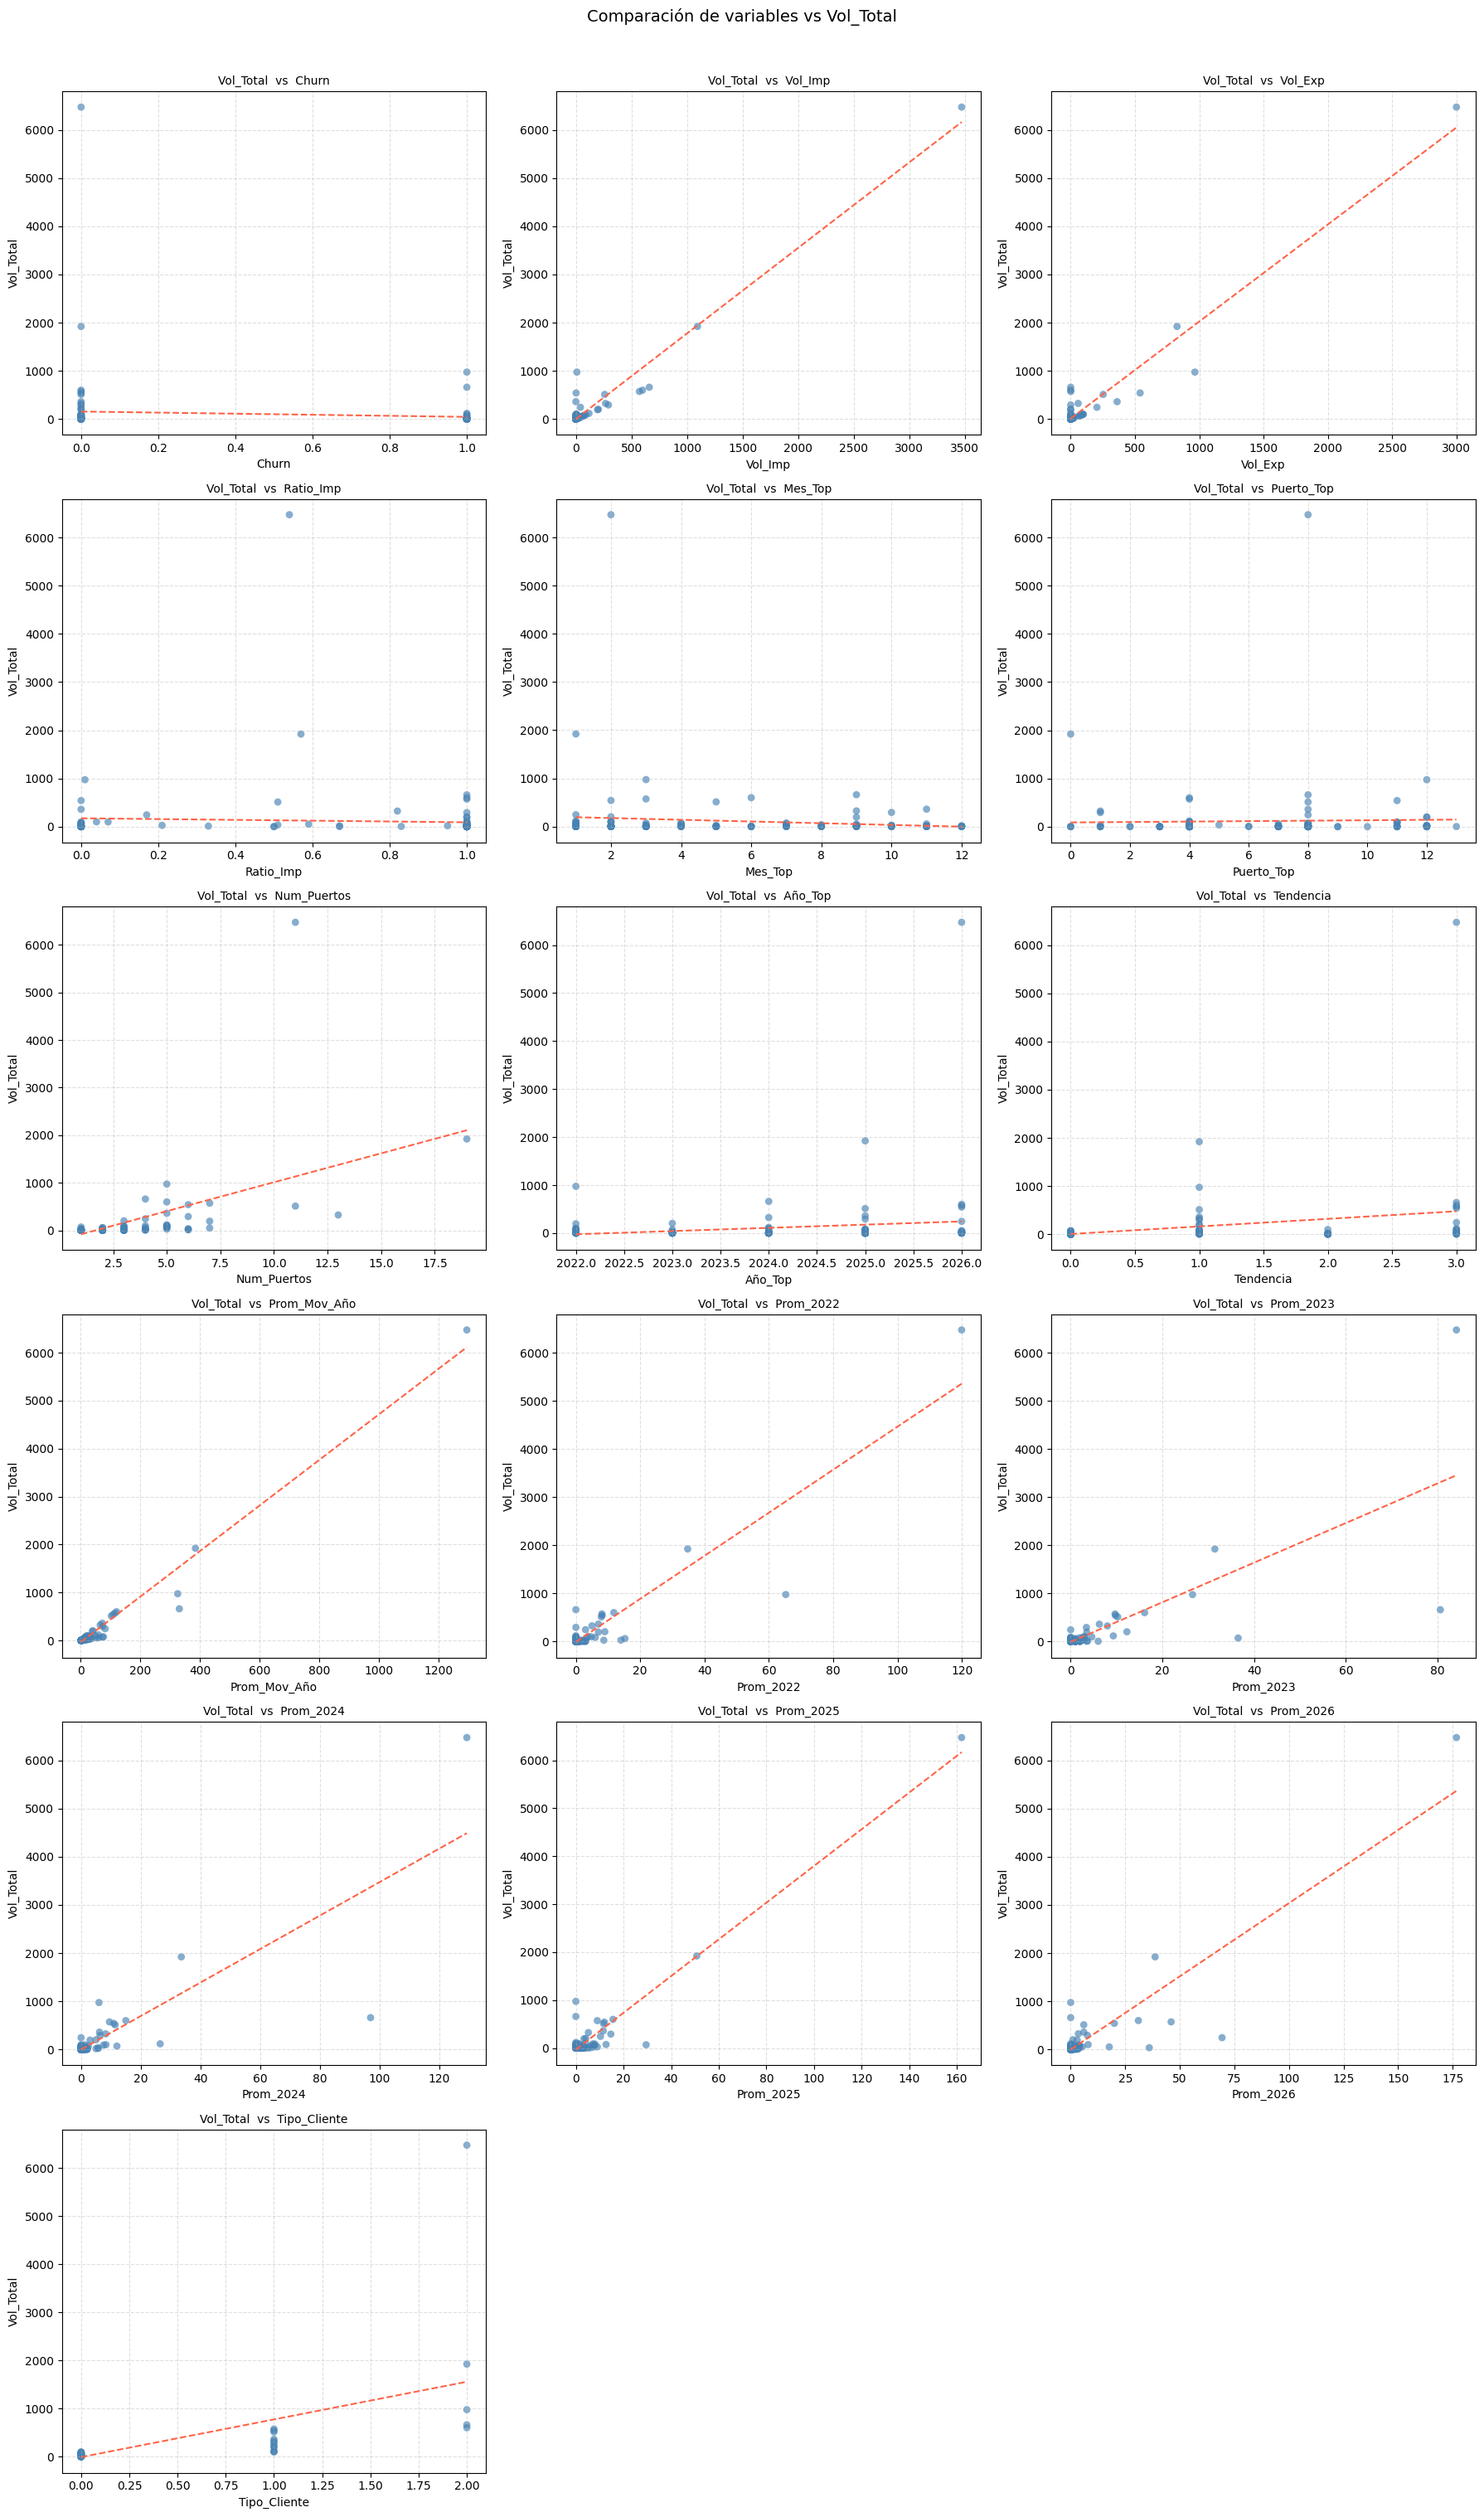

In [9]:
# ============================================================
# Comparación de cada variable vs Vol_Total
# ============================================================
columns_to_avoid = ["Cliente", "Perfil_Movimiento", "Seg_Puertos"]

plot_cols = [
    c for c in df_te.drop(columns=columns_to_avoid).columns
    if c != "Vol_Total"
]

cat_dtypes = {"object", "string", "category"}
cat_cols   = [c for c in plot_cols if df_te[c].dtype.name in cat_dtypes]

ncols = 3
nrows = (len(plot_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]

    if col in cat_cols:
        # Boxplot: Vol_Total por cada categoría
        labels = sorted(df_te[col].dropna().unique())
        groups = [df_te.loc[df_te[col] == v, "Vol_Total"].values for v in labels]
        ax.boxplot(groups, labels=labels, patch_artist=True,
                   boxprops=dict(facecolor="steelblue", color="navy"),
                   medianprops=dict(color="red", linewidth=2))
        ax.tick_params(axis="x", rotation=30)
    else:
        # Scatter + línea de tendencia
        x = df_te[col].fillna(0)
        y = df_te["Vol_Total"]
        ax.scatter(x, y, alpha=0.65, color="steelblue", edgecolors="none", s=40)
        m, b = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, m * x_line + b, color="tomato", linewidth=1.5, linestyle="--")
        ax.set_xlabel(col)

    ax.set_title(f"Vol_Total  vs  {col}", fontsize=10)
    ax.set_ylabel("Vol_Total")
    ax.grid(True, linestyle="--", alpha=0.4)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Comparación de variables vs Vol_Total", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

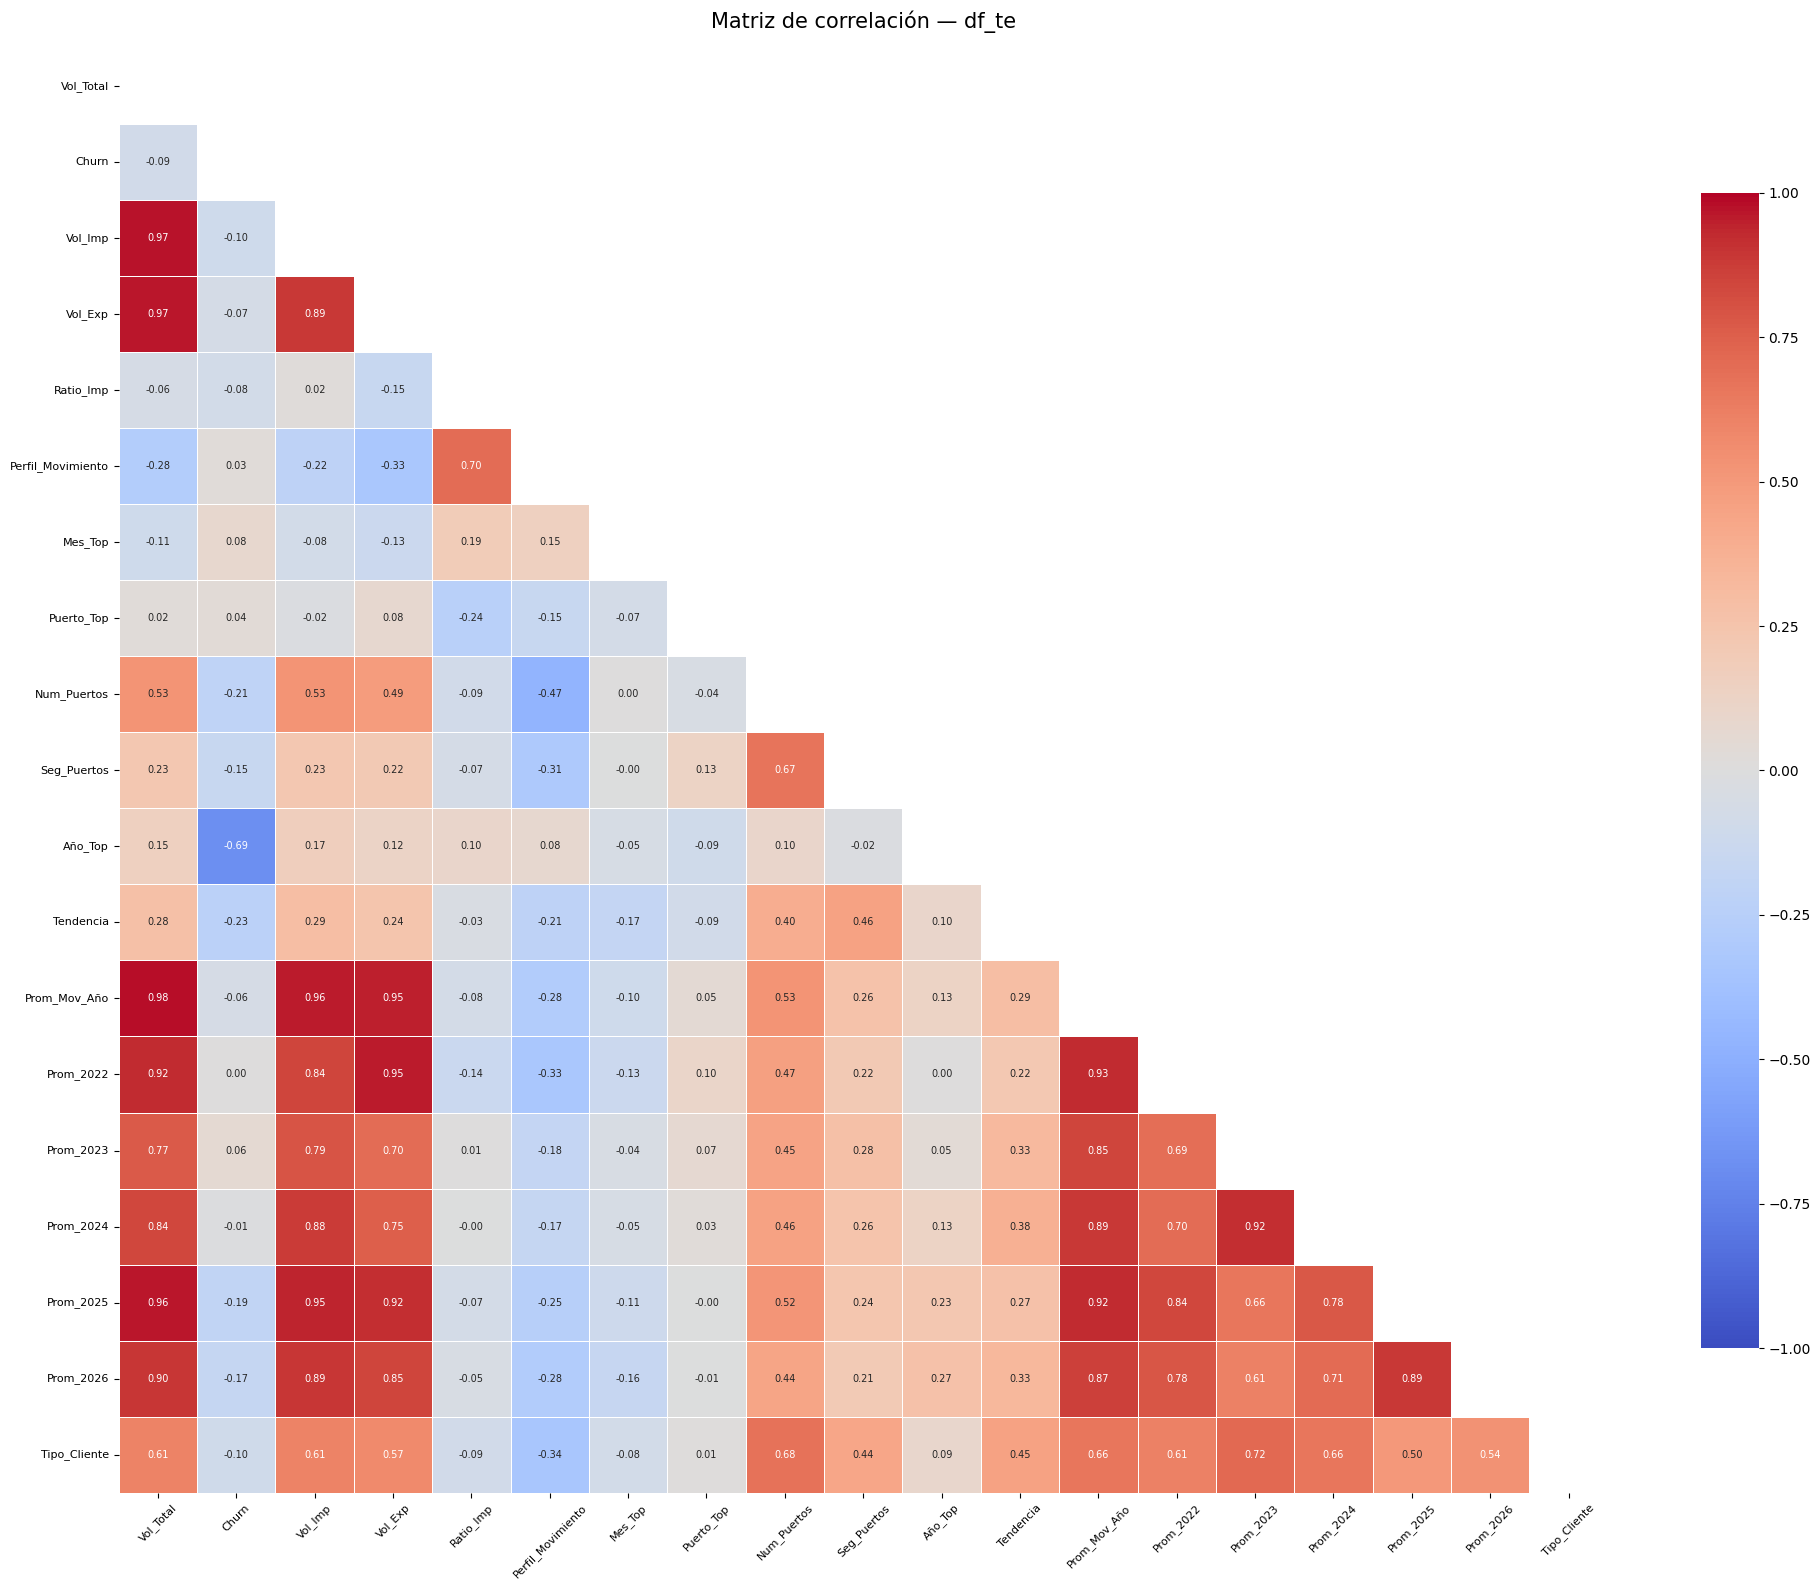


Correlación con Vol_Total (descendente):
Prom_Mov_Año         0.983
Vol_Imp              0.975
Vol_Exp              0.967
Prom_2025            0.962
Prom_2022            0.923
Prom_2026            0.897
Prom_2024            0.842
Prom_2023            0.770
Tipo_Cliente         0.609
Num_Puertos          0.526
Tendencia            0.279
Seg_Puertos          0.229
Año_Top              0.149
Puerto_Top           0.025
Ratio_Imp           -0.062
Churn               -0.090
Mes_Top             -0.109
Perfil_Movimiento   -0.280

Correlación con Churn (descendente):
Mes_Top              0.079
Prom_2023            0.059
Puerto_Top           0.039
Perfil_Movimiento    0.026
Prom_2022            0.001
Prom_2024           -0.011
Prom_Mov_Año        -0.055
Vol_Exp             -0.070
Ratio_Imp           -0.084
Vol_Total           -0.090
Tipo_Cliente        -0.095
Vol_Imp             -0.103
Seg_Puertos         -0.152
Prom_2026           -0.165
Prom_2025           -0.190
Num_Puertos         -0.205
Te

In [10]:
# ============================================================
# Mapa de calor — Matriz de correlación de df_te
# ============================================================
features_te = df_te.drop(columns=["Cliente"])

corr = features_te.corr()

# Triángulo inferior (sin diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title("Matriz de correlación — df_te", fontsize=15, pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

# Correlaciones con Vol_Total y Churn
print("\nCorrelación con Vol_Total (descendente):")
print(corr["Vol_Total"].drop("Vol_Total").sort_values(ascending=False).round(3).to_string())

print("\nCorrelación con Churn (descendente):")
print(corr["Churn"].drop("Churn").sort_values(ascending=False).round(3).to_string())

# Escalado de variables para clustering

In [11]:
# ============================================================
# Escalado de variables para clustering
#   - log1p en variables con sesgo extremo (outliers de volumen)
#   - StandardScaler en variables de rango amplio
#   - Variables ordinales/binarias se mantienen sin escalar
# ============================================================
from sklearn.preprocessing import StandardScaler

df_model = df_te.drop(columns=['Cliente', 'Puerto_Top', 'Perfil_Movimiento']).copy()

# Transformación log1p: reduce sesgo de distribuciones con outliers extremos
log_cols = [
    'Vol_Total', 'Vol_Imp', 'Vol_Exp',
    'Prom_Mov_Año', 'Prom_2022', 'Prom_2023', 'Prom_2024', 'Prom_2025', 'Prom_2026'
]
df_model[log_cols] = np.log1p(df_model[log_cols])

# StandardScaler: media=0, std=1 para variables de rango amplio
scale_cols = log_cols + ['Num_Puertos', 'Año_Top', 'Mes_Top']
scaler = StandardScaler()
df_model[scale_cols] = scaler.fit_transform(df_model[scale_cols])

# Variables sin escalar (ya en rango comparable):
# Ratio_Imp (0-1), Seg_Puertos (0-2), Tendencia (0-3), Tipo_Cliente (0-2), Churn (0-1)

print(f"Shape df_model : {df_model.shape}")
print(f"\nColumnas ({len(df_model.columns)}): {list(df_model.columns)}")
print(f"\nEstadísticas post-escalado:")
df_model.describe().round(2)

Shape df_model : (135, 17)

Columnas (17): ['Vol_Total', 'Churn', 'Vol_Imp', 'Vol_Exp', 'Ratio_Imp', 'Mes_Top', 'Num_Puertos', 'Seg_Puertos', 'Año_Top', 'Tendencia', 'Prom_Mov_Año', 'Prom_2022', 'Prom_2023', 'Prom_2024', 'Prom_2025', 'Prom_2026', 'Tipo_Cliente']

Estadísticas post-escalado:


,Vol_Total,Churn,Vol_Imp,Vol_Exp,Ratio_Imp,Mes_Top,Num_Puertos,Seg_Puertos,Año_Top,Tendencia,Prom_Mov_Año,Prom_2022,Prom_2023,Prom_2024,Prom_2025,Prom_2026,Tipo_Cliente
count,135.00,135.00,135.00,135.00,135.00,135.00,135.00,135.00,135.00,135.00,135.00,135.00,135.00,135.00,135.00,135.00,135.00
mean,-0.00,0.36,0.00,0.00,0.69,0.00,0.00,1.00,0.00,0.70,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.16
std,1.00,0.48,1.00,1.00,0.44,1.00,1.00,0.82,1.00,1.05,1.00,1.00,1.00,1.00,1.00,1.00,0.46
min,-0.97,0.00,-0.99,-0.58,0.00,-1.21,-0.63,0.00,-1.61,0.00,-0.95,-0.54,-0.56,-0.59,-0.87,-0.50,0.00
25%,-0.74,0.00,-0.59,-0.58,0.06,-0.93,-0.63,0.00,-0.85,0.00,-0.90,-0.54,-0.56,-0.59,-0.87,-0.50,0.00
50%,-0.35,0.00,-0.36,-0.58,1.00,-0.37,-0.24,1.00,-0.08,0.00,-0.30,-0.54,-0.56,-0.59,-0.13,-0.50,0.00
75%,0.54,1.00,0.47,0.21,1.00,1.02,0.15,2.00,0.68,1.00,0.65,0.22,0.17,0.14,0.53,0.19,0.00
max,3.55,1.00,3.64,3.94,1.00,1.86,6.41,2.00,1.44,3.00,3.66,4.71,4.11,4.54,4.55,4.66,2.00


# Analisis de outliers

Variables con outliers (|z| > 2.5):
Tendencia       16
Prom_2026        7
Vol_Exp          6
Prom_2023        5
Vol_Imp          5
Prom_2024        4
Prom_Mov_Año     4
Num_Puertos      4
Prom_2022        4
Prom_2025        3
Vol_Total        2


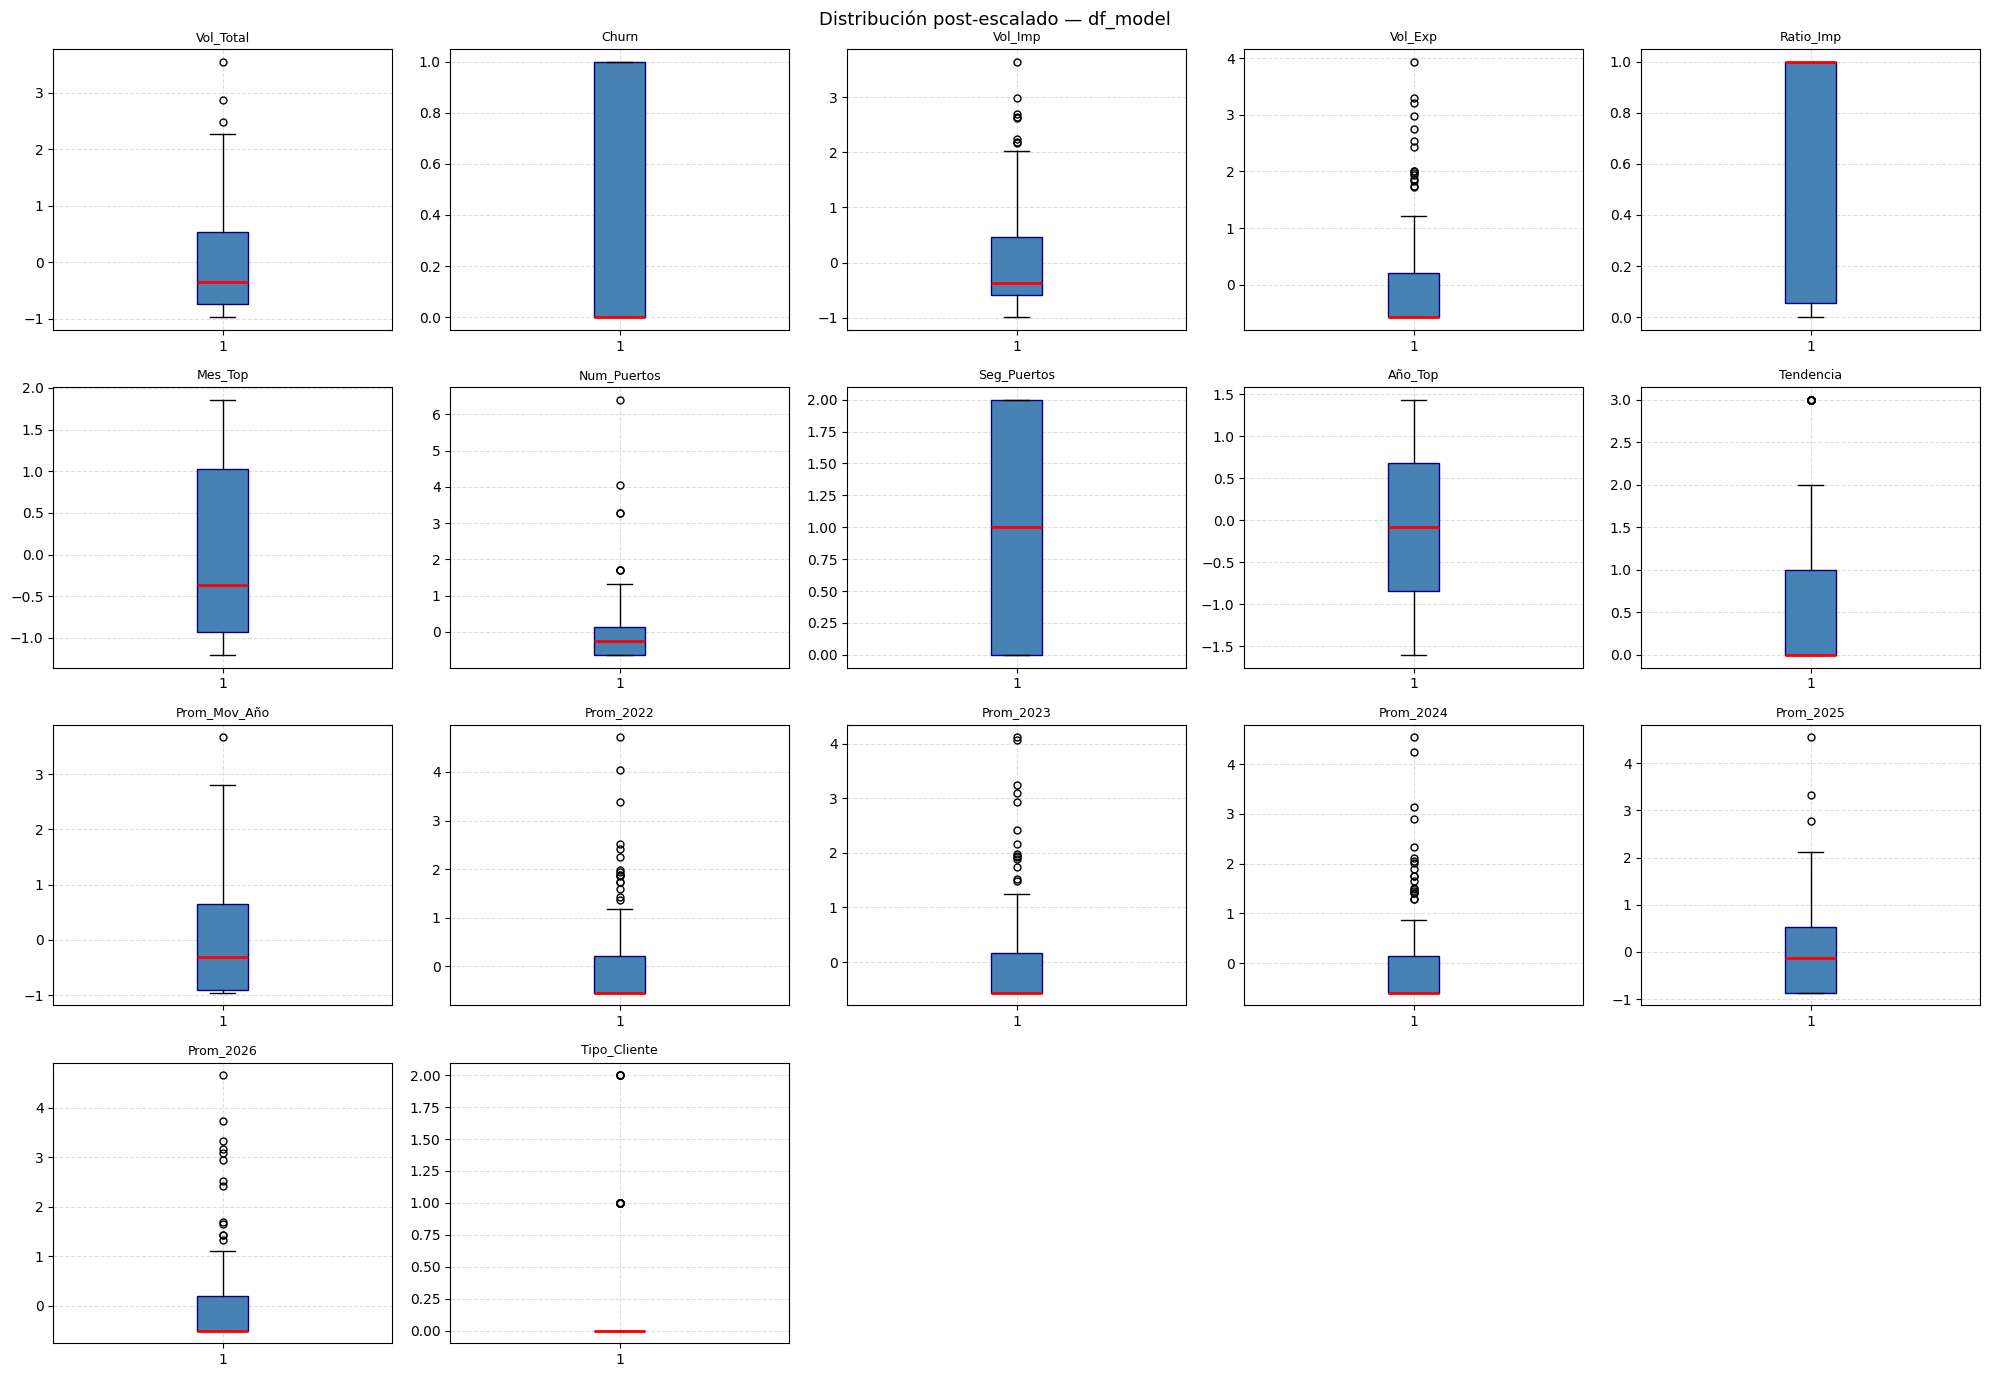


Pares con correlación > 0.80 (posible redundancia):
  Vol_Total            ↔ Prom_Mov_Año        : +0.966
  Prom_2023            ↔ Tipo_Cliente        : +0.803

Clientes con ≥2 variables fuera de rango (|z|>2.5):
  [11 vars]  MABE ECUADOR S.A.
  [10 vars]  DSV-AIR&SEA S.A.
  [4 vars]  CRISTALERIA DEL ECUADOR SA CRIDESA
  [5 vars]  BODEGA DE ALMACENAMIENTO TEMPORAL BODALMET S.A.
  [3 vars]  IMPORTADORA DOUBLE COIN
  [3 vars]  ANGLO ECUATORIANA DE GUAYAQUIL C.A.
  [3 vars]  PICA PLASTICOS INDUSTRIALES C.A.
  [2 vars]  LOGISTICS UNLIMITED S.A. LOGUNSA
  [2 vars]  CC TRUCK ECUADOR CCTRUCKEC S.A.
  [2 vars]  GRUPO COKA CIA. LTDA.
  [2 vars]  SOCIEDAD NACIONAL DE GALAPAGOS C.A.


In [12]:
# ============================================================
# Análisis de outliers y correlación en df_model (data escalada)
# ============================================================
threshold = 2.5  # |z| > 2.5 → outlier en datos estandarizados

# ── 1. Outliers por variable ──────────────────────────────────
outlier_counts = (df_model.abs() > threshold).sum().sort_values(ascending=False)
print("Variables con outliers (|z| > 2.5):")
print(outlier_counts[outlier_counts > 0].to_string())

# ── 2. Boxplots de todas las variables escaladas ──────────────
ncols = 5
nrows = (len(df_model.columns) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, nrows * 3.5))
axes = axes.flatten()
for i, col in enumerate(df_model.columns):
    axes[i].boxplot(df_model[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='tomato', markersize=5))
    axes[i].set_title(col, fontsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.4)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Distribución post-escalado — df_model", fontsize=13)
plt.tight_layout()
plt.show()

# ── 3. Pares con alta correlación (posible redundancia) ───────
corr_m = df_model.corr()
high_corr = [
    (corr_m.columns[i], corr_m.columns[j], round(corr_m.iloc[i, j], 3))
    for i in range(len(corr_m.columns))
    for j in range(i + 1, len(corr_m.columns))
    if abs(corr_m.iloc[i, j]) > 0.80
]
print("\nPares con correlación > 0.80 (posible redundancia):")
if high_corr:
    for a, b, c in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {a:20s} ↔ {b:20s}: {c:+.3f}")
else:
    print("  Ninguno")

# ── 4. Clientes con múltiples variables fuera de rango ────────
n_outliers = (df_model.abs() > threshold).sum(axis=1)
mask_out = n_outliers >= 2
print(f"\nClientes con ≥2 variables fuera de rango (|z|>{threshold}):")
for idx in df_te.index[mask_out]:
    print(f"  [{n_outliers[idx]} vars]  {df_te.loc[idx, 'Cliente']}")

# Visualización de los datos

## PCA

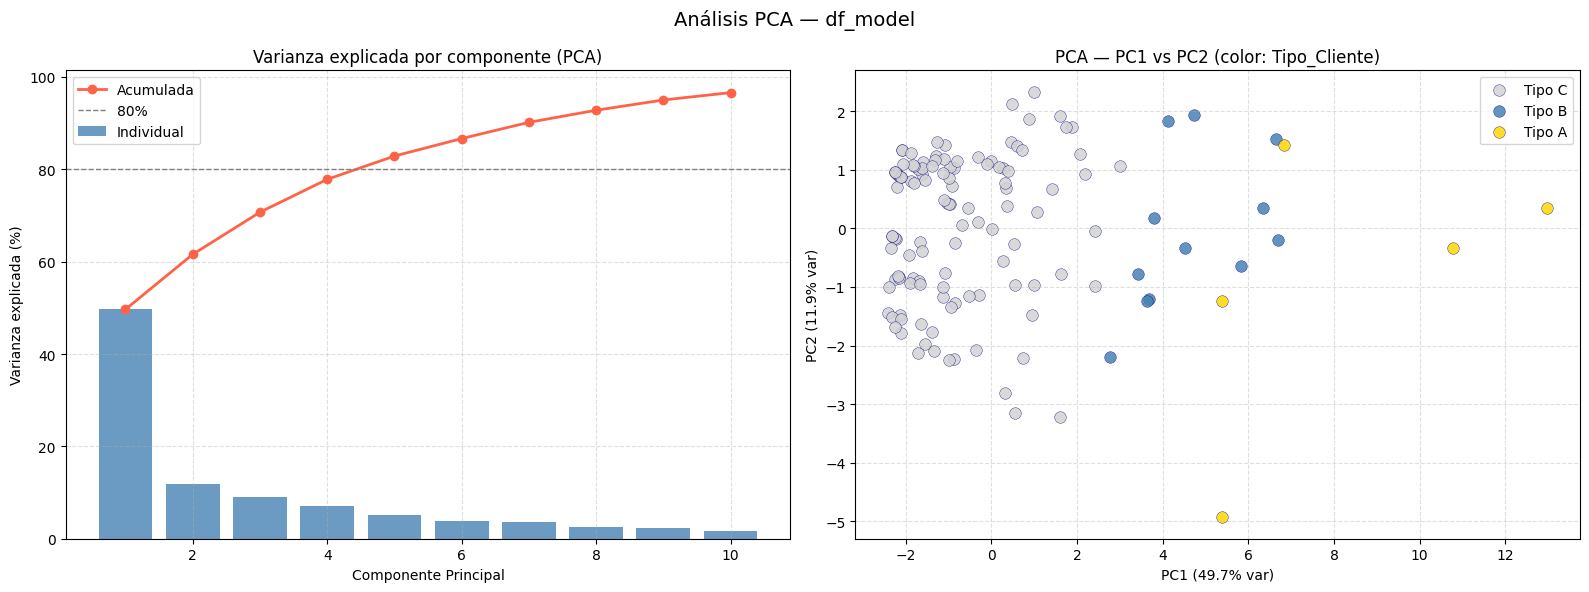

Componentes necesarios para explicar ≥80% de varianza: 5
  PC1:  49.7%  acumulado:  49.7%
  PC2:  11.9%  acumulado:  61.6%
  PC3:   9.1%  acumulado:  70.7%
  PC4:   7.1%  acumulado:  77.8%
  PC5:   5.0%  acumulado:  82.9%
  PC6:   3.8%  acumulado:  86.7%
  PC7:   3.5%  acumulado:  90.2%
  PC8:   2.6%  acumulado:  92.8%
  PC9:   2.2%  acumulado:  95.0%
  PC10:   1.6%  acumulado:  96.6%

Contribución de variables (loadings) a PC1 y PC2:
                PC1    PC2
Vol_Total     0.359  0.034
Prom_Mov_Año  0.336  0.049
Num_Puertos   0.319  0.030
Prom_2024     0.301  0.041
Prom_2023     0.290  0.217
Vol_Imp       0.284  0.117
Prom_2026     0.280  0.259
Prom_2025     0.263  0.356
Prom_2022     0.253  0.367
Vol_Exp       0.243  0.191
Tendencia     0.239  0.064
Seg_Puertos   0.206  0.050
Tipo_Cliente  0.144  0.044
Año_Top       0.066  0.689
Mes_Top       0.051  0.033
Churn         0.047  0.272
Ratio_Imp     0.020  0.097


In [13]:
# ============================================================
# PCA — Reducción de dimensionalidad y varianza explicada
# ============================================================
from sklearn.decomposition import PCA

# Varianza explicada por componente
pca_full = PCA(n_components=min(10, df_model.shape[1]))
pca_full.fit(df_model)
exp_var  = pca_full.explained_variance_ratio_
cum_var  = np.cumsum(exp_var)

# Proyección 2D
pca2     = PCA(n_components=2, random_state=42)
coords   = pca2.fit_transform(df_model)
ev2      = pca2.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Scree plot ────────────────────────────────────────────────
axes[0].bar(range(1, len(exp_var) + 1), exp_var * 100, color='steelblue', alpha=0.8, label='Individual')
axes[0].plot(range(1, len(exp_var) + 1), cum_var * 100, 'o-', color='tomato', linewidth=2, label='Acumulada')
axes[0].axhline(80, color='gray', linestyle='--', linewidth=1, label='80%')
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].set_title("Varianza explicada por componente (PCA)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# ── Scatter PC1 vs PC2 coloreado por Tipo_Cliente ─────────────
tipo_map    = {0: 'C', 1: 'B', 2: 'A'}
colors_tipo = {'A': 'gold', 'B': 'steelblue', 'C': 'lightgray'}
for t_val in sorted(df_te['Tipo_Cliente'].unique()):
    t_lbl = tipo_map[t_val]
    idx   = df_te.index[df_te['Tipo_Cliente'] == t_val]
    axes[1].scatter(coords[idx, 0], coords[idx, 1],
                    label=f'Tipo {t_lbl}', alpha=0.85, s=70,
                    color=colors_tipo[t_lbl], edgecolors='navy', linewidths=0.3)

axes[1].set_xlabel(f"PC1 ({ev2[0]*100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({ev2[1]*100:.1f}% var)")
axes[1].set_title("PCA — PC1 vs PC2 (color: Tipo_Cliente)")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Análisis PCA — df_model", fontsize=14)
plt.tight_layout()
plt.show()

# Resumen de varianza
n80 = next(i + 1 for i, v in enumerate(cum_var) if v >= 0.80)
print(f"Componentes necesarios para explicar ≥80% de varianza: {n80}")
for i, (ev, cv) in enumerate(zip(exp_var, cum_var), 1):
    print(f"  PC{i}: {ev*100:5.1f}%  acumulado: {cv*100:5.1f}%")

# Contribución de variables a PC1 y PC2
loadings = pd.DataFrame(pca2.components_.T,
                         index=df_model.columns,
                         columns=['PC1', 'PC2'])
print("\nContribución de variables (loadings) a PC1 y PC2:")
print(loadings.abs().sort_values('PC1', ascending=False).round(3).to_string())

## TSNE

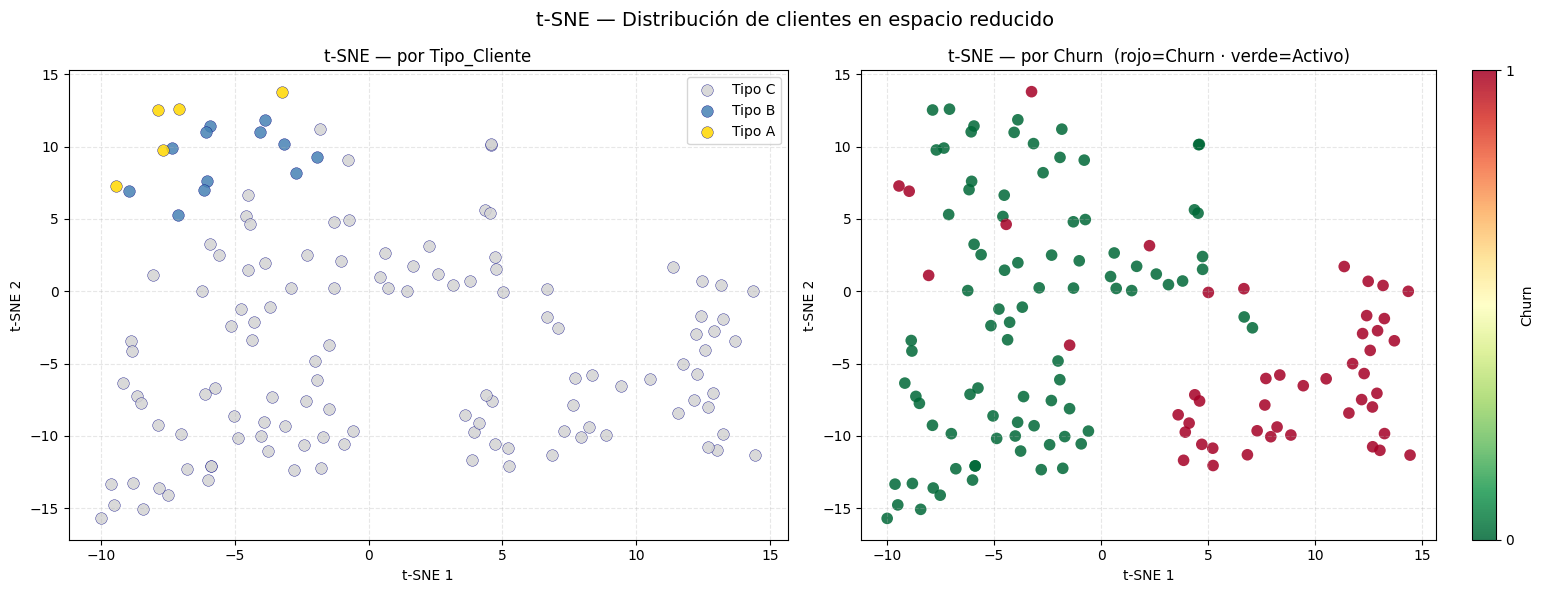

Interpretación t-SNE:
  - Grupos bien separados → clustering factible
  - Grupos mezclados     → variables no discriminan suficientemente
  - Outliers aislados    → considerar KMedoids o excluirlos del entrenamiento


In [14]:
# ============================================================
# t-SNE — Visualización no lineal de la distribución de clientes
# ============================================================
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=20, random_state=42, max_iter=1000, learning_rate='auto')
coords_tsne = tsne.fit_transform(df_model)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Por Tipo_Cliente ──────────────────────────────────────────
tipo_map    = {0: 'C', 1: 'B', 2: 'A'}
colors_tipo = {'A': 'gold', 'B': 'steelblue', 'C': 'lightgray'}
for t_val in sorted(df_te['Tipo_Cliente'].unique()):
    t_lbl = tipo_map[t_val]
    idx   = df_te.index[df_te['Tipo_Cliente'] == t_val]
    axes[0].scatter(coords_tsne[idx, 0], coords_tsne[idx, 1],
                    label=f'Tipo {t_lbl}', alpha=0.85, s=70,
                    color=colors_tipo[t_lbl], edgecolors='navy', linewidths=0.3)
axes[0].set_title("t-SNE — por Tipo_Cliente")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.3)
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

# ── Por Churn ─────────────────────────────────────────────────
churn_labels = df_te['Churn'].values
sc = axes[1].scatter(coords_tsne[:, 0], coords_tsne[:, 1],
                     c=churn_labels, cmap='RdYlGn_r',
                     alpha=0.85, s=70, edgecolors='none', vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[1], ticks=[0, 1], label='Churn')
axes[1].set_title("t-SNE — por Churn  (rojo=Churn · verde=Activo)")
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.suptitle("t-SNE — Distribución de clientes en espacio reducido", fontsize=14)
plt.tight_layout()
plt.show()

print("Interpretación t-SNE:")
print("  - Grupos bien separados → clustering factible")
print("  - Grupos mezclados     → variables no discriminan suficientemente")
print("  - Outliers aislados    → considerar KMedoids o excluirlos del entrenamiento")

# Selección de variables para clustering

In [15]:
# ============================================================
# Selección final de variables para clustering
#   Excluidas por baja contribución en PCA:
#     - Ratio_Imp  (redunda con Vol_Imp/Vol_Exp, baja discriminación)
#     - Mes_Top    (baja varianza explicada, no relevante para segmentación)
#     - Año_Top    (temporal, no describe comportamiento del cliente)
#   Excluida por decisión de modelo:
#     - Churn      (capturada por regla en Nivel 1 del modelo híbrido;
#                   dentro de sub-clusters tiene varianza cero o distorsiona
#                   las distancias en clustering puro)
# ============================================================
X_cluster = df_model.drop(columns=['Ratio_Imp', 'Mes_Top', 'Año_Top', 'Churn'])

print(f"Variables del modelo final ({X_cluster.shape[1]}):")
for col in X_cluster.columns:
    print(f"  {col}")

Variables del modelo final (13):
  Vol_Total
  Vol_Imp
  Vol_Exp
  Num_Puertos
  Seg_Puertos
  Tendencia
  Prom_Mov_Año
  Prom_2022
  Prom_2023
  Prom_2024
  Prom_2025
  Prom_2026
  Tipo_Cliente


# Comparación de Silhouette score: con y sin variable "churn"

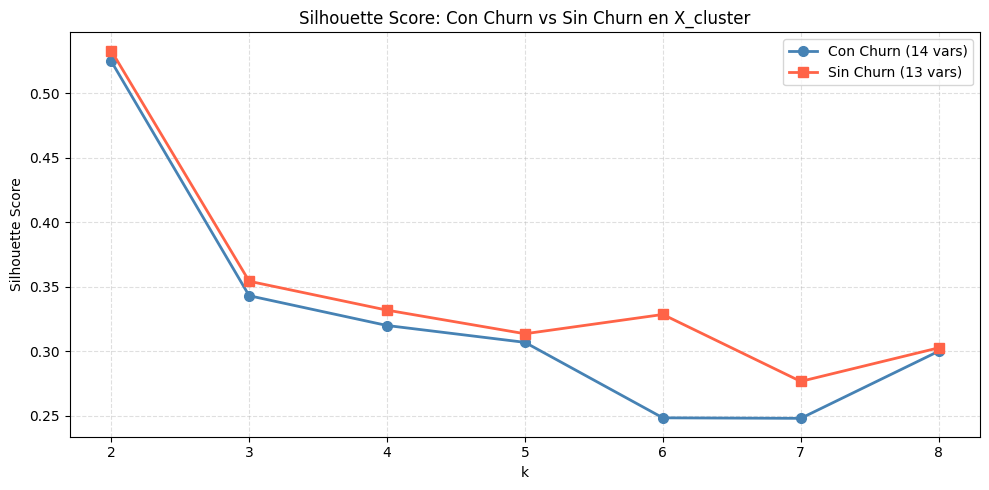

  k     Con Churn     Sin Churn    Diferencia
────────────────────────────────────────────
  2        0.5248        0.5330       +0.0082 ◄
  3        0.3431        0.3543       +0.0112 ◄
  4        0.3200        0.3319       +0.0119 ◄
  5        0.3069        0.3136       +0.0067 ◄
  6        0.2484        0.3286       +0.0801 ◄
  7        0.2480        0.2767       +0.0286 ◄
  8        0.3000        0.3027       +0.0026 ◄

Mejor k  Con Churn : k=2  (0.5248)
Mejor k  Sin Churn : k=2  (0.5330)


In [16]:
# ============================================================
# Comparación Silhouette: X_cluster CON vs SIN Churn
#   Evalúa KMeans k=2..8 en ambas versiones del feature set
# ============================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_con_churn  = df_model.drop(columns=['Ratio_Imp', 'Mes_Top', 'Año_Top'])           # 14 vars
X_sin_churn  = df_model.drop(columns=['Ratio_Imp', 'Mes_Top', 'Año_Top', 'Churn'])  # 13 vars

K_range = range(2, 9)
res_con, res_sin = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    res_con.append(silhouette_score(X_con_churn,  km.fit_predict(X_con_churn)))
    res_sin.append(silhouette_score(X_sin_churn,  km.fit_predict(X_sin_churn)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, res_con, 'o-', color='steelblue',  linewidth=2, markersize=7, label='Con Churn (14 vars)')
ax.plot(K_range, res_sin, 's-', color='tomato',     linewidth=2, markersize=7, label='Sin Churn (13 vars)')
ax.set_xlabel("k")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score: Con Churn vs Sin Churn en X_cluster")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

print(f"{'k':>3}  {'Con Churn':>12}  {'Sin Churn':>12}  {'Diferencia':>12}")
print("─" * 44)
for k, c, s in zip(K_range, res_con, res_sin):
    mark = ' ◄' if s > c else ''
    print(f"{k:>3}  {c:>12.4f}  {s:>12.4f}  {s-c:>+12.4f}{mark}")

best_con = list(K_range)[res_con.index(max(res_con))]
best_sin = list(K_range)[res_sin.index(max(res_sin))]
print(f"\nMejor k  Con Churn : k={best_con}  ({max(res_con):.4f})")
print(f"Mejor k  Sin Churn : k={best_sin}  ({max(res_sin):.4f})")

## Modelo Final — Segmentación Híbrida

### ¿Por qué un enfoque híbrido?

El clustering puro optimiza distancias en el espacio de variables, pero en este dataset presenta dos limitaciones:

1. **Variables con significado estratégico ya conocido**: `Tipo_Cliente` y `Churn` no son patrones a *descubrir* — son clasificaciones de negocio explícitas que el algoritmo trata igual que cualquier otra variable.
2. **Dataset pequeño y desbalanceado**: 135 clientes, solo 17 tipo A/B (12.6%). El algoritmo absorbe esos outliers de alto valor dentro de clusters dominados por los 118 clientes tipo C.

---

### Arquitectura del modelo

La segmentación combina **reglas de negocio** (conocimiento experto) con **aprendizaje no supervisado** (ML), evitando que el algoritmo redescubra lo que ya se sabe.

| Nivel | Mecanismo | Resultado |
|-------|-----------|----------|
| **Nivel 1** — Reglas | `Tipo_Cliente × Churn` | Crítico Activo · Recuperación AB · C Inactivo · C Activo |
| **Nivel 2** — ML | K-Medoids k=2 sobre "C Activo" | C Activo Frecuente · C Activo Ocasional |



```
         df_clientes (135 clientes)
                    |
       +------------+------------+
       |        NIVEL 1          |
       |   Reglas de negocio     |
       |  (Tipo_Cliente x Churn) |
       +------------+------------+
                    |
   +----------------+------------------+
   |                |                  |
A/B+Churn=0   A/B+Churn=1        C+Churn=1
Critico Activo Recuperacion AB   C Inactivo

               C+Churn=0 (~76 clientes)
                    |
       +------------+------------+
       |        NIVEL 2          |
       |   K-Medoids  k=2        |
       |   13 vars (sin Churn)   |
       +------------+------------+
                    |
   +----------------+------------------+
C Activo Frecuente         C Activo Ocasional
(mayor vol/frecuencia)     (menor actividad)
```

### Variables del clustering — Nivel 2 (13 vars)

| Grupo | Variables |
|---|---|
| Magnitud operativa | `Vol_Total`, `Vol_Imp`, `Vol_Exp` |
| Historial / tendencia | `Prom_Mov_Año`, `Prom_2022` ... `Prom_2026` |
| Diversidad geográfica | `Num_Puertos`, `Seg_Puertos` |
| Comportamiento | `Tendencia`, `Tipo_Cliente` |

> **Excluidas**: `Ratio_Imp` (redundante con Vol_Imp/Exp), `Mes_Top` y `Año_Top` (temporales), `Churn` (capturada por regla en Nivel 1; dentro del sub-grupo C Activo tiene varianza cero y distorsionaba las distancias).


### Método de clustering: K-Medoids

**¿Qué es?** K-Medoids elige puntos **reales** del dataset como representantes de cada grupo (*medioides*), en lugar de promedios virtuales como en K-Means.

**¿Por qué K-Medoids y no K-Means?**

| Criterio | K-Means | K-Medoids |
|----------|---------|-----------|
| Representante del grupo | Centroide virtual (promedio) | Cliente real del dataset |
| Sensibilidad a outliers | Alta — un cliente extremo desplaza el centroide | Baja — el medoide es el punto más central |
| Interpretabilidad | Difícil: el centroide no existe en los datos | Alta: se puede identificar al cliente "tipo" |
| Dataset pequeño (n≈90) | Puede inestabilizarse con outliers | Más estable y reproducible |

> En Transestiba existe un cliente con > 6 000 movimientos que distorsiona los centroides de K-Means. K-Medoids lo trata como outlier y no le permite dominar el cluster.

**¿Por qué k=2 en el sub-grupo C Activo?**
- El análisis de **Silhouette Score** mostró que k=2 maximiza la separación interna dentro de C Activo.
- La partición tiene interpretación de negocio directa: clientes con operación **frecuente** vs **ocasional**.

---

### Variables de clustering: X_cluster (13 variables, sin Churn)

`X_cluster = df_model.drop(columns=['Ratio_Imp', 'Mes_Top', 'Año_Top', 'Churn'])`

**¿Por qué se excluye `Churn`?**

1. **Es constante dentro de C Activo**: todos los clientes de este sub-grupo tienen `Churn = 0`. Una variable sin varianza no aporta información; solo agrega ruido a la métrica de distancia.
2. **Ya fue capturado en el Nivel 1**: la regla de negocio separa Activos (Churn=0) de Inactivos (Churn=1) antes de llegar al clustering. Incluirlo sería redundante.
3. **Evidencia empírica**: la comparación de Silhouette con y sin Churn demostró que **eliminar Churn mejora la separación en todos los valores de k (2–8)**.

**¿Por qué se excluyen `Ratio_Imp`, `Mes_Top`, `Año_Top`?**
- `Ratio_Imp`: ratio derivado de otras variables ya presentes → multicolinealidad.
- `Mes_Top` y `Año_Top`: variables nominales de tiempo discreto que distorsionan las distancias euclidianas.



Feature set: 13 variables (sin Churn)
  ['Vol_Total', 'Vol_Imp', 'Vol_Exp', 'Num_Puertos', 'Seg_Puertos', 'Tendencia', 'Prom_Mov_Año', 'Prom_2022', 'Prom_2023', 'Prom_2024', 'Prom_2025', 'Prom_2026', 'Tipo_Cliente']



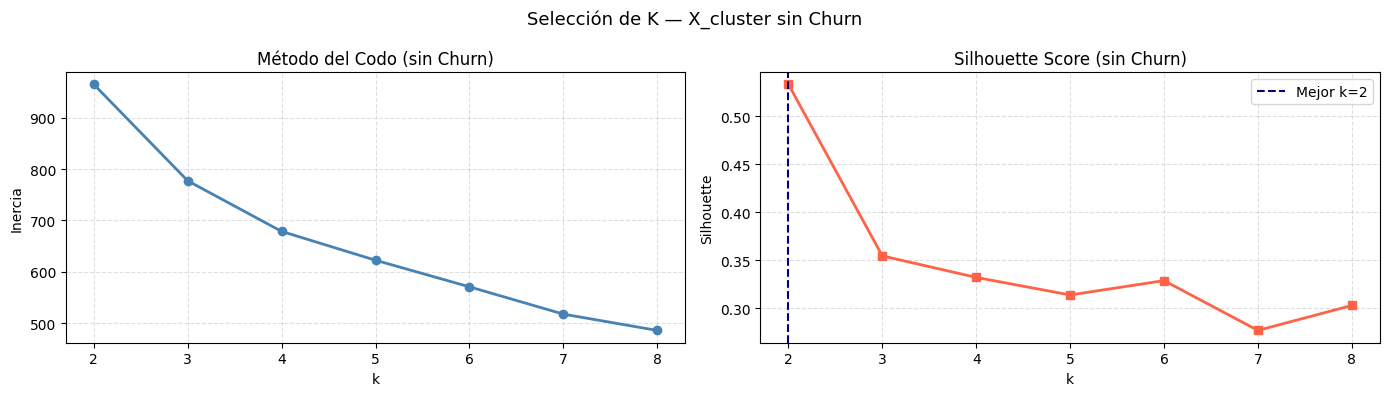

Mejor k por Silhouette: 2  (0.5330)

Nivel 1 — distribución base:
Seg_Final
_C Activo          73
C Inactivo         45
Critico Activo     14
Recuperacion AB     3 

Sub-clustering 'C Activo'  Silhouette k=2: 0.3350

Distribución final — 5 segmentos:
  Critico Activo            14 clientes   78.7% volumen
  Recuperacion AB            3 clientes   11.1% volumen
  C Activo Frecuente        30 clientes    6.6% volumen
  C Activo Ocasional        43 clientes    0.9% volumen
  C Inactivo                45 clientes    2.7% volumen

────────────────────────────────────────────────────────────────────────────────
PERFIL ESTRATÉGICO
────────────────────────────────────────────────────────────────────────────────

  [CRITICO ACTIVO]  —  14 clientes
  Acción          : Asignar account manager. SLA prioritario. Revisión trimestral.
  Vol median/mean :     343 /     889
  Prom 2025/2026  :   22.5  /    29.8
  Tendencia moda  : Decreciente
  Tipo A/B/C      : A=3  B=11  C=0
    A   6,473  Creciente 

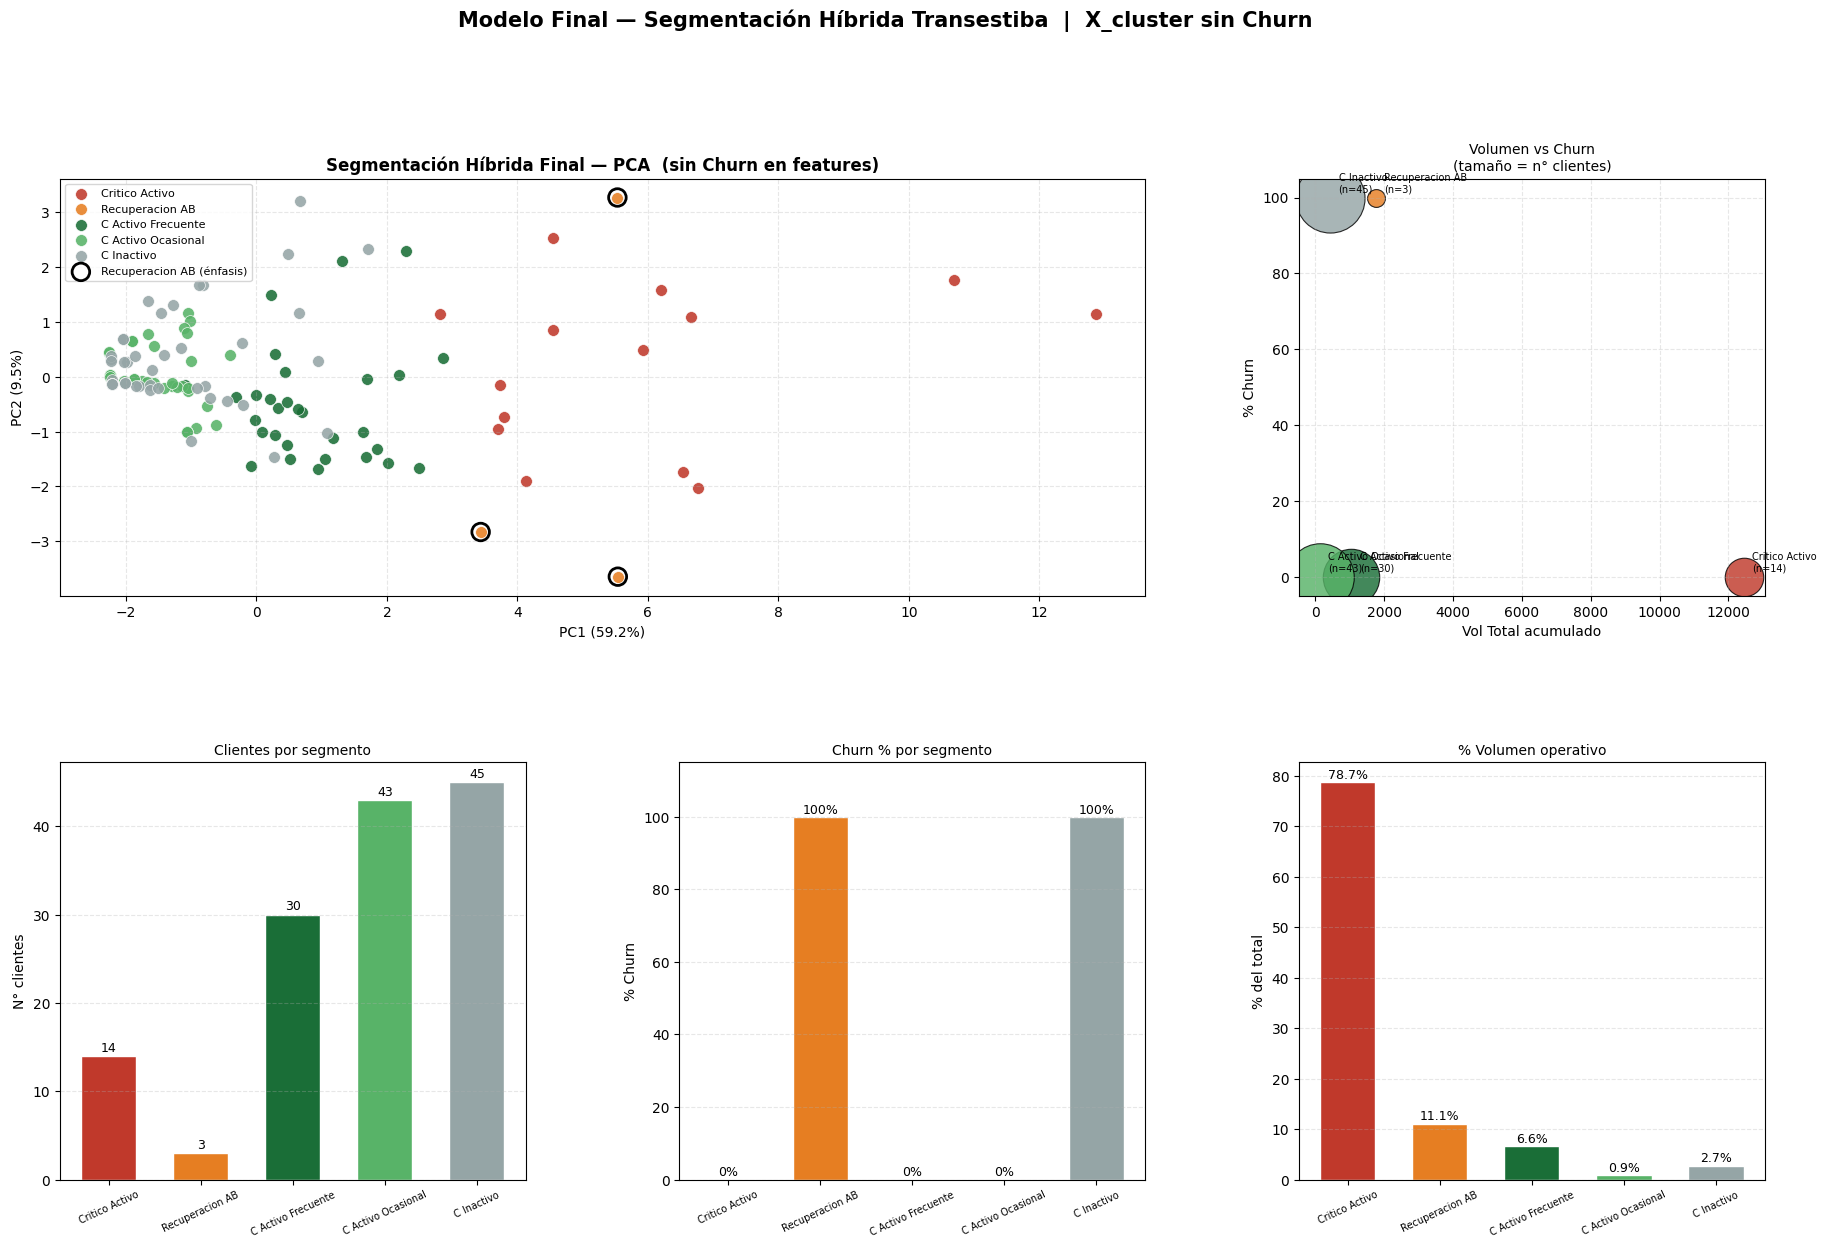

Guardado: modelo_final_sin_churn.png

PERFIL DE CLUSTERS — SEGMENTACIÓN HÍBRIDA FINAL
Segmento          Critico Activo  Recuperacion AB  C Activo Frecuente  C Activo Ocasional  C Inactivo
N Clientes                  14.0              3.0                30.0                43.0        45.0
Vol Total (med)            343.0            661.0                26.0                 2.0         2.0
Vol Total (mean)           889.0            585.0                35.0                 3.0        10.0
Vol % total                 78.7             11.1                 6.6                 0.9         2.7
Prom Mov/Año               181.5            238.2                18.0                 2.6         8.2
N Puertos (med)              7.6              4.7                 3.3                 1.3         1.7
Prom 2024                   17.7             43.2                 1.6                 0.2         0.5
Prom 2025                   22.5              0.0                 4.4                 1.5         

In [17]:
# ============================================================
# MODELO FINAL — Segmentación Híbrida sin Churn en X_cluster
#
#   X_cluster : 13 variables (sin Ratio_Imp, Mes_Top, Año_Top, Churn)
#   Nivel 1   : Reglas Tipo_Cliente × Churn  → 4 segmentos fijos
#   Nivel 2   : K-Medoids k=2 sobre "C Activo" → 2 sub-segmentos
#   Resultado : 5 segmentos estratégicos
# ============================================================
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans

def kmedoids(X, k, random_state=42, max_iter=300):
    """PAM simplificado: medoids reales del dataset, sin dependencias C++."""
    rng = np.random.default_rng(random_state)
    X   = np.array(X)
    n   = len(X)
    D   = cdist(X, X, metric='euclidean')
    medoid_idx = rng.choice(n, k, replace=False)
    for _ in range(max_iter):
        labels = np.argmin(D[:, medoid_idx], axis=1)
        new_medoids = medoid_idx.copy()
        for c in range(k):
            idx_c = np.where(labels == c)[0]
            if len(idx_c) == 0:
                continue
            costs = D[np.ix_(idx_c, idx_c)].sum(axis=1)
            new_medoids[c] = idx_c[np.argmin(costs)]
        if np.array_equal(np.sort(new_medoids), np.sort(medoid_idx)):
            break
        medoid_idx = new_medoids
    labels = np.argmin(D[:, medoid_idx], axis=1)
    return labels, medoid_idx

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print(f"Feature set: {X_cluster.shape[1]} variables (sin Churn)")
print(f"  {list(X_cluster.columns)}\n")

# ── Elbow + Silhouette (referencia rápida) ────────────────────
K_range   = range(2, 9)
inertias, sil_scores = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, lbl))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(K_range, inertias,   'o-', color='steelblue', linewidth=2)
axes[0].set_title("Método del Codo (sin Churn)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia"); axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(K_range, sil_scores, 's-', color='tomato',    linewidth=2)
best_k = list(K_range)[sil_scores.index(max(sil_scores))]
axes[1].axvline(best_k, color='navy', linestyle='--', linewidth=1.5, label=f'Mejor k={best_k}')
axes[1].set_title("Silhouette Score (sin Churn)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette"); axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.4)
plt.suptitle("Selección de K — X_cluster sin Churn", fontsize=13)
plt.tight_layout(); plt.show()

print(f"Mejor k por Silhouette: {best_k}  ({max(sil_scores):.4f})\n")

# ── Nivel 1: segmentos fijos por regla ───────────────────────
def seg_nivel1(row):
    if row['Tipo_Cliente'] in ('A','B') and row['Churn'] == 0:
        return 'Critico Activo'
    elif row['Tipo_Cliente'] in ('A','B') and row['Churn'] == 1:
        return 'Recuperacion AB'
    elif row['Churn'] == 1:
        return 'C Inactivo'
    else:
        return '_C Activo'   # prefijo _ para sub-segmentar

df_clientes['Seg_Final'] = df_clientes.apply(seg_nivel1, axis=1)

cnt = df_clientes['Seg_Final'].value_counts()
print("Nivel 1 — distribución base:")
print(cnt.to_string(), "\n")

# ── Nivel 2: K-Medoids k=2 sobre "C Activo" ──────────────────
idx_ca   = df_clientes.index[df_clientes['Seg_Final'] == '_C Activo'].tolist()
X_ca     = X_cluster.loc[idx_ca].values

labels_ca, medoids_ca = kmedoids(X_ca, k=2, random_state=42)
sil_ca   = silhouette_score(X_ca, labels_ca)
print(f"Sub-clustering 'C Activo'  Silhouette k=2: {sil_ca:.4f}")

# Etiqueta: sub-cluster con mayor Vol_Total mediano = Frecuente
vol_med = {s: df_clientes.loc[[idx_ca[i] for i,l in enumerate(labels_ca) if l==s],
                               'Vol_Total'].median()
           for s in [0,1]}
alta = max(vol_med, key=vol_med.get)
sub_lbl = {alta: 'C Activo Frecuente', 1-alta: 'C Activo Ocasional'}

for i, idx in enumerate(idx_ca):
    df_clientes.at[idx, 'Seg_Final'] = sub_lbl[labels_ca[i]]

# ── Resumen final ─────────────────────────────────────────────
SEG_ORDEN = ['Critico Activo','Recuperacion AB',
             'C Activo Frecuente','C Activo Ocasional','C Inactivo']

print("\nDistribución final — 5 segmentos:")
dist = df_clientes['Seg_Final'].value_counts().reindex(SEG_ORDEN)
for seg, n in dist.items():
    vol_pct = df_clientes[df_clientes['Seg_Final']==seg]['Vol_Total'].sum() \
              / df_clientes['Vol_Total'].sum() * 100
    print(f"  {seg:<24} {n:>3} clientes  {vol_pct:>5.1f}% volumen")

# ── Perfil por segmento ───────────────────────────────────────
print(f"\n{'─'*80}")
print("PERFIL ESTRATÉGICO")
print(f"{'─'*80}")

acciones = {
    'Critico Activo':     'Asignar account manager. SLA prioritario. Revisión trimestral.',
    'Recuperacion AB':    'Contacto directo. Oferta de reactivación. Diagnóstico de salida.',
    'C Activo Frecuente': 'Programa de fidelización. Potencial upgrade a Tipo B.',
    'C Activo Ocasional': 'Comunicación periódica. Ofertas estacionales.',
    'C Inactivo':         'Campaña de re-engagement. Si no responde, baja de cartera activa.',
}

for seg in SEG_ORDEN:
    sub = df_clientes[df_clientes['Seg_Final'] == seg]
    if len(sub) == 0:
        continue
    tipo_d = sub['Tipo_Cliente'].value_counts().to_dict()
    tend_m = sub['Tendencia'].mode()[0] if 'Tendencia' in sub.columns else '-'
    print(f"\n  [{seg.upper()}]  —  {len(sub)} clientes")
    print(f"  Acción          : {acciones[seg]}")
    print(f"  Vol median/mean : {sub['Vol_Total'].median():>7,.0f} / {sub['Vol_Total'].mean():>7,.0f}")
    print(f"  Prom 2025/2026  : {sub['Prom_2025'].mean():>6.1f}  /  {sub['Prom_2026'].mean():>6.1f}")
    print(f"  Tendencia moda  : {tend_m}")
    print(f"  Tipo A/B/C      : A={tipo_d.get('A',0)}  B={tipo_d.get('B',0)}  C={tipo_d.get('C',0)}")
    if len(sub) <= 20:
        for _, r in sub[['Cliente','Vol_Total','Tendencia','Tipo_Cliente']].iterrows():
            print(f"    {r['Tipo_Cliente']}  {r['Vol_Total']:>6,}  {r['Tendencia']:12}  {r['Cliente']}")

# ── Dashboard visual ──────────────────────────────────────────
SEG_COLORS = {
    'Critico Activo':     '#c0392b',
    'Recuperacion AB':    '#e67e22',
    'C Activo Frecuente': '#1a6e37',
    'C Activo Ocasional': '#58b368',
    'C Inactivo':         '#95a5a6',
}

pca_f    = PCA(n_components=2, random_state=42)
coords_f = pca_f.fit_transform(X_cluster)
ev_f     = pca_f.explained_variance_ratio_

fig = plt.figure(figsize=(22, 13))
gs  = fig.add_gridspec(2, 3, hspace=0.40, wspace=0.33)
ax_pca   = fig.add_subplot(gs[0, :2])
ax_bub   = fig.add_subplot(gs[0, 2])
ax_n     = fig.add_subplot(gs[1, 0])
ax_churn = fig.add_subplot(gs[1, 1])
ax_vol   = fig.add_subplot(gs[1, 2])

# PCA scatter
for seg in SEG_ORDEN:
    idx = df_clientes.index[df_clientes['Seg_Final'] == seg]
    if not len(idx): continue
    ax_pca.scatter(coords_f[idx, 0], coords_f[idx, 1],
                   color=SEG_COLORS[seg], label=seg,
                   alpha=0.88, s=72, edgecolors='white', linewidths=0.5)

ab_r = df_clientes[df_clientes['Seg_Final']=='Recuperacion AB'].index
if len(ab_r):
    ax_pca.scatter(coords_f[ab_r, 0], coords_f[ab_r, 1],
                   facecolors='none', edgecolors='black',
                   s=160, linewidths=2, zorder=6, label='Recuperacion AB (énfasis)')

ax_pca.set_title("Segmentación Híbrida Final — PCA  (sin Churn en features)",
                 fontsize=12, fontweight='bold')
ax_pca.set_xlabel(f"PC1 ({ev_f[0]*100:.1f}%)")
ax_pca.set_ylabel(f"PC2 ({ev_f[1]*100:.1f}%)")
ax_pca.legend(fontsize=8); ax_pca.grid(True, linestyle='--', alpha=0.3)

# Bubble: volumen vs churn
for seg in SEG_ORDEN:
    sub = df_clientes[df_clientes['Seg_Final']==seg]
    if not len(sub): continue
    ax_bub.scatter(sub['Vol_Total'].sum(), sub['Churn'].mean()*100,
                   s=len(sub)*55, color=SEG_COLORS[seg],
                   alpha=0.82, edgecolors='black', linewidths=0.8)
    ax_bub.annotate(f"{seg}\n(n={len(sub)})",
                    xy=(sub['Vol_Total'].sum(), sub['Churn'].mean()*100),
                    xytext=(6,4), textcoords='offset points', fontsize=7)
ax_bub.set_xlabel("Vol Total acumulado"); ax_bub.set_ylabel("% Churn")
ax_bub.set_title("Volumen vs Churn\n(tamaño = n° clientes)", fontsize=10)
ax_bub.grid(True, linestyle='--', alpha=0.3)

# Barras auxiliares
for ax, vals, title, ylabel, fmt in [
    (ax_n,    [len(df_clientes[df_clientes['Seg_Final']==s]) for s in SEG_ORDEN],
              "Clientes por segmento", "N° clientes", "{:.0f}"),
    (ax_churn,[df_clientes[df_clientes['Seg_Final']==s]['Churn'].mean()*100 for s in SEG_ORDEN],
              "Churn % por segmento", "% Churn", "{:.0f}%"),
    (ax_vol,  [df_clientes[df_clientes['Seg_Final']==s]['Vol_Total'].sum()
               /df_clientes['Vol_Total'].sum()*100 for s in SEG_ORDEN],
              "% Volumen operativo", "% del total", "{:.1f}%"),
]:
    bars = ax.bar(SEG_ORDEN, vals, color=[SEG_COLORS[s] for s in SEG_ORDEN],
                  edgecolor='white', width=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.2,
                fmt.format(v), ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontsize=10); ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=25, labelsize=7)
    ax.grid(True, linestyle='--', alpha=0.3, axis='y')
    if ax == ax_churn:
        ax.set_ylim(0, 115)

plt.suptitle("Modelo Final — Segmentación Híbrida Transestiba  |  X_cluster sin Churn",
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig("modelo_final_sin_churn.png", dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: modelo_final_sin_churn.png")

# ── Tabla de perfil por segmento ─────────────────────────────
perfil_segs = []
for seg in SEG_ORDEN:
    sub = df_clientes[df_clientes['Seg_Final'] == seg]
    if len(sub) == 0:
        continue
    tipo_d = sub['Tipo_Cliente'].value_counts().to_dict()
    perfil_segs.append({
        'Segmento':          seg,
        'N Clientes':        len(sub),
        'Vol Total (med)':   round(sub['Vol_Total'].median(), 0),
        'Vol Total (mean)':  round(sub['Vol_Total'].mean(), 0),
        'Vol % total':       round(sub['Vol_Total'].sum() / df_clientes['Vol_Total'].sum() * 100, 1),
        'Prom Mov/Año':      round(sub['Prom_Mov_Año'].mean(), 1),
        'N Puertos (med)':   round(sub['Num_Puertos'].mean(), 1),
        'Prom 2024':         round(sub['Prom_2024'].mean(), 1),
        'Prom 2025':         round(sub['Prom_2025'].mean(), 1),
        'Prom 2026':         round(sub['Prom_2026'].mean(), 1),
        'Churn %':           round(sub['Churn'].mean() * 100, 1),
        'Tend Creciente %':  round((sub['Tendencia'] == 'Creciente').mean() * 100, 1),
        'Tipo A':            tipo_d.get('A', 0),
        'Tipo B':            tipo_d.get('B', 0),
        'Tipo C':            tipo_d.get('C', 0),
    })

df_perfil = pd.DataFrame(perfil_segs).set_index('Segmento')

print()
print("="*80)
print("PERFIL DE CLUSTERS — SEGMENTACIÓN HÍBRIDA FINAL")
print("="*80)
print(df_perfil.T.to_string())

print()
print("-"*80)
print("Resumen ejecutivo por segmento:")
print("-"*80)
for seg in SEG_ORDEN:
    row = df_perfil.loc[seg]
    n       = int(row['N Clientes'])
    vol_med = int(row['Vol Total (med)'])
    vol_pct = row['Vol % total']
    churn   = row['Churn %']
    crec    = row['Tend Creciente %']
    puertos = row['N Puertos (med)']
    print(f"  {seg:<24} | {n:>3} clientes | vol_med {vol_med:>6,} | "
          f"{vol_pct:>5.1f}% vol total | churn {churn:>5.1f}% | "
          f"creciente {crec:>5.1f}% | puertos {puertos:>4.1f}")


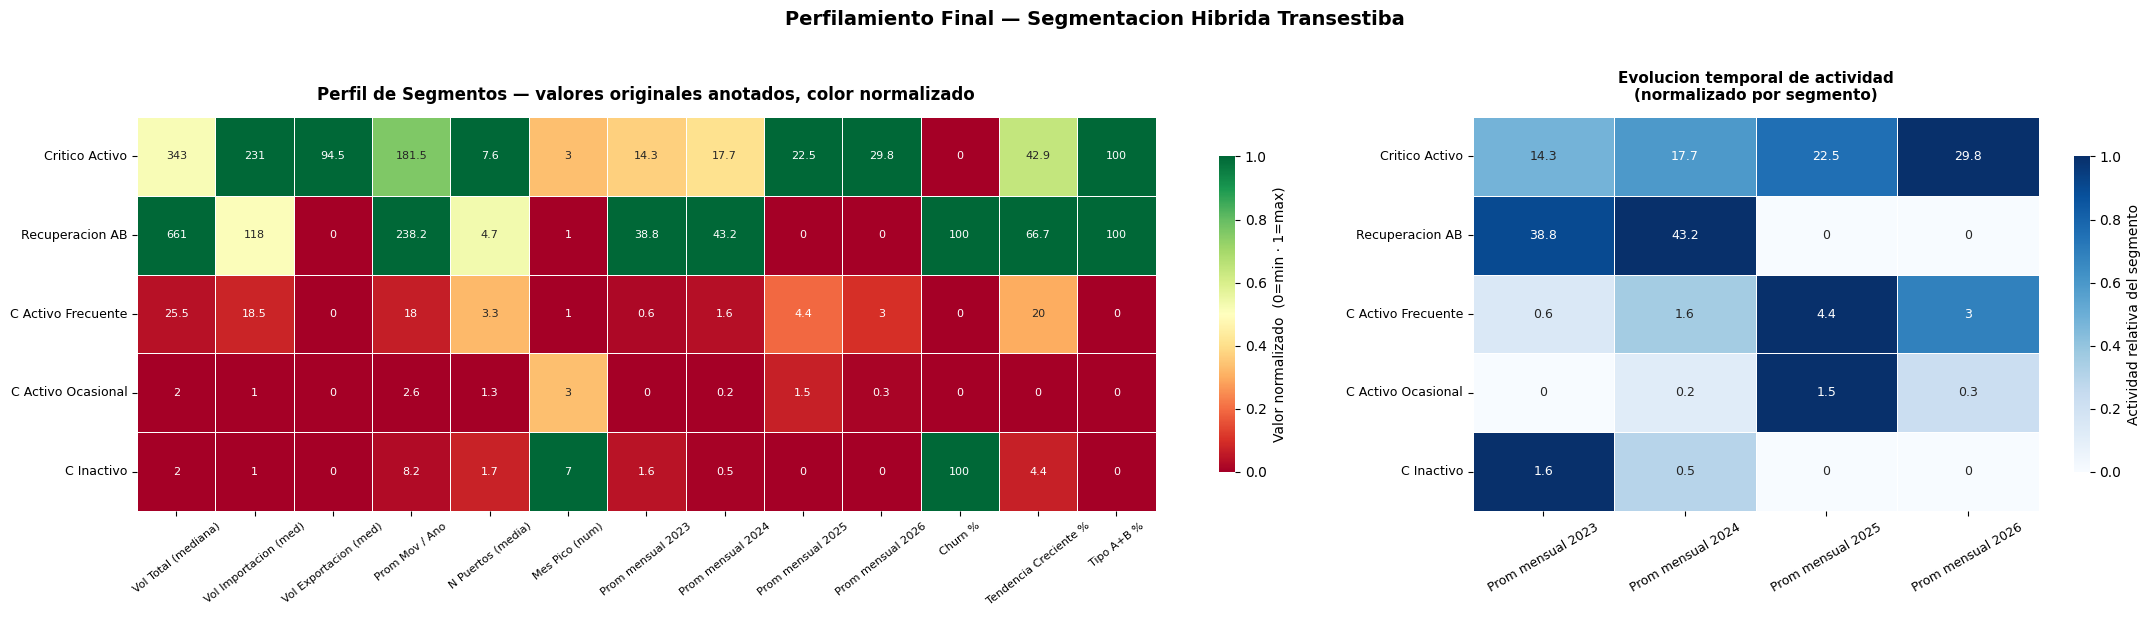

Guardado: heatmap_perfilamiento.png

PERFIL COMPLETO POR SEGMENTO
  Segmento                  N   Vol_med  Mov/Ano  Puertos  Mes Pico   P2025   P2026
------------------------------------------------------------------------
  Critico Activo           14       343    181.5      7.6       Mar    22.5    29.8
  Recuperacion AB           3       661    238.2      4.7       Ene     0.0     0.0
  C Activo Frecuente       30        26     18.0      3.3       Ene     4.4     3.0
  C Activo Ocasional       43         2      2.6      1.3       Mar     1.5     0.3
  C Inactivo               45         2      8.2      1.7       Jul     0.0     0.0
  Columnas: Vol_med=mediana Vol_Total | Mov/Ano=prom movimientos/ano
            Puertos=media N puertos   | Mes Pico=mes mayor actividad historica


In [18]:
# ============================================================
# Mapa de Calor — Perfilamiento por Segmento (valores normalizados)
# ============================================================

SEG_ORDEN = ['Critico Activo','Recuperacion AB',
             'C Activo Frecuente','C Activo Ocasional','C Inactivo']

MESES_NOM = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
             7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

# ── 0. Mes pico por segmento (desde transacciones) ───────────
df_pico = data.copy()
df_pico['Mes'] = df_pico['Fecha'].dt.month
df_pico = df_pico.merge(df_clientes[['Cliente','Seg_Final']],
                        on='Cliente', how='left')
df_pico = df_pico[df_pico['Seg_Final'].notna()]

mes_pico_num = (df_pico.groupby(['Seg_Final','Mes'])
                       .size()
                       .reset_index(name='Mov')
                       .sort_values('Mov', ascending=False)
                       .groupby('Seg_Final').first()['Mes'])

# ── 1. Construir tabla de metricas por segmento ───────────────
perfil_raw = pd.DataFrame({
    seg: {
        'Vol Total (mediana)':   df_clientes[df_clientes['Seg_Final']==seg]['Vol_Total'].median(),
        'Vol Importacion (med)': df_clientes[df_clientes['Seg_Final']==seg]['Vol_Imp'].median(),
        'Vol Exportacion (med)': df_clientes[df_clientes['Seg_Final']==seg]['Vol_Exp'].median(),
        'Prom Mov / Ano':        df_clientes[df_clientes['Seg_Final']==seg]['Prom_Mov_Año'].mean(),
        'N Puertos (media)':     df_clientes[df_clientes['Seg_Final']==seg]['Num_Puertos'].mean(),
        'Mes Pico (num)':        mes_pico_num.get(seg, 0),
        'Prom mensual 2023':     df_clientes[df_clientes['Seg_Final']==seg]['Prom_2023'].mean(),
        'Prom mensual 2024':     df_clientes[df_clientes['Seg_Final']==seg]['Prom_2024'].mean(),
        'Prom mensual 2025':     df_clientes[df_clientes['Seg_Final']==seg]['Prom_2025'].mean(),
        'Prom mensual 2026':     df_clientes[df_clientes['Seg_Final']==seg]['Prom_2026'].mean(),
        'Churn %':               df_clientes[df_clientes['Seg_Final']==seg]['Churn'].mean() * 100,
        'Tendencia Creciente %': (df_clientes[df_clientes['Seg_Final']==seg]['Tendencia'] == 'Creciente').mean() * 100,
        'Tipo A+B %':            df_clientes[df_clientes['Seg_Final']==seg]['Tipo_Cliente'].isin(['A','B']).mean() * 100,
    }
    for seg in SEG_ORDEN
}).T

# ── 2. Normalizacion min-max por columna ─────────────────────
perfil_norm = (perfil_raw - perfil_raw.min()) / (perfil_raw.max() - perfil_raw.min() + 1e-9)

# ── 3. Heatmap ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 6),
                         gridspec_kw={'width_ratios': [1.8, 1]})

sns.heatmap(
    perfil_norm,
    ax=axes[0],
    annot=perfil_raw.round(1),
    fmt='g',
    cmap='RdYlGn',
    vmin=0, vmax=1,
    linewidths=0.6, linecolor='white',
    annot_kws={'size': 8},
    cbar_kws={'label': 'Valor normalizado  (0=min · 1=max)', 'shrink': 0.8},
)
axes[0].set_title('Perfil de Segmentos — valores originales anotados, color normalizado',
                  fontsize=12, fontweight='bold', pad=12)
axes[0].tick_params(axis='x', rotation=38, labelsize=8)
axes[0].tick_params(axis='y', rotation=0,  labelsize=9)

trend_cols = ['Prom mensual 2023','Prom mensual 2024','Prom mensual 2025','Prom mensual 2026']
trend_raw  = perfil_raw[trend_cols]
trend_norm = trend_raw.div(trend_raw.max(axis=1) + 1e-9, axis=0)

sns.heatmap(
    trend_norm,
    ax=axes[1],
    annot=trend_raw.round(1),
    fmt='g',
    cmap='Blues',
    vmin=0, vmax=1,
    linewidths=0.6, linecolor='white',
    annot_kws={'size': 9},
    cbar_kws={'label': 'Actividad relativa del segmento', 'shrink': 0.8},
)
axes[1].set_title('Evolucion temporal de actividad' + chr(10) + '(normalizado por segmento)',
                  fontsize=11, fontweight='bold', pad=12)
axes[1].tick_params(axis='x', rotation=30, labelsize=9)
axes[1].tick_params(axis='y', rotation=0,  labelsize=9)

plt.suptitle('Perfilamiento Final — Segmentacion Hibrida Transestiba',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('heatmap_perfilamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: heatmap_perfilamiento.png')

# ── 4. Tabla de perfil completo por segmento ─────────────────
print()
print('=' * 72)
print('PERFIL COMPLETO POR SEGMENTO')
print('=' * 72)
print(f'  {"Segmento":<22} {"N":>4}  {"Vol_med":>8}  {"Mov/Ano":>7}  '
      f'{"Puertos":>7}  {"Mes Pico":>8}  {"P2025":>6}  {"P2026":>6}')
print('-' * 72)
for seg in SEG_ORDEN:
    sub      = df_clientes[df_clientes['Seg_Final'] == seg]
    n        = len(sub)
    vol_med  = sub['Vol_Total'].median()
    mov_ano  = sub['Prom_Mov_Año'].mean()
    puertos  = sub['Num_Puertos'].mean()
    mes_n    = int(mes_pico_num.get(seg, 0))
    mes_nom  = MESES_NOM.get(mes_n, '?')
    p2025    = sub['Prom_2025'].mean()
    p2026    = sub['Prom_2026'].mean()
    print(f'  {seg:<22} {n:>4}  {vol_med:>8,.0f}  {mov_ano:>7.1f}  '
          f'{puertos:>7.1f}  {mes_nom:>8}  {p2025:>6.1f}  {p2026:>6.1f}')
print('=' * 72)
print('  Columnas: Vol_med=mediana Vol_Total | Mov/Ano=prom movimientos/ano')
print('            Puertos=media N puertos   | Mes Pico=mes mayor actividad historica')

# Prueba de otros modelos

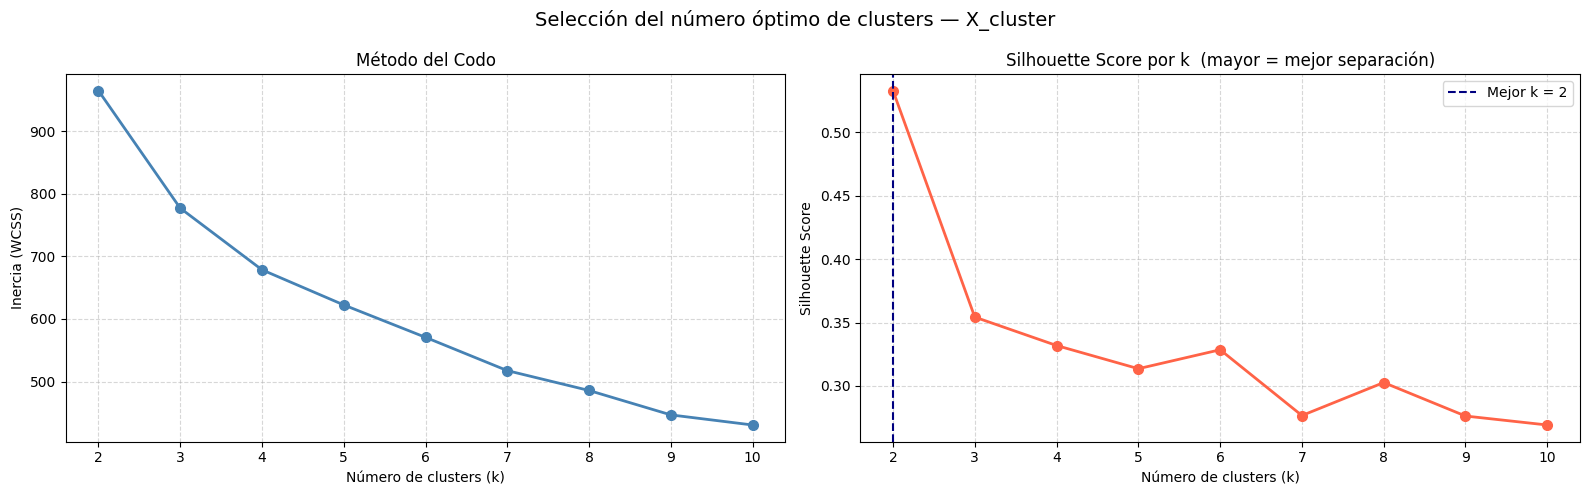

  k       Inercia    Silhouette
------------------------------
  2         964.9        0.5330 ◄ mejor silhouette
  3         777.1        0.3543
  4         678.5        0.3319
  5         622.4        0.3136
  6         570.6        0.3286
  7         517.5        0.2767
  8         485.7        0.3027
  9         446.7        0.2763
 10         430.6        0.2692


In [19]:
# ============================================================
# Determinación del K óptimo — Método del Codo + Silhouette Score
# ============================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range   = range(2, 11)
inertias  = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Método del Codo ───────────────────────────────────────────
axes[0].plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia (WCSS)")
axes[0].set_title("Método del Codo")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_xticks(list(K_range))

# ── Silhouette Score ──────────────────────────────────────────
axes[1].plot(K_range, sil_scores, 'o-', color='tomato', linewidth=2, markersize=7)
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score por k  (mayor = mejor separación)")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_xticks(list(K_range))

# Marcar el mejor k por silhouette
best_k = list(K_range)[sil_scores.index(max(sil_scores))]
axes[1].axvline(best_k, color='navy', linestyle='--', linewidth=1.5,
                label=f'Mejor k = {best_k}')
axes[1].legend()

plt.suptitle("Selección del número óptimo de clusters — X_cluster", fontsize=14)
plt.tight_layout()
plt.show()

# Resumen numérico
print(f"{'k':>3}  {'Inercia':>12}  {'Silhouette':>12}")
print("-" * 30)
for k, iner, sil in zip(K_range, inertias, sil_scores):
    mark = " ◄ mejor silhouette" if k == best_k else ""
    print(f"{k:>3}  {iner:>12.1f}  {sil:>12.4f}{mark}")

Silhouette Score  k=2: 0.4722

Distribución de clusters:
Cluster
0     29
1    106

Clientes representativos (medoids):
  Cluster 0: PROALCO CIA. LTDA.
  Cluster 1: HIPER BRAKE JB S.A.S.


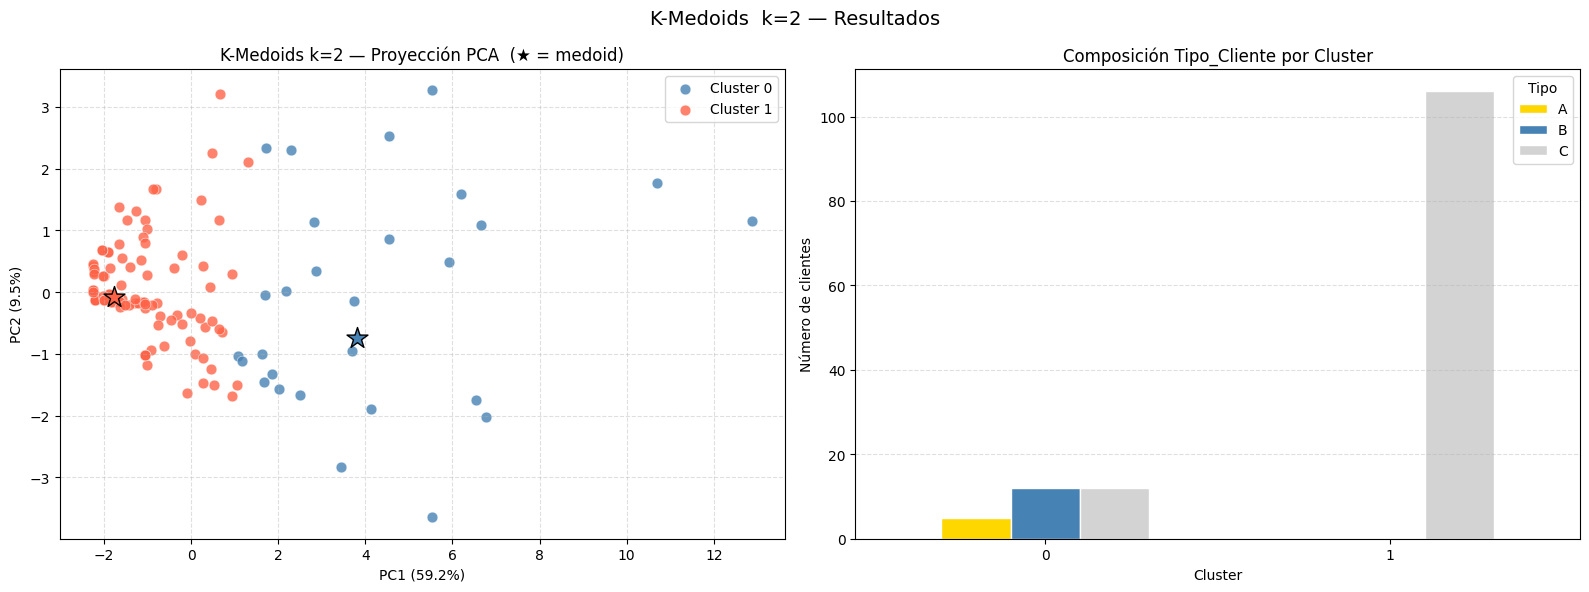


Perfil de clusters (valores promedio originales):
Cluster           0      1
Vol_Total     515.4    8.2
Vol_Imp       284.7    5.0
Vol_Exp       230.7    3.2
Num_Puertos     5.9    1.7
Prom_Mov_Año  122.7    6.8
Prom_2024      14.0    0.5
Prom_2025      13.3    1.2
Prom_2026      15.3    0.8
N_clientes     29.0  106.0
Churn_%        17.2   40.6
Tipo_A_%       17.2    0.0
Tipo_B_%       41.4    0.0


In [20]:
# ============================================================
# K-Medoids  k = 2  (implementación pura numpy/scipy)
# ============================================================
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

def kmedoids(X, k, random_state=42, max_iter=300):
    """PAM simplificado: medoids reales del dataset, sin dependencias C++."""
    rng = np.random.default_rng(random_state)
    X   = np.array(X)
    n   = len(X)
    D   = cdist(X, X, metric='euclidean')          # matriz de distancias n×n

    medoid_idx = rng.choice(n, k, replace=False)   # inicialización aleatoria

    for _ in range(max_iter):
        # Asignación: cada punto al medoid más cercano
        labels = np.argmin(D[:, medoid_idx], axis=1)

        # Actualización: medoid = punto con menor suma de distancias al cluster
        new_medoids = medoid_idx.copy()
        for c in range(k):
            idx_c = np.where(labels == c)[0]
            if len(idx_c) == 0:
                continue
            costs = D[np.ix_(idx_c, idx_c)].sum(axis=1)
            new_medoids[c] = idx_c[np.argmin(costs)]

        if np.array_equal(np.sort(new_medoids), np.sort(medoid_idx)):
            break
        medoid_idx = new_medoids

    labels = np.argmin(D[:, medoid_idx], axis=1)
    return labels, medoid_idx

# ── Ajuste ────────────────────────────────────────────────────
K = 2
labels_kmed, medoid_idx = kmedoids(X_cluster.values, K, random_state=42)

df_clientes['Cluster'] = labels_kmed
df_te['Cluster']       = labels_kmed

sil = silhouette_score(X_cluster, labels_kmed)
print(f"Silhouette Score  k={K}: {sil:.4f}")
print(f"\nDistribución de clusters:")
print(pd.Series(labels_kmed, name='Cluster').value_counts().sort_index().to_string())
print(f"\nClientes representativos (medoids):")
for mid in medoid_idx:
    print(f"  Cluster {labels_kmed[mid]}: {df_clientes.iloc[mid]['Cliente']}")

# ── Visualización PCA 2D ──────────────────────────────────────
pca_vis  = PCA(n_components=2, random_state=42)
coords2d = pca_vis.fit_transform(X_cluster)
ev       = pca_vis.explained_variance_ratio_

cluster_colors = {0: 'steelblue', 1: 'tomato'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for c in range(K):
    idx = np.where(labels_kmed == c)[0]
    axes[0].scatter(coords2d[idx, 0], coords2d[idx, 1],
                    color=cluster_colors[c], label=f'Cluster {c}',
                    alpha=0.8, s=60, edgecolors='white', linewidths=0.4)
for mid in medoid_idx:
    cl = labels_kmed[mid]
    axes[0].scatter(coords2d[mid, 0], coords2d[mid, 1],
                    color=cluster_colors[cl], s=250, marker='*',
                    edgecolors='black', linewidths=1, zorder=5)
axes[0].set_title(f"K-Medoids k={K} — Proyección PCA  (★ = medoid)")
axes[0].set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# Composición Tipo_Cliente por cluster
ct = pd.crosstab(df_clientes['Cluster'], df_clientes['Tipo_Cliente'])
ct.plot(kind='bar', ax=axes[1], color=['gold', 'steelblue', 'lightgray'],
        edgecolor='white', width=0.6)
axes[1].set_title("Composición Tipo_Cliente por Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Número de clientes")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Tipo')
axes[1].grid(True, linestyle='--', alpha=0.4, axis='y')

plt.suptitle("K-Medoids  k=2 — Resultados", fontsize=14)
plt.tight_layout()
plt.show()

# ── Perfil de cada cluster ─────────────────────────────────────
profile_cols = ['Vol_Total', 'Vol_Imp', 'Vol_Exp', 'Num_Puertos',
                'Prom_Mov_Año', 'Prom_2024', 'Prom_2025', 'Prom_2026']
perfil = df_clientes.groupby('Cluster')[profile_cols].mean().round(1)
perfil['N_clientes'] = df_clientes.groupby('Cluster').size()
perfil['Churn_%']    = (df_clientes.groupby('Cluster')['Churn'].mean() * 100).round(1)
perfil['Tipo_A_%']   = (df_clientes.groupby('Cluster')['Tipo_Cliente']
                         .apply(lambda x: (x == 'A').mean() * 100)).round(1)
perfil['Tipo_B_%']   = (df_clientes.groupby('Cluster')['Tipo_Cliente']
                         .apply(lambda x: (x == 'B').mean() * 100)).round(1)
print("\nPerfil de clusters (valores promedio originales):")
print(perfil.T.to_string())

Silhouette Score  k=4: 0.2362

Distribución de clusters:
Cluster
0    23
1    13
2    60
3    39

Clientes representativos (medoids):
  Cluster 0: ALBAN RODRIGUEZ JAVIER IGNACIO
  Cluster 1: LOGISTICS UNLIMITED S.A. LOGUNSA
  Cluster 2: COMERCIALIZADORA DARPA S. A.
  Cluster 3: VICTOR HUGO PAREDES UBILLUS


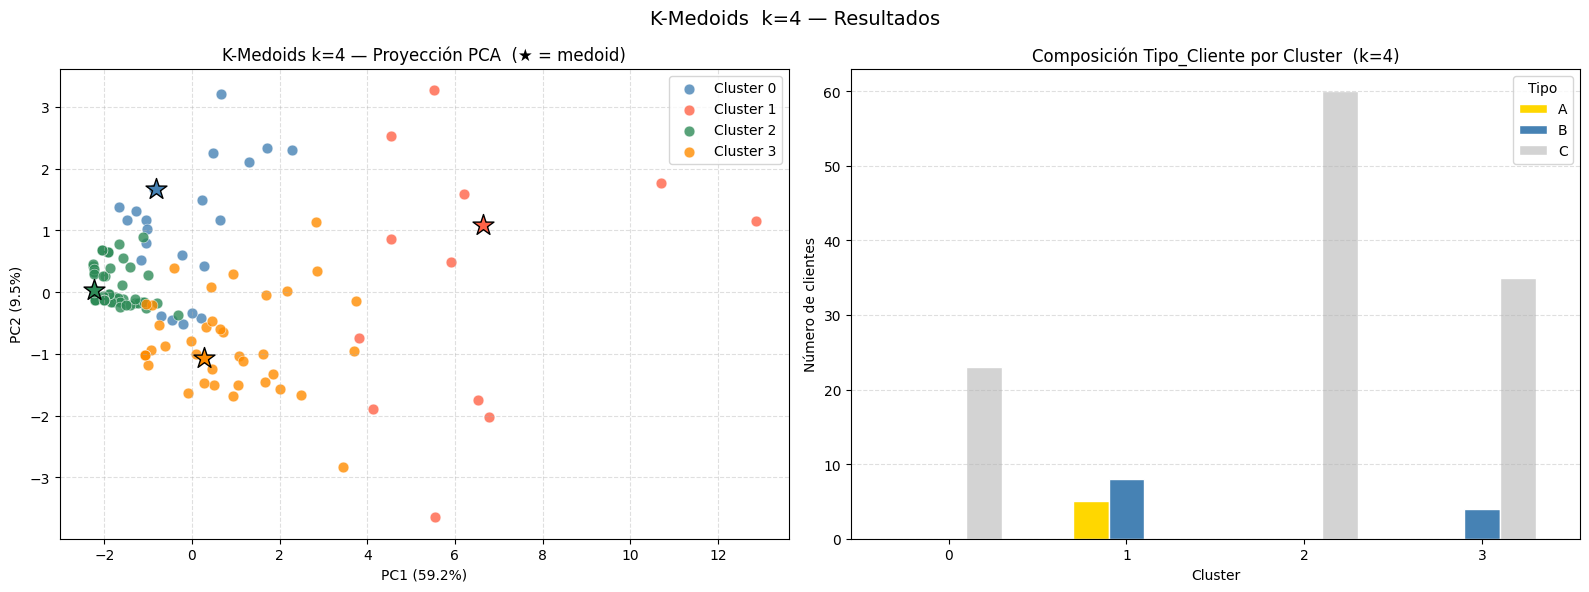


Perfil de clusters k=4 (valores promedio originales):
Cluster_k4       0       1     2     3
Vol_Total     23.8  1052.1   2.4  37.0
Vol_Imp        4.6   574.4   2.0  28.1
Vol_Exp       19.2   477.7   0.4   9.0
Num_Puertos    2.8     7.9   1.2   3.0
Prom_Mov_Año  19.0   239.3   2.3  15.1
Prom_2024      0.3    25.9   0.2   2.6
Prom_2025      1.8    23.5   0.9   2.7
Prom_2026      0.3    31.4   0.2   2.5
N_clientes    23.0    13.0  60.0  39.0
Churn_%       60.9    15.4  43.3  15.4
Tipo_A_%       0.0    38.5   0.0   0.0
Tipo_B_%       0.0    61.5   0.0  10.3


In [21]:
# ============================================================
# K-Medoids  k = 4  (misma implementación PAM)
# ============================================================
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

K4 = 4
labels_k4, medoid_idx4 = kmedoids(X_cluster.values, K4, random_state=42)

df_clientes['Cluster_k4'] = labels_k4
df_te['Cluster_k4']       = labels_k4

sil4 = silhouette_score(X_cluster, labels_k4)
print(f"Silhouette Score  k={K4}: {sil4:.4f}")
print(f"\nDistribución de clusters:")
print(pd.Series(labels_k4, name='Cluster').value_counts().sort_index().to_string())
print(f"\nClientes representativos (medoids):")
for mid in medoid_idx4:
    print(f"  Cluster {labels_k4[mid]}: {df_clientes.iloc[mid]['Cliente']}")

# ── Visualización PCA 2D ──────────────────────────────────────
pca_vis4  = PCA(n_components=2, random_state=42)
coords2d4 = pca_vis4.fit_transform(X_cluster)
ev4       = pca_vis4.explained_variance_ratio_

cluster_colors4 = {0: 'steelblue', 1: 'tomato', 2: 'seagreen', 3: 'darkorange'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for c in range(K4):
    idx = np.where(labels_k4 == c)[0]
    axes[0].scatter(coords2d4[idx, 0], coords2d4[idx, 1],
                    color=cluster_colors4[c], label=f'Cluster {c}',
                    alpha=0.8, s=60, edgecolors='white', linewidths=0.4)
for mid in medoid_idx4:
    cl = labels_k4[mid]
    axes[0].scatter(coords2d4[mid, 0], coords2d4[mid, 1],
                    color=cluster_colors4[cl], s=250, marker='*',
                    edgecolors='black', linewidths=1, zorder=5)
axes[0].set_title(f"K-Medoids k={K4} — Proyección PCA  (★ = medoid)")
axes[0].set_xlabel(f"PC1 ({ev4[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({ev4[1]*100:.1f}%)")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# Composición Tipo_Cliente por cluster
ct4 = pd.crosstab(df_clientes['Cluster_k4'], df_clientes['Tipo_Cliente'])
ct4.plot(kind='bar', ax=axes[1], color=['gold', 'steelblue', 'lightgray'],
         edgecolor='white', width=0.6)
axes[1].set_title("Composición Tipo_Cliente por Cluster  (k=4)")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Número de clientes")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Tipo')
axes[1].grid(True, linestyle='--', alpha=0.4, axis='y')

plt.suptitle("K-Medoids  k=4 — Resultados", fontsize=14)
plt.tight_layout()
plt.show()

# ── Perfil de cada cluster ─────────────────────────────────────
profile_cols = ['Vol_Total', 'Vol_Imp', 'Vol_Exp', 'Num_Puertos',
                'Prom_Mov_Año', 'Prom_2024', 'Prom_2025', 'Prom_2026']
perfil4 = df_clientes.groupby('Cluster_k4')[profile_cols].mean().round(1)
perfil4['N_clientes'] = df_clientes.groupby('Cluster_k4').size()
perfil4['Churn_%']    = (df_clientes.groupby('Cluster_k4')['Churn'].mean() * 100).round(1)
perfil4['Tipo_A_%']   = (df_clientes.groupby('Cluster_k4')['Tipo_Cliente']
                          .apply(lambda x: (x == 'A').mean() * 100)).round(1)
perfil4['Tipo_B_%']   = (df_clientes.groupby('Cluster_k4')['Tipo_Cliente']
                          .apply(lambda x: (x == 'B').mean() * 100)).round(1)
print("\nPerfil de clusters k=4 (valores promedio originales):")
print(perfil4.T.to_string())

DBSCAN  eps=2.0, min_samples=10
  Clusters encontrados : 1
  Puntos ruido (-1)    : 39  (28.9%)
  Silhouette Score     : N/A (≤1 cluster con datos válidos)


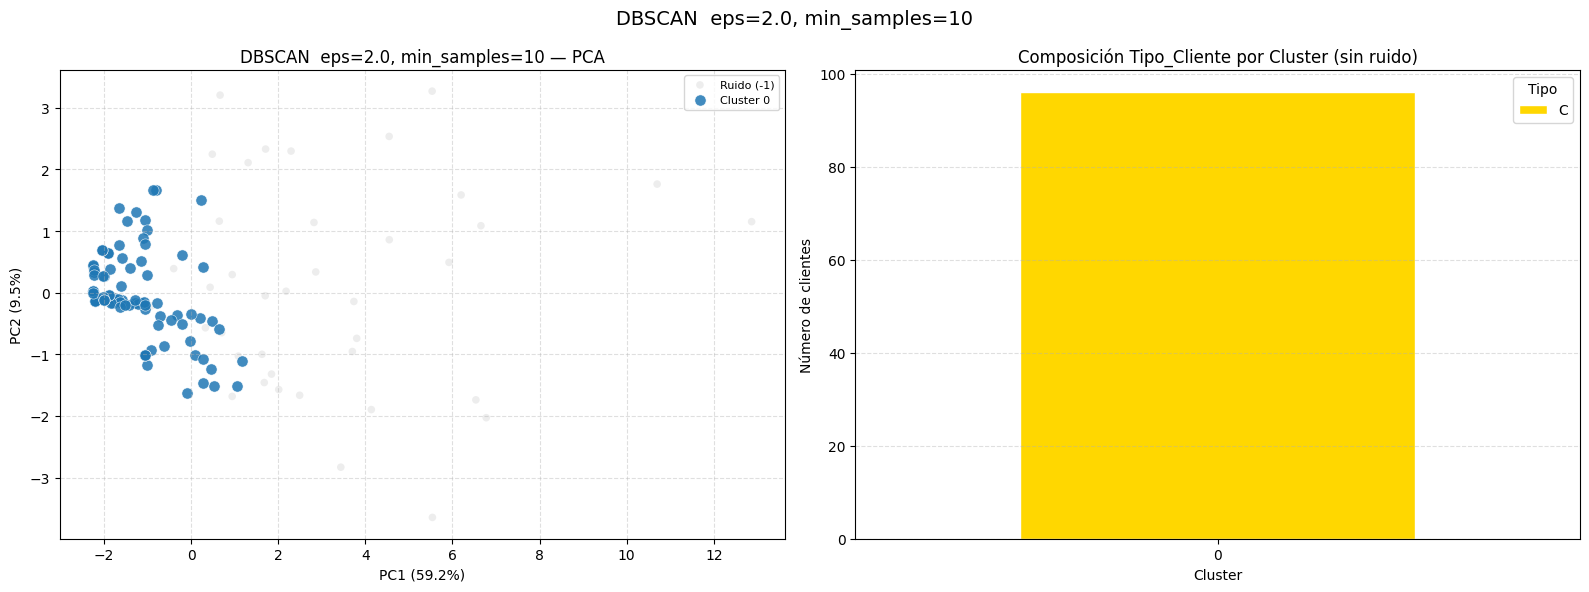


Perfil de clusters DBSCAN (sin 39 puntos ruido):
Cluster_db       0
Vol_Total      5.5
Vol_Imp        4.4
Vol_Exp        1.1
Num_Puertos    1.6
Prom_Mov_Año   4.3
Prom_2024      0.4
Prom_2025      1.1
Prom_2026      0.2
N_clientes    96.0
Churn_%       39.6
Tipo_A_%       0.0


In [22]:
# ============================================================
# DBSCAN — exploración inicial  eps=2, min_samples=10
# ============================================================
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

def run_dbscan(X, eps, min_samples):
    """Ajusta DBSCAN y devuelve labels + métricas clave."""
    lbl = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean').fit_predict(X)
    n_clusters  = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise     = int((lbl == -1).sum())
    mask_valid  = lbl != -1
    sil = (silhouette_score(X[mask_valid], lbl[mask_valid])
           if n_clusters >= 2 and mask_valid.sum() > n_clusters
           else np.nan)
    return lbl, n_clusters, n_noise, sil

EPS, MIN_S = 2.0, 10
X_arr = X_cluster.values

labels_db, n_cl, n_noise, sil_db = run_dbscan(X_arr, EPS, MIN_S)

print(f"DBSCAN  eps={EPS}, min_samples={MIN_S}")
print(f"  Clusters encontrados : {n_cl}")
print(f"  Puntos ruido (-1)    : {n_noise}  ({n_noise/len(X_arr)*100:.1f}%)")
if not np.isnan(sil_db):
    print(f"  Silhouette Score     : {sil_db:.4f}")
else:
    print("  Silhouette Score     : N/A (≤1 cluster con datos válidos)")

# ── Proyección PCA 2D ─────────────────────────────────────────
pca_db    = PCA(n_components=2, random_state=42)
coords_db = pca_db.fit_transform(X_arr)
ev_db     = pca_db.explained_variance_ratio_

unique_lbl = sorted(set(labels_db))
palette    = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter PCA
for cl in unique_lbl:
    idx  = np.where(labels_db == cl)[0]
    col  = 'lightgray' if cl == -1 else palette[cl % len(palette)]
    lbl_str = 'Ruido (-1)' if cl == -1 else f'Cluster {cl}'
    axes[0].scatter(coords_db[idx, 0], coords_db[idx, 1],
                    color=col, label=lbl_str,
                    alpha=0.4 if cl == -1 else 0.85,
                    s=30 if cl == -1 else 65,
                    edgecolors='none' if cl == -1 else 'white', linewidths=0.4)
axes[0].set_title(f"DBSCAN  eps={EPS}, min_samples={MIN_S} — PCA")
axes[0].set_xlabel(f"PC1 ({ev_db[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({ev_db[1]*100:.1f}%)")
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Composición Tipo_Cliente (sin ruido)
df_clientes['Cluster_db'] = labels_db
df_no_noise = df_clientes[df_clientes['Cluster_db'] != -1]
if n_cl >= 1 and len(df_no_noise) > 0:
    ct_db = pd.crosstab(df_no_noise['Cluster_db'], df_no_noise['Tipo_Cliente'])
    ct_db.plot(kind='bar', ax=axes[1], color=['gold', 'steelblue', 'lightgray'],
               edgecolor='white', width=0.6)
    axes[1].set_title("Composición Tipo_Cliente por Cluster (sin ruido)")
    axes[1].set_xlabel("Cluster")
    axes[1].set_ylabel("Número de clientes")
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(title='Tipo')
    axes[1].grid(True, linestyle='--', alpha=0.4, axis='y')
else:
    axes[1].text(0.5, 0.5, 'Sin clusters válidos', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=13)
    axes[1].axis('off')

plt.suptitle(f"DBSCAN  eps={EPS}, min_samples={MIN_S}", fontsize=14)
plt.tight_layout()
plt.show()

# ── Perfil de clusters ────────────────────────────────────────
if n_cl >= 1 and len(df_no_noise) > 0:
    profile_cols = ['Vol_Total', 'Vol_Imp', 'Vol_Exp', 'Num_Puertos',
                    'Prom_Mov_Año', 'Prom_2024', 'Prom_2025', 'Prom_2026']
    perfil_db = df_no_noise.groupby('Cluster_db')[profile_cols].mean().round(1)
    perfil_db['N_clientes'] = df_no_noise.groupby('Cluster_db').size()
    perfil_db['Churn_%']    = (df_no_noise.groupby('Cluster_db')['Churn'].mean() * 100).round(1)
    perfil_db['Tipo_A_%']   = (df_no_noise.groupby('Cluster_db')['Tipo_Cliente']
                                .apply(lambda x: (x == 'A').mean() * 100)).round(1)
    print(f"\nPerfil de clusters DBSCAN (sin {n_noise} puntos ruido):")
    print(perfil_db.T.to_string())

Grid Search DBSCAN — resultados completos
  eps   min_s   n_cl   ruido   ruido%   silhouette
───────────────────────────────────────────────────────
  0.5       3      7     103    76.3%       0.8310
  0.5       5      3     116    85.9%       0.8562
  0.5       7      1     126    93.3%          N/A
  0.5      10      0     135   100.0%          N/A
  0.5      15      0     135   100.0%          N/A
  0.5      20      0     135   100.0%          N/A
  0.8       3     10      79    58.5%       0.5200
  0.8       5      3     105    77.8%       0.6069
  0.8       7      2     110    81.5%       0.5814
  0.8      10      1     117    86.7%          N/A
  0.8      15      1     120    88.9%          N/A
  0.8      20      0     135   100.0%          N/A
  1.0       3      6      76    56.3%       0.3851
  1.0       5      5      87    64.4%       0.4086
  1.0       7      3     100    74.1%       0.4765
  1.0      10      1     115    85.2%          N/A
  1.0      15      1     115    85.

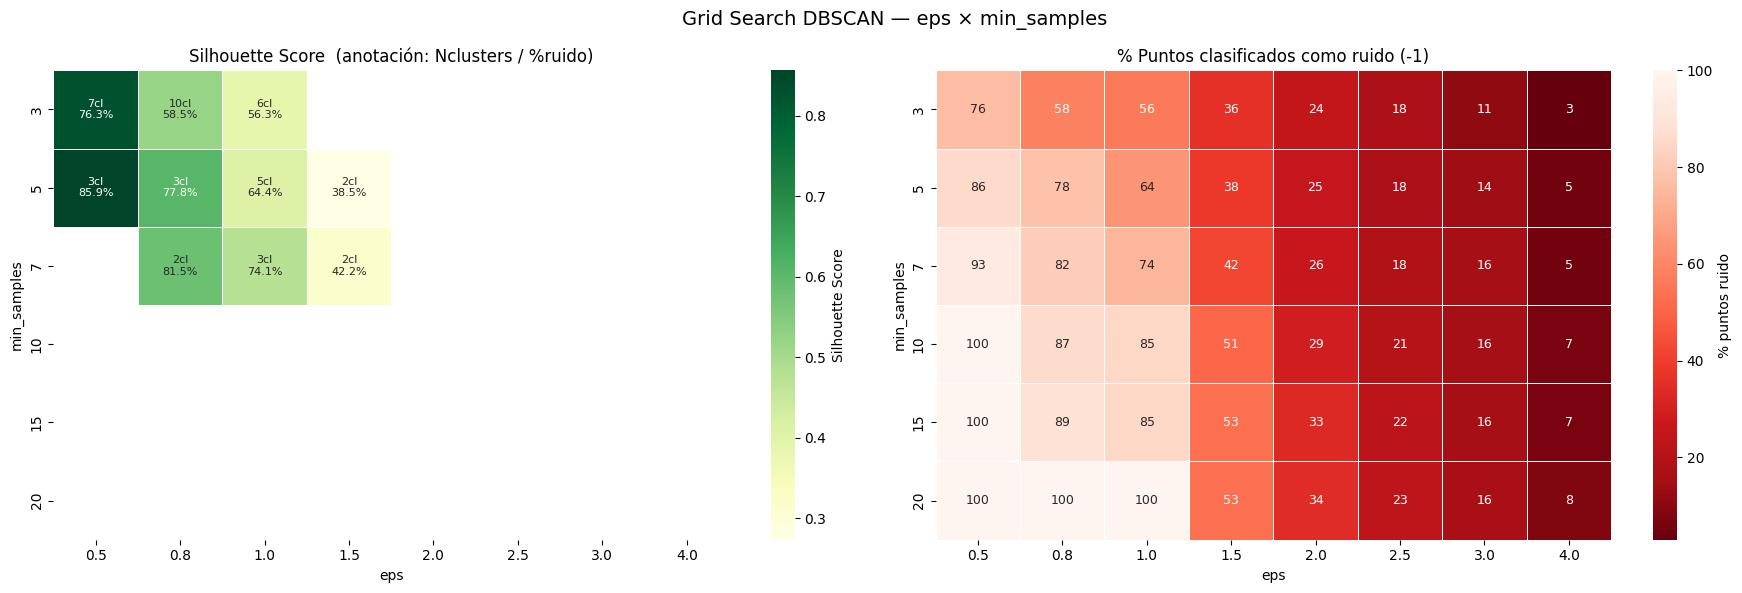

In [23]:
# ============================================================
# DBSCAN — Grid Search  (eps × min_samples)
# ============================================================
import itertools

eps_values        = [0.5, 0.8, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0]
min_samples_values = [3, 5, 7, 10, 15, 20]

results = []
for eps, ms in itertools.product(eps_values, min_samples_values):
    lbl, n_cl, n_noise, sil = run_dbscan(X_arr, eps, ms)
    results.append({
        'eps': eps, 'min_samples': ms,
        'n_clusters': n_cl,
        'n_noise': n_noise,
        'noise_%': round(n_noise / len(X_arr) * 100, 1),
        'silhouette': round(sil, 4) if not np.isnan(sil) else np.nan,
        'labels': lbl,
    })

df_gs = pd.DataFrame(results)

# ── Tabla resumen ─────────────────────────────────────────────
print("Grid Search DBSCAN — resultados completos")
print(f"{'eps':>5}  {'min_s':>6}  {'n_cl':>5}  {'ruido':>6}  {'ruido%':>7}  {'silhouette':>11}")
print("─" * 55)
for _, row in df_gs.iterrows():
    sil_str = f"{row['silhouette']:.4f}" if not np.isnan(row['silhouette']) else "   N/A"
    print(f"{row['eps']:>5.1f}  {int(row['min_samples']):>6}  {int(row['n_clusters']):>5}  "
          f"{int(row['n_noise']):>6}  {row['noise_%']:>6.1f}%  {sil_str:>11}")

# ── Mejor configuración (silhouette máximo, ruido < 30%) ─────
valid = df_gs[(df_gs['n_clusters'] >= 2) & (df_gs['noise_%'] <= 30) & df_gs['silhouette'].notna()]
if len(valid) > 0:
    best = valid.loc[valid['silhouette'].idxmax()]
    print(f"\n{'='*55}")
    print(f"Mejor configuración (silhouette max, ruido ≤30%):")
    print(f"  eps={best['eps']}, min_samples={int(best['min_samples'])}")
    print(f"  Clusters: {int(best['n_clusters'])}  |  Ruido: {int(best['n_noise'])} ({best['noise_%']}%)")
    print(f"  Silhouette: {best['silhouette']:.4f}")
else:
    best = None
    print("\nNo se encontró configuración válida con ≥2 clusters y ruido ≤30%.")

# ── Heatmap silhouette: eps × min_samples ─────────────────────
pivot_sil   = df_gs.pivot(index='min_samples', columns='eps', values='silhouette')
pivot_noise = df_gs.pivot(index='min_samples', columns='eps', values='noise_%')
pivot_ncl   = df_gs.pivot(index='min_samples', columns='eps', values='n_clusters')

# Etiquetas combinadas: "Ncl / ruido%"
annot_labels = pivot_ncl.astype(str) + "cl\n" + pivot_noise.astype(str) + "%"

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Silhouette heatmap
sns.heatmap(
    pivot_sil, ax=axes[0],
    annot=annot_labels, fmt='', cmap='YlGn',
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 8},
    cbar_kws={'label': 'Silhouette Score'}
)
axes[0].set_title("Silhouette Score  (anotación: Nclusters / %ruido)")
axes[0].set_xlabel("eps")
axes[0].set_ylabel("min_samples")

# Ruido heatmap
sns.heatmap(
    pivot_noise, ax=axes[1],
    annot=True, fmt='.0f', cmap='Reds_r',
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9},
    cbar_kws={'label': '% puntos ruido'}
)
axes[1].set_title("% Puntos clasificados como ruido (-1)")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("min_samples")

plt.suptitle("Grid Search DBSCAN — eps × min_samples", fontsize=14)
plt.tight_layout()
plt.show()

# ── Visualizar mejor configuración ────────────────────────────
if best is not None:
    best_lbl = best['labels']
    df_clientes['Cluster_db_best'] = best_lbl

    pca_best    = PCA(n_components=2, random_state=42)
    coords_best = pca_best.fit_transform(X_arr)
    ev_best     = pca_best.explained_variance_ratio_

    unique_best = sorted(set(best_lbl))
    palette_b   = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for cl in unique_best:
        idx  = np.where(best_lbl == cl)[0]
        col  = 'lightgray' if cl == -1 else palette_b[cl % len(palette_b)]
        ls   = 'Ruido (-1)' if cl == -1 else f'Cluster {cl}'
        axes[0].scatter(coords_best[idx, 0], coords_best[idx, 1],
                        color=col, label=ls,
                        alpha=0.4 if cl == -1 else 0.85,
                        s=30 if cl == -1 else 65,
                        edgecolors='none' if cl == -1 else 'white', linewidths=0.4)
    axes[0].set_title(f"Mejor DBSCAN  eps={best['eps']}, min_samples={int(best['min_samples'])}")
    axes[0].set_xlabel(f"PC1 ({ev_best[0]*100:.1f}%)")
    axes[0].set_ylabel(f"PC2 ({ev_best[1]*100:.1f}%)")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, linestyle='--', alpha=0.4)

    df_best_nn = df_clientes[df_clientes['Cluster_db_best'] != -1]
    if len(df_best_nn) > 0:
        ct_best = pd.crosstab(df_best_nn['Cluster_db_best'], df_best_nn['Tipo_Cliente'])
        ct_best.plot(kind='bar', ax=axes[1], color=['gold', 'steelblue', 'lightgray'],
                     edgecolor='white', width=0.6)
        axes[1].set_title("Composición Tipo_Cliente — mejor configuración")
        axes[1].set_xlabel("Cluster")
        axes[1].set_ylabel("Número de clientes")
        axes[1].tick_params(axis='x', rotation=0)
        axes[1].legend(title='Tipo')
        axes[1].grid(True, linestyle='--', alpha=0.4, axis='y')

    plt.suptitle(f"DBSCAN óptimo  eps={best['eps']}, min_samples={int(best['min_samples'])}  "
                 f"| Sil={best['silhouette']:.4f}  Ruido={best['noise_%']}%", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Perfil clusters óptimos
    profile_cols = ['Vol_Total', 'Vol_Imp', 'Vol_Exp', 'Num_Puertos',
                    'Prom_Mov_Año', 'Prom_2024', 'Prom_2025', 'Prom_2026']
    perfil_best = df_best_nn.groupby('Cluster_db_best')[profile_cols].mean().round(1)
    perfil_best['N_clientes'] = df_best_nn.groupby('Cluster_db_best').size()
    perfil_best['Churn_%']    = (df_best_nn.groupby('Cluster_db_best')['Churn'].mean() * 100).round(1)
    perfil_best['Tipo_A_%']   = (df_best_nn.groupby('Cluster_db_best')['Tipo_Cliente']
                                  .apply(lambda x: (x == 'A').mean() * 100)).round(1)
    print(f"\nPerfil clusters — DBSCAN óptimo (sin puntos ruido):")
    print(perfil_best.T.to_string())

Perfil por cluster (k=4):
             N  Vol_Total_med  Vol_Total_mean  Vol_Total_sum  Vol_pct_total  Churn_pct  TipoAB_pct  Prom_2025_mean  Prom_2026_mean
Cluster_k4                                                                                                                        
0           23           11.0           23.83            548            3.5       0.61         0.0            1.80            0.32
1           13          542.0         1052.08          13677           86.5       0.15       100.0           23.54           31.37
2           60            1.5            2.37            142            0.9       0.43         0.0            0.95            0.15
3           39           23.0           37.03           1444            9.1       0.15        10.3            2.74            2.53

Asignación de segmentos estratégicos:
  Cluster 0 → Bajo Potencial
  Cluster 1 → Critico Activo
  Cluster 2 → Bajo Potencial
  Cluster 3 → Critico Activo

────────────────────────────────

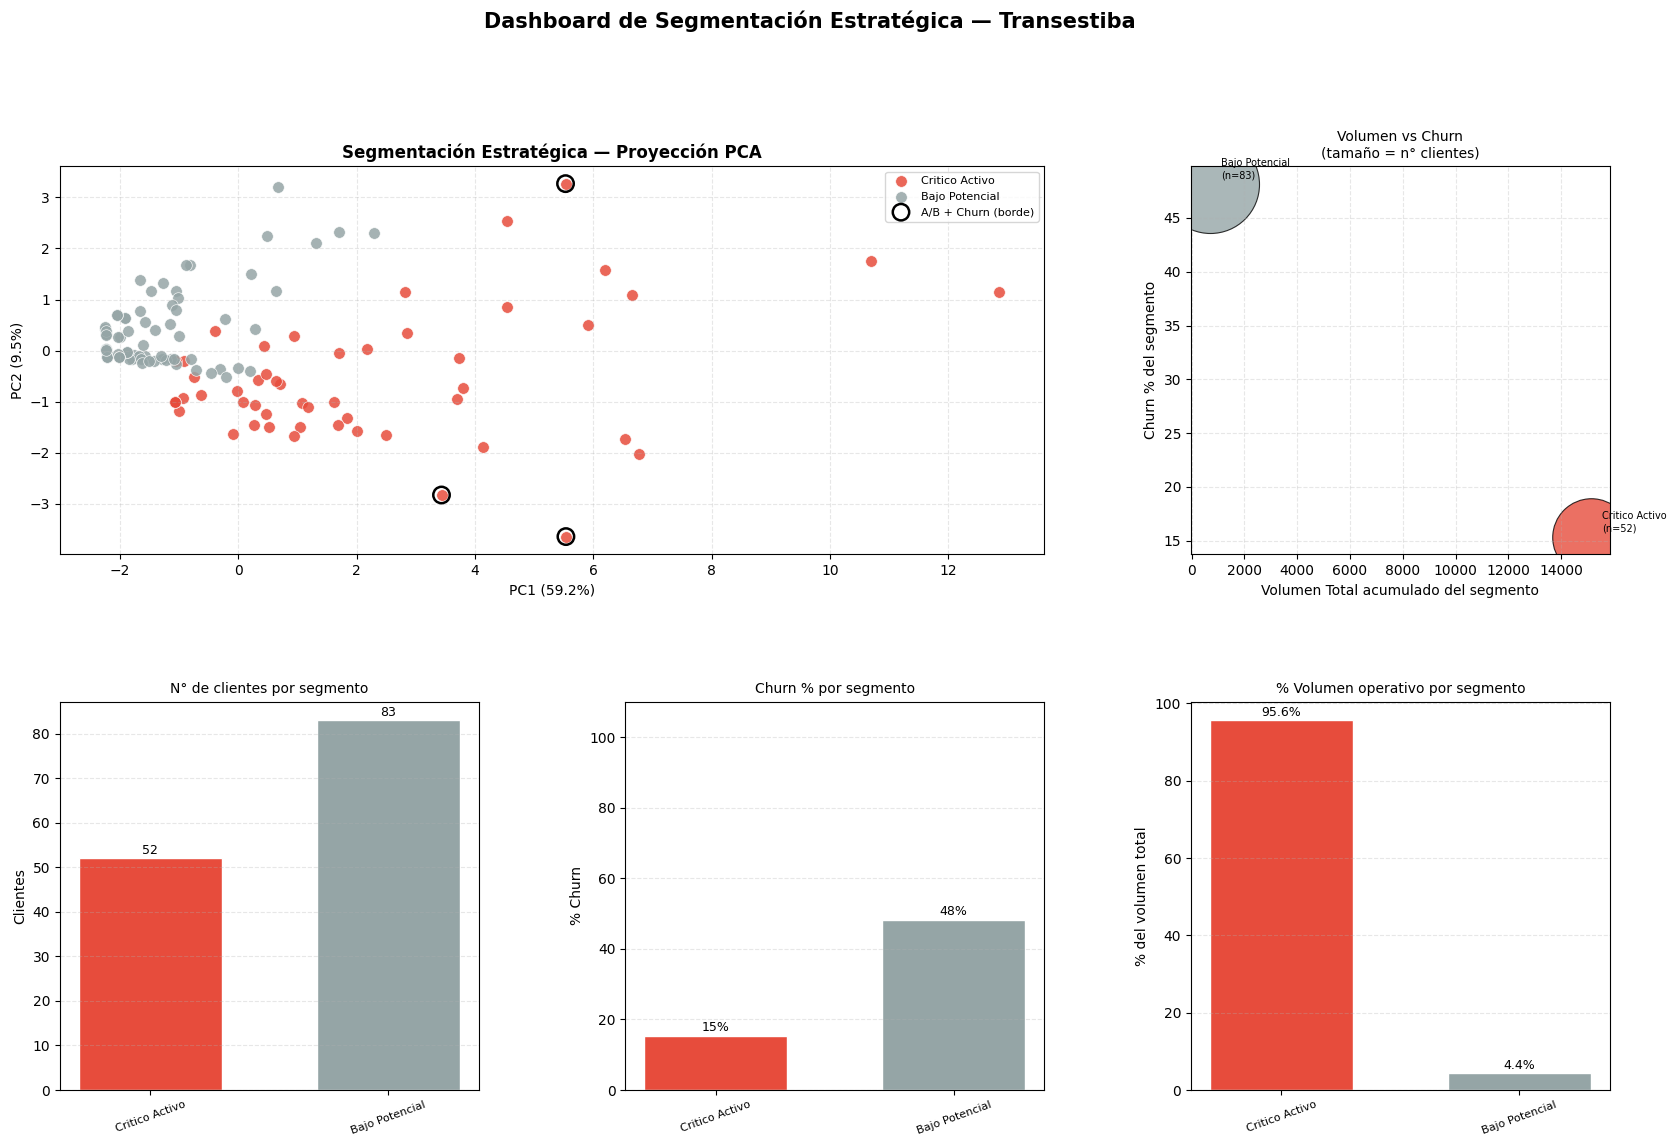

Gráfico guardado: segmentacion_estrategica.png


In [24]:
# ============================================================
# Segmentación Estratégica — K-Medoids k=4
#
# Objetivos:
#   1. Clientes Estables    → mantener y fidelizar
#   2. Críticos Activos     → mitigar riesgo operativo (alto volumen)
#   3. Recuperación A/B     → A/B con Churn=1, recuperar antes de perderlos
#   4. Bajo Potencial       → bajo volumen + inactivos → acciones mínimas
# ============================================================

# ── 1. Perfil base por cluster (valores originales) ───────────
perf = df_clientes.groupby('Cluster_k4').agg(
    N                = ('Cliente',      'count'),
    Vol_Total_med    = ('Vol_Total',    'median'),
    Vol_Total_mean   = ('Vol_Total',    'mean'),
    Vol_Total_sum    = ('Vol_Total',    'sum'),
    Churn_pct        = ('Churn',        'mean'),
    Prom_2025_mean   = ('Prom_2025',    'mean'),
    Prom_2026_mean   = ('Prom_2026',    'mean'),
    Num_Puertos_mean = ('Num_Puertos',  'mean'),
).round(2)

perf['TipoA_pct'] = df_clientes.groupby('Cluster_k4')['Tipo_Cliente'].apply(
    lambda x: (x == 'A').mean() * 100).round(1)
perf['TipoB_pct'] = df_clientes.groupby('Cluster_k4')['Tipo_Cliente'].apply(
    lambda x: (x == 'B').mean() * 100).round(1)
perf['TipoAB_pct'] = perf['TipoA_pct'] + perf['TipoB_pct']
perf['Vol_pct_total'] = (perf['Vol_Total_sum'] / perf['Vol_Total_sum'].sum() * 100).round(1)

print("Perfil por cluster (k=4):")
print(perf[['N', 'Vol_Total_med', 'Vol_Total_mean', 'Vol_Total_sum',
            'Vol_pct_total', 'Churn_pct', 'TipoAB_pct',
            'Prom_2025_mean', 'Prom_2026_mean']].to_string())

# ── 2. Asignación de etiqueta estratégica ─────────────────────
# Reglas basadas en volumen relativo, presencia A/B y churn
vol_umbral_alto = perf['Vol_Total_med'].quantile(0.60)   # clusters de alto volumen

def asignar_segmento(row):
    es_alto_valor = (row['TipoAB_pct'] > 10) or (row['Vol_Total_med'] >= vol_umbral_alto)
    churn_alto    = row['Churn_pct'] >= 0.35

    if es_alto_valor and churn_alto:
        return 'Recuperacion A/B'       # alto volumen, dejó de operar → rescatar
    elif es_alto_valor and not churn_alto:
        return 'Critico Activo'         # alto volumen activo → proteger a toda costa
    elif not es_alto_valor and not churn_alto:
        return 'Estable'                # bajo/medio volumen, activo regular → mantener
    else:
        return 'Bajo Potencial'         # bajo volumen + inactivo → acción mínima

perf['Segmento'] = perf.apply(asignar_segmento, axis=1)
seg_map = perf['Segmento'].to_dict()
df_clientes['Segmento'] = df_clientes['Cluster_k4'].map(seg_map)

print(f"\nAsignación de segmentos estratégicos:")
for cl, seg in seg_map.items():
    print(f"  Cluster {cl} → {seg}")

# ── 3. Tabla estratégica consolidada ──────────────────────────
print(f"\n{'─'*75}")
print("TABLA ESTRATÉGICA DE SEGMENTOS")
print(f"{'─'*75}")
for seg in ['Critico Activo', 'Recuperacion A/B', 'Estable', 'Bajo Potencial']:
    sub = df_clientes[df_clientes['Segmento'] == seg]
    if len(sub) == 0:
        continue
    print(f"\n  [{seg.upper()}]  —  {len(sub)} clientes")
    print(f"  Vol Total sum   : {sub['Vol_Total'].sum():>8,.0f} mvtos  ({sub['Vol_Total'].sum()/df_clientes['Vol_Total'].sum()*100:.1f}% del total)")
    print(f"  Vol Total median: {sub['Vol_Total'].median():>8,.0f}")
    print(f"  Churn rate      : {sub['Churn'].mean()*100:>7.1f}%")
    tipo_dist = sub['Tipo_Cliente'].value_counts().to_dict()
    print(f"  Tipo A/B/C      : A={tipo_dist.get('A',0)}  B={tipo_dist.get('B',0)}  C={tipo_dist.get('C',0)}")
    if len(sub) <= 15:
        print(f"  Clientes:")
        for _, r in sub[['Cliente', 'Vol_Total', 'Churn', 'Tipo_Cliente']].iterrows():
            churn_flag = " [CHURN]" if r['Churn'] == 1 else ""
            print(f"    {r['Tipo_Cliente']}  {r['Vol_Total']:>6,}  {r['Cliente']}{churn_flag}")

# ── 4. Visualización estratégica ──────────────────────────────
seg_colors = {
    'Critico Activo':  '#e74c3c',    # rojo fuerte
    'Recuperacion A/B':'#e67e22',    # naranja
    'Estable':         '#27ae60',    # verde
    'Bajo Potencial':  '#95a5a6',    # gris
}

pca_strat    = PCA(n_components=2, random_state=42)
coords_strat = pca_strat.fit_transform(X_cluster)
ev_strat     = pca_strat.explained_variance_ratio_

fig = plt.figure(figsize=(20, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.38, wspace=0.35)

ax_pca    = fig.add_subplot(gs[0, :2])
ax_bubble = fig.add_subplot(gs[0, 2])
ax_bar    = fig.add_subplot(gs[1, 0])
ax_churn  = fig.add_subplot(gs[1, 1])
ax_vol    = fig.add_subplot(gs[1, 2])

# — Scatter PCA por segmento
for seg, col in seg_colors.items():
    idx = df_clientes.index[df_clientes['Segmento'] == seg]
    if len(idx) == 0:
        continue
    ax_pca.scatter(coords_strat[idx, 0], coords_strat[idx, 1],
                   color=col, label=seg, alpha=0.85, s=70,
                   edgecolors='white', linewidths=0.5)
# Resaltar A/B con Churn
ab_churn = df_clientes[(df_clientes['Tipo_Cliente'].isin(['A','B'])) & (df_clientes['Churn'] == 1)]
if len(ab_churn) > 0:
    ax_pca.scatter(coords_strat[ab_churn.index, 0], coords_strat[ab_churn.index, 1],
                   facecolors='none', edgecolors='black', s=140, linewidths=1.8,
                   zorder=5, label='A/B + Churn (borde)')
ax_pca.set_title("Segmentación Estratégica — Proyección PCA", fontsize=12, fontweight='bold')
ax_pca.set_xlabel(f"PC1 ({ev_strat[0]*100:.1f}%)")
ax_pca.set_ylabel(f"PC2 ({ev_strat[1]*100:.1f}%)")
ax_pca.legend(fontsize=8)
ax_pca.grid(True, linestyle='--', alpha=0.3)

# — Bubble: Vol_Total_sum vs Churn% (tamaño = N clientes)
for seg, col in seg_colors.items():
    sub = df_clientes[df_clientes['Segmento'] == seg]
    if len(sub) == 0:
        continue
    ax_bubble.scatter(sub['Vol_Total'].sum(), sub['Churn'].mean() * 100,
                      s=len(sub) * 60, color=col, alpha=0.8,
                      edgecolors='black', linewidths=0.8, label=seg)
    ax_bubble.annotate(f"{seg}\n(n={len(sub)})",
                       xy=(sub['Vol_Total'].sum(), sub['Churn'].mean() * 100),
                       xytext=(8, 4), textcoords='offset points', fontsize=7)
ax_bubble.set_xlabel("Volumen Total acumulado del segmento")
ax_bubble.set_ylabel("Churn % del segmento")
ax_bubble.set_title("Volumen vs Churn\n(tamaño = n° clientes)", fontsize=10)
ax_bubble.grid(True, linestyle='--', alpha=0.3)

# — Barras N clientes por segmento
seg_counts = df_clientes['Segmento'].value_counts()
orden = [s for s in ['Critico Activo','Recuperacion A/B','Estable','Bajo Potencial'] if s in seg_counts]
bars = ax_bar.bar(orden, [seg_counts[s] for s in orden],
                  color=[seg_colors[s] for s in orden], edgecolor='white', width=0.6)
for bar, s in zip(bars, orden):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
ax_bar.set_title("N° de clientes por segmento", fontsize=10)
ax_bar.set_ylabel("Clientes")
ax_bar.tick_params(axis='x', rotation=20, labelsize=8)
ax_bar.grid(True, linestyle='--', alpha=0.3, axis='y')

# — Churn % por segmento
churn_vals = [df_clientes[df_clientes['Segmento']==s]['Churn'].mean()*100 for s in orden]
ax_churn.bar(orden, churn_vals, color=[seg_colors[s] for s in orden],
             edgecolor='white', width=0.6)
for i, v in enumerate(churn_vals):
    ax_churn.text(i, v + 0.5, f"{v:.0f}%", ha='center', va='bottom', fontsize=9)
ax_churn.set_title("Churn % por segmento", fontsize=10)
ax_churn.set_ylabel("% Churn")
ax_churn.set_ylim(0, 110)
ax_churn.tick_params(axis='x', rotation=20, labelsize=8)
ax_churn.grid(True, linestyle='--', alpha=0.3, axis='y')

# — Vol Total sum por segmento (% del total)
vol_vals = [df_clientes[df_clientes['Segmento']==s]['Vol_Total'].sum() for s in orden]
vol_pcts = [v / df_clientes['Vol_Total'].sum() * 100 for v in vol_vals]
ax_vol.bar(orden, vol_pcts, color=[seg_colors[s] for s in orden],
           edgecolor='white', width=0.6)
for i, v in enumerate(vol_pcts):
    ax_vol.text(i, v + 0.3, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
ax_vol.set_title("% Volumen operativo por segmento", fontsize=10)
ax_vol.set_ylabel("% del volumen total")
ax_vol.tick_params(axis='x', rotation=20, labelsize=8)
ax_vol.grid(True, linestyle='--', alpha=0.3, axis='y')

plt.suptitle("Dashboard de Segmentación Estratégica — Transestiba", fontsize=15, fontweight='bold', y=1.01)
plt.savefig("segmentacion_estrategica.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: segmentacion_estrategica.png")

K-MEDOIDS — df_model (17 vars)
  k    Silhouette  Distribucion
-------------------------------------------------------
  2        0.4753  {np.int64(0): np.int64(18), np.int64(1): np.int64(117)}
  3        0.1659  {np.int64(0): np.int64(69), np.int64(1): np.int64(17), np.int64(2): np.int64(49)}
  4        0.1570  {np.int64(0): np.int64(36), np.int64(1): np.int64(11), np.int64(2): np.int64(46), np.int64(3): np.int64(42)}
  5        0.1455  {np.int64(0): np.int64(17), np.int64(1): np.int64(36), np.int64(2): np.int64(40), np.int64(3): np.int64(11), np.int64(4): np.int64(31)}
  6        0.1421  {np.int64(0): np.int64(12), np.int64(1): np.int64(24), np.int64(2): np.int64(31), np.int64(3): np.int64(34), np.int64(4): np.int64(20), np.int64(5): np.int64(14)}


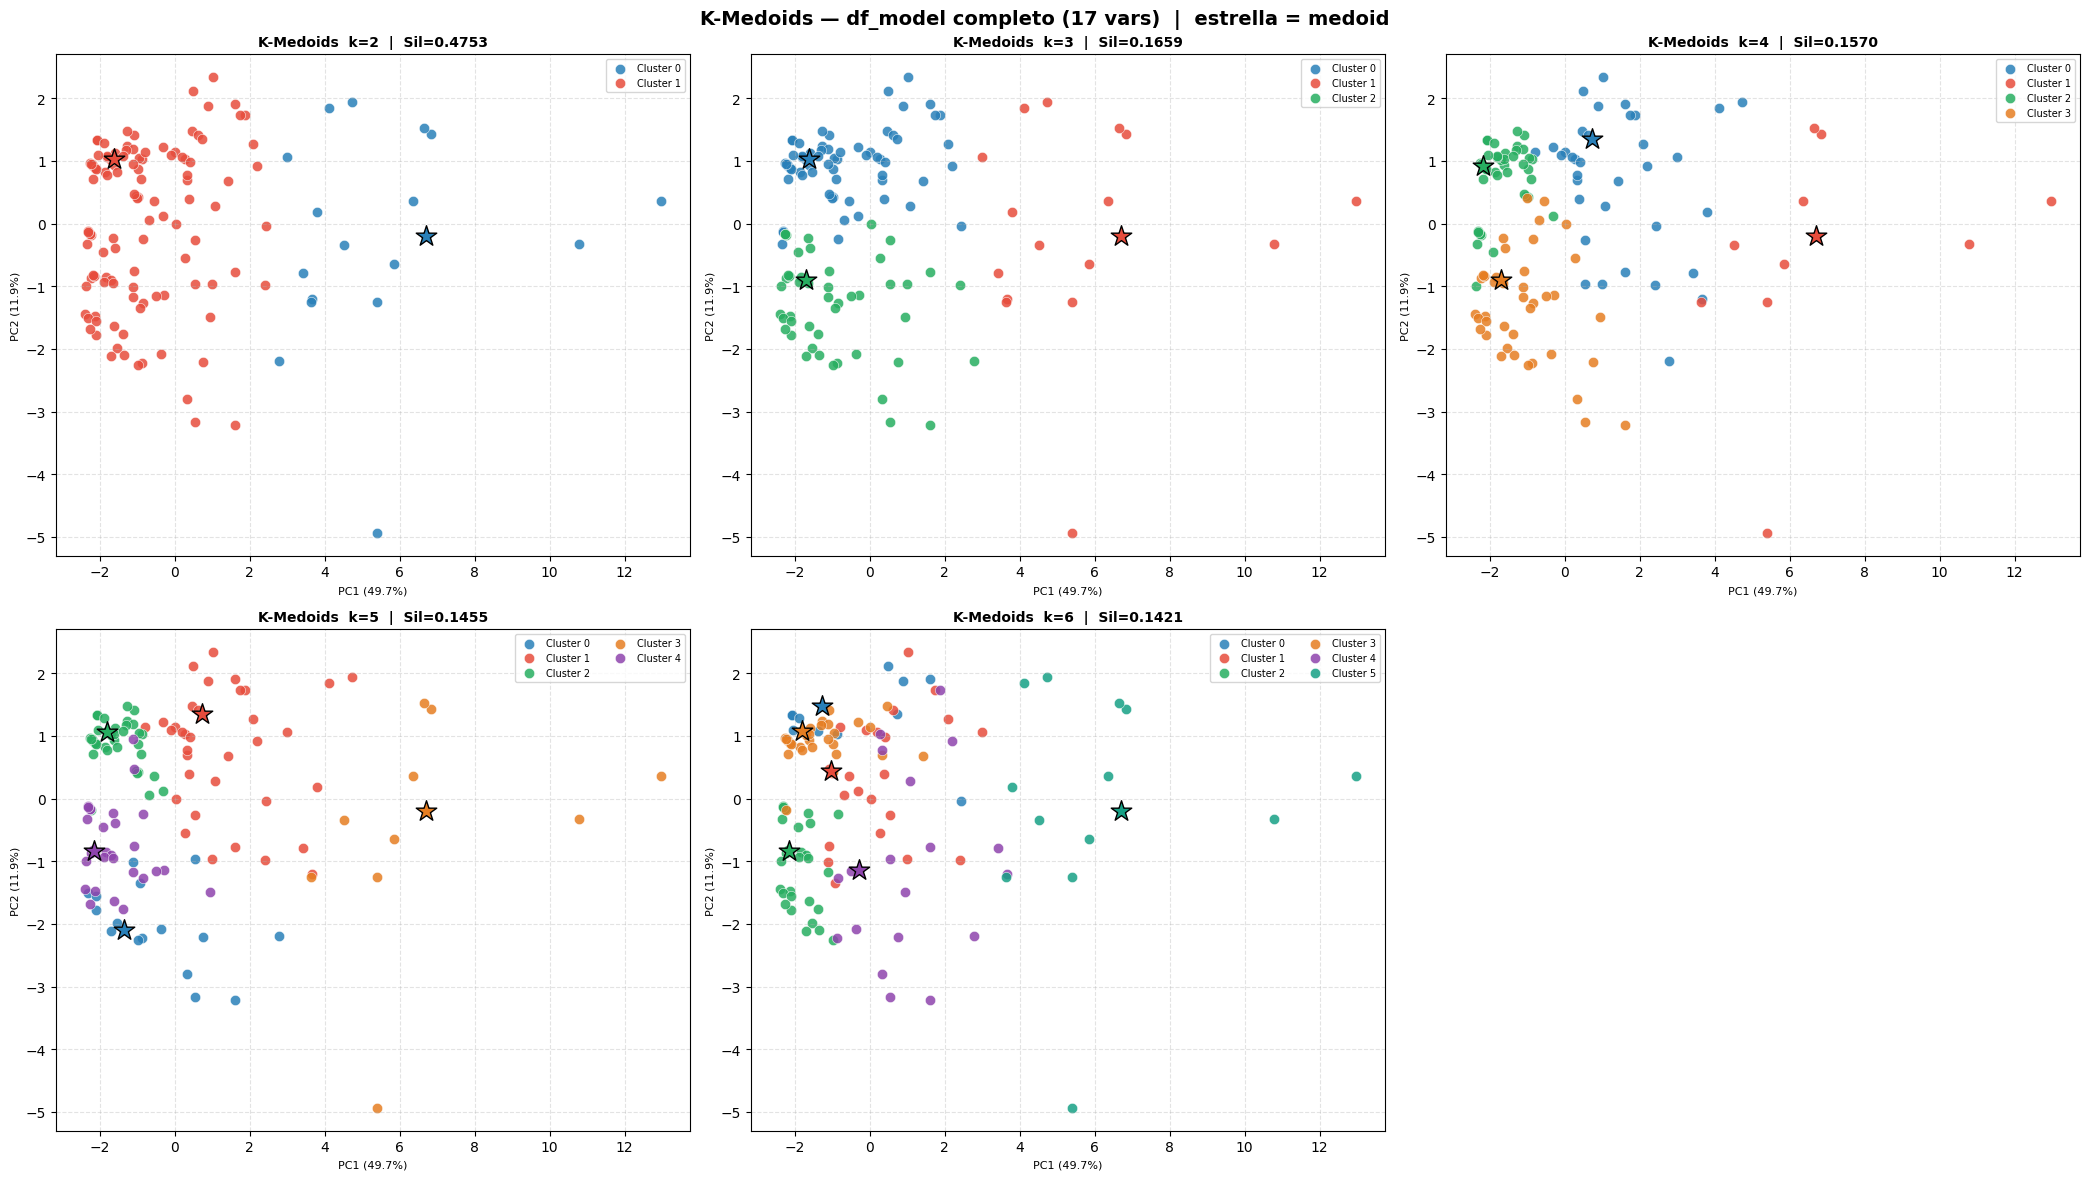


K-MEANS — df_model (17 vars)


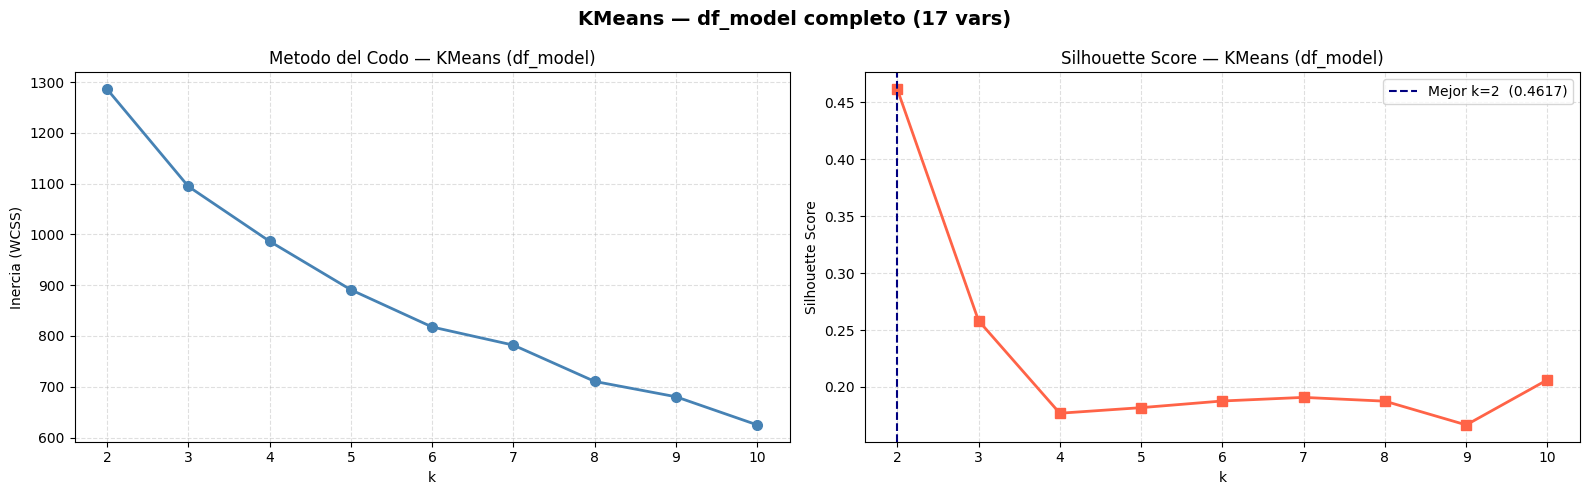


K-MEANS scatter — df_model (17 vars)
  k    Silhouette  Distribucion
-------------------------------------------------------
  2        0.4617  {np.int32(0): np.int64(115), np.int32(1): np.int64(20)}
  3        0.2583  {np.int32(0): np.int64(84), np.int32(1): np.int64(11), np.int32(2): np.int64(40)}
  4        0.1769  {np.int32(0): np.int64(53), np.int32(1): np.int64(11), np.int32(2): np.int64(35), np.int32(3): np.int64(36)}
  5        0.1818  {np.int32(0): np.int64(51), np.int32(1): np.int64(35), np.int32(2): np.int64(30), np.int32(3): np.int64(2), np.int32(4): np.int64(17)}
  6        0.1877  {np.int32(0): np.int64(31), np.int32(1): np.int64(50), np.int32(2): np.int64(2), np.int32(3): np.int64(10), np.int32(4): np.int64(33), np.int32(5): np.int64(9)}


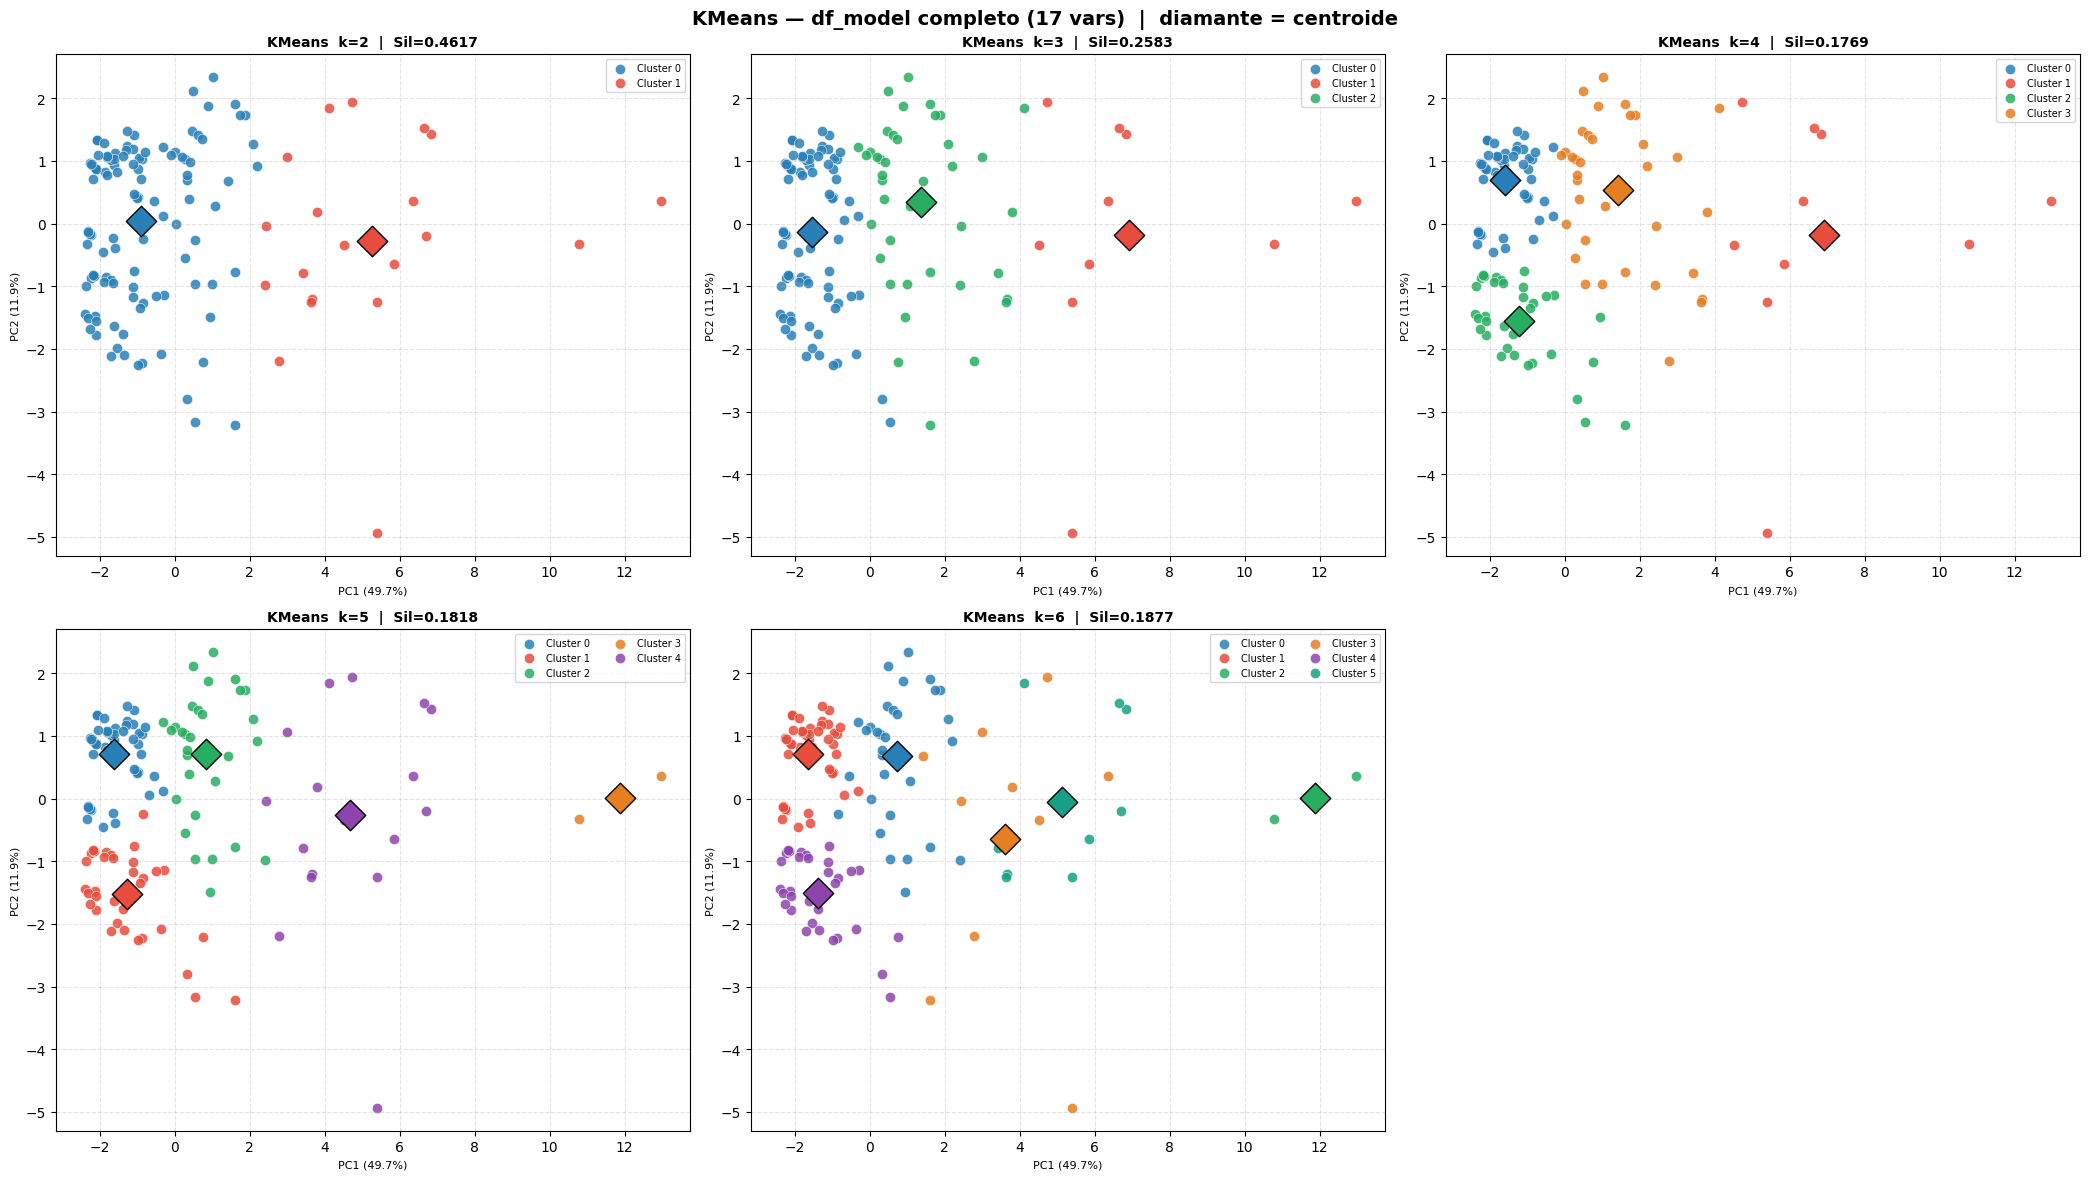


COMPARATIVA  KMeans vs KMedoids  —  df_model (17 vars)
  k    Sil KMeans    Sil KMedoids    Diferencia
----------------------------------------------
  2        0.4617          0.4753       +0.0136 <- KMedoids
  3        0.2583          0.1659       -0.0924 <- KMeans
  4        0.1769          0.1570       -0.0199 <- KMeans
  5        0.1818          0.1455       -0.0363 <- KMeans
  6        0.1877          0.1421       -0.0455 <- KMeans

KMedoids — describe por cluster (valores originales df_clientes)
  KMedoids  k=2  
───────────────────────────────────────────────────────
    Cluster 0  (n=18  A=5 B=12 C=1)
       Vol_Total  Vol_Imp  Vol_Exp  Num_Puertos  Prom_Mov_Año  Prom_2024  Prom_2025  Prom_2026  Churn
count       18.0     18.0     18.0         18.0          18.0       18.0       18.0       18.0   18.0
mean       792.7    433.3    359.4          7.0         182.8       21.6       19.2       23.2    0.2
std       1483.5    816.2    721.3          4.0         298.7       34.7   

In [25]:
# ============================================================
# Comparacion KMedoids (k=2,3,4,5,6) y KMeans — df_model completo (17 vars)
# ============================================================
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

X_full = df_model.values   # 17 variables escaladas

def kmedoids(X, k, random_state=42, max_iter=300):
    rng  = np.random.default_rng(random_state)
    X    = np.array(X)
    D    = cdist(X, X, metric="euclidean")
    midx = rng.choice(len(X), k, replace=False)
    for _ in range(max_iter):
        labels = np.argmin(D[:, midx], axis=1)
        new_m  = midx.copy()
        for c in range(k):
            ic = np.where(labels == c)[0]
            if len(ic) == 0: continue
            new_m[c] = ic[np.argmin(D[np.ix_(ic, ic)].sum(axis=1))]
        if np.array_equal(np.sort(new_m), np.sort(midx)): break
        midx = new_m
    return np.argmin(D[:, midx], axis=1), midx

# PCA 2D compartida para todos los scatter
pca2   = PCA(n_components=2, random_state=42)
coords = pca2.fit_transform(X_full)
ev     = pca2.explained_variance_ratio_

palettes = {
    2: ["#2980b9","#e74c3c"],
    3: ["#2980b9","#e74c3c","#27ae60"],
    4: ["#2980b9","#e74c3c","#27ae60","#e67e22"],
    5: ["#2980b9","#e74c3c","#27ae60","#e67e22","#8e44ad"],
    6: ["#2980b9","#e74c3c","#27ae60","#e67e22","#8e44ad","#16a085"],
}

K_list = [2, 3, 4, 5, 6]

# ── 1. K-Medoids k=2..6 ───────────────────────────────────────
print("K-MEDOIDS — df_model (17 vars)")
print(f"{'k':>3}  {'Silhouette':>12}  Distribucion")
print("-" * 55)

fig_km, axes_km = plt.subplots(2, 3, figsize=(21, 12))
axes_flat = axes_km.flatten()

kmed_results = {}
for i, k in enumerate(K_list):
    labels, midx = kmedoids(X_full, k, random_state=42)
    sil  = silhouette_score(X_full, labels)
    dist = dict(zip(*np.unique(labels, return_counts=True)))
    kmed_results[k] = (labels, midx, sil)
    print(f"{k:>3}  {sil:>12.4f}  {dict(sorted(dist.items()))}")

    ax  = axes_flat[i]
    pal = palettes[k]
    for c in range(k):
        idx = np.where(labels == c)[0]
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   color=pal[c], label=f"Cluster {c}",
                   alpha=0.85, s=55, edgecolors="white", linewidths=0.4)
    for m in midx:
        ax.scatter(coords[m, 0], coords[m, 1],
                   color=pal[labels[m]], s=240, marker="*",
                   edgecolors="black", linewidths=1, zorder=6)
    ax.set_title(f"K-Medoids  k={k}  |  Sil={sil:.4f}", fontsize=10, fontweight="bold")
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)", fontsize=8)
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)", fontsize=8)
    ax.legend(fontsize=7, ncol=2 if k > 4 else 1)
    ax.grid(True, linestyle="--", alpha=0.35)

# Ocultar el subplot sobrante (posicion 5)
axes_flat[5].axis("off")

fig_km.suptitle("K-Medoids — df_model completo (17 vars)  |  estrella = medoid",
                fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("kmedoids_k2_a_k6.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2. KMeans — Codo + Silhouette ─────────────────────────────
print()
print("K-MEANS — df_model (17 vars)")
K_range  = range(2, 11)
inertias = []
sil_km   = []
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_full)
    inertias.append(km.inertia_)
    sil_km.append(silhouette_score(X_full, lbl))

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))

axes2[0].plot(K_range, inertias, "o-", color="steelblue", linewidth=2, markersize=7)
axes2[0].set_title("Metodo del Codo — KMeans (df_model)")
axes2[0].set_xlabel("k"); axes2[0].set_ylabel("Inercia (WCSS)")
axes2[0].set_xticks(list(K_range))
axes2[0].grid(True, linestyle="--", alpha=0.4)

best_k = list(K_range)[sil_km.index(max(sil_km))]
axes2[1].plot(K_range, sil_km, "s-", color="tomato", linewidth=2, markersize=7)
axes2[1].axvline(best_k, color="navy", linestyle="--", linewidth=1.5,
                 label=f"Mejor k={best_k}  ({max(sil_km):.4f})")
axes2[1].set_title("Silhouette Score — KMeans (df_model)")
axes2[1].set_xlabel("k"); axes2[1].set_ylabel("Silhouette Score")
axes2[1].set_xticks(list(K_range))
axes2[1].legend(); axes2[1].grid(True, linestyle="--", alpha=0.4)

fig2.suptitle("KMeans — df_model completo (17 vars)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("kmeans_codo_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 2b. KMeans scatter k=2..6 ────────────────────────────────
print()
print("K-MEANS scatter — df_model (17 vars)")
print(f"{'k':>3}  {'Silhouette':>12}  Distribucion")
print("-" * 55)

fig_km2, axes_km2 = plt.subplots(2, 3, figsize=(21, 12))
axes_flat2 = axes_km2.flatten()

km_results = {}
for i, k in enumerate(K_list):
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_full)
    sil    = silhouette_score(X_full, labels)
    dist   = dict(zip(*np.unique(labels, return_counts=True)))
    km_results[k] = (labels, sil)
    print(f"{k:>3}  {sil:>12.4f}  {dict(sorted(dist.items()))}")

    ax  = axes_flat2[i]
    pal = palettes[k]
    for c in range(k):
        idx = np.where(labels == c)[0]
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   color=pal[c], label=f"Cluster {c}",
                   alpha=0.85, s=55, edgecolors="white", linewidths=0.4)
    # Centroides proyectados al espacio PCA
    centroids_pca = pca2.transform(km.cluster_centers_)
    for c, cp in enumerate(centroids_pca):
        ax.scatter(cp[0], cp[1],
                   color=pal[c], s=240, marker="D",
                   edgecolors="black", linewidths=1, zorder=6)
    ax.set_title(f"KMeans  k={k}  |  Sil={sil:.4f}", fontsize=10, fontweight="bold")
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)", fontsize=8)
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)", fontsize=8)
    ax.legend(fontsize=7, ncol=2 if k > 4 else 1)
    ax.grid(True, linestyle="--", alpha=0.35)

axes_flat2[5].axis("off")

fig_km2.suptitle("KMeans — df_model completo (17 vars)  |  diamante = centroide",
                 fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("kmeans_k2_a_k6.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 3. Tabla comparativa KMeans vs KMedoids ───────────────────
print()
print("COMPARATIVA  KMeans vs KMedoids  —  df_model (17 vars)")
print(f"{'k':>3}  {'Sil KMeans':>12}  {'Sil KMedoids':>14}  {'Diferencia':>12}")
print("-" * 46)
for k in K_list:
    skm   = km_results[k][1]
    skmed = kmed_results[k][2]
    diff  = skmed - skm
    mark  = " <- KMedoids" if diff > 0 else " <- KMeans"
    print(f"{k:>3}  {skm:>12.4f}  {skmed:>14.4f}  {diff:>+12.4f}{mark}")

# ── 4. Describe por cluster — KMedoids y KMeans ──────────────
desc_cols = ['Vol_Total', 'Vol_Imp', 'Vol_Exp', 'Num_Puertos',
             'Prom_Mov_Año', 'Prom_2024', 'Prom_2025', 'Prom_2026', 'Churn']

for algo, results in [("KMedoids", kmed_results), ("KMeans", km_results)]:
    print()
    print("=" * 70)
    print(f"{algo} — describe por cluster (valores originales df_clientes)")
    print("=" * 70)
    for k in K_list:
        labels = results[k][0]
        df_clientes[f"_lbl_{algo}_{k}"] = labels
        print(f"  {algo}  k={k}  " + chr(10) + "─"*55)
        grp = df_clientes.groupby(f"_lbl_{algo}_{k}")[desc_cols]
        # mean + std + count por cluster
        stats = grp.agg(["mean", "std", "count"]).round(1)
        # Aplanar multiindex y mostrar separado por cluster
        for cl in sorted(labels.tolist().__class__(set(labels))):
            sub = df_clientes[df_clientes[f"_lbl_{algo}_{k}"] == cl]
            tipo_d = sub["Tipo_Cliente"].value_counts().to_dict()
            print(f"    Cluster {cl}  (n={len(sub)}"
                  f"  A={tipo_d.get('A',0)} B={tipo_d.get('B',0)} C={tipo_d.get('C',0)})")
            print(sub[desc_cols].describe().round(1).to_string(max_rows=8))
            print()
        # Limpiar columna temporal
        df_clientes.drop(columns=[f"_lbl_{algo}_{k}"], inplace=True)


Varianza acumulada por componente:
  PC 1:  49.67%
  PC 2:  61.58%
  PC 3:  70.71%
  PC 4:  77.82%
  PC 5:  82.87%  <- 80%
  PC 6:  86.65%
  PC 7:  90.17%  <- 90%
  PC 8:  92.79%
  PC 9:  95.01%
  PC10:  96.60%

Componentes seleccionados para DBSCAN: 5 (>= 80% varianza)
Shape X_pca: (135, 5)

Grid Search DBSCAN sobre PCA (5 componentes):
    eps   min_s   n_cl   ruido%   silhouette
  ------------------------------------------
    0.3       3      2    94.1%       0.8516
    0.3       5      0   100.0%          N/A
    0.3       7      0   100.0%          N/A
    0.3      10      0   100.0%          N/A
    0.3      15      0   100.0%          N/A
    0.5       3      4    85.2%       0.6191
    0.5       5      2    90.4%       0.6605
    0.5       7      0   100.0%          N/A
    0.5      10      0   100.0%          N/A
    0.5      15      0   100.0%          N/A
    0.8       3      8    48.9%       0.3324
    0.8       5      3    71.9%       0.4643
    0.8       7      2    80.0

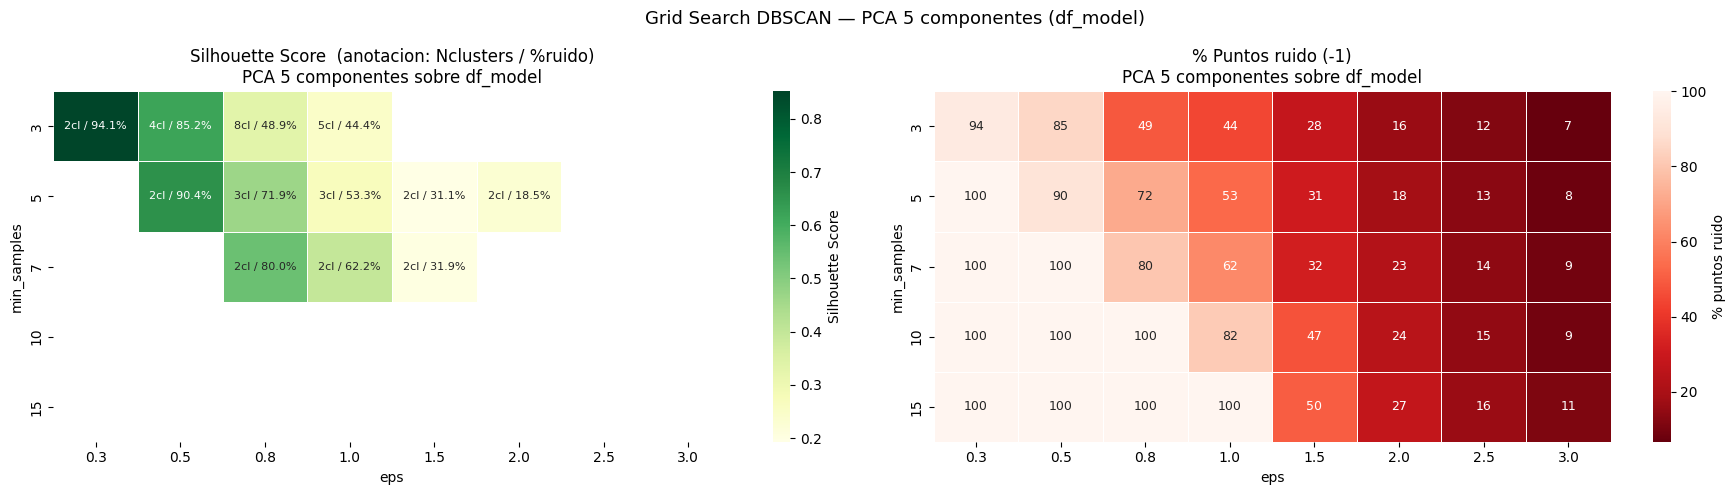

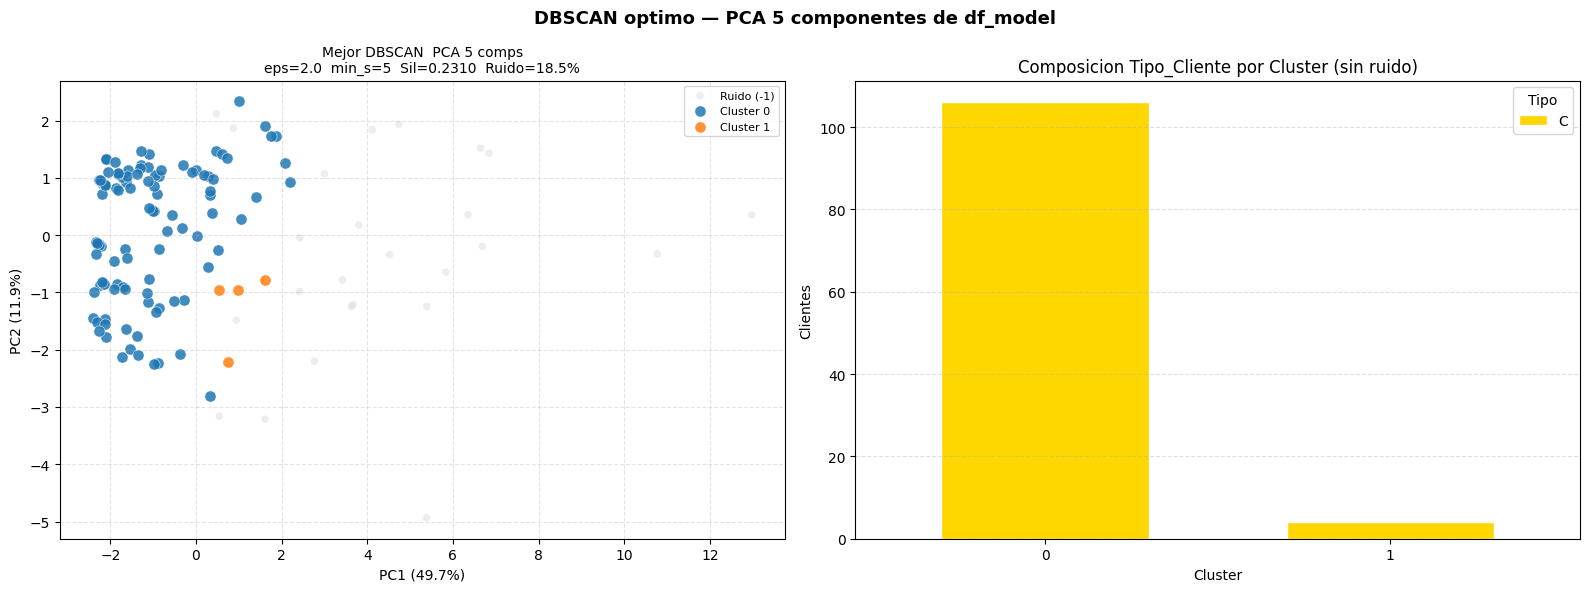

DBSCAN directo (17 vars) vs DBSCAN + PCA reducida
  Dimension original : 17 variables
  Dimension reducida : 5 componentes PCA (82.9% varianza)
  Mejor PCA+DBSCAN   : eps=2.0  ms=5  Sil=0.2310  Ruido=18.5%
  DBSCAN directo     : sin configuracion valida (ruido > 30% en todo el grid)


In [26]:
# ============================================================
# DBSCAN sobre componentes PCA de df_model
#   Estrategia: reducir dimensionalidad antes de DBSCAN para
#   mitigar la maldicion de la dimensionalidad (17 vars -> n_PCA)
# ============================================================
import itertools
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

X_full = df_model.values   # 17 variables escaladas

# ── 1. PCA: componentes que explican >= 80% de varianza ───────
pca_full = PCA(random_state=42).fit(X_full)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
n_80     = int(np.searchsorted(cum_var, 0.80)) + 1
n_90     = int(np.searchsorted(cum_var, 0.90)) + 1

print("Varianza acumulada por componente:")
for i, cv in enumerate(cum_var[:10], 1):
    mark = ""
    if i == n_80: mark = "  <- 80%"
    if i == n_90: mark = "  <- 90%"
    print(f"  PC{i:2d}: {cv*100:6.2f}%{mark}")

print(f"\nComponentes seleccionados para DBSCAN: {n_80} (>= 80% varianza)")

# Proyeccion PCA reducida
pca_n = PCA(n_components=n_80, random_state=42)
X_pca = pca_n.fit_transform(X_full)

# PCA 2D solo para visualizacion
pca_2d    = PCA(n_components=2, random_state=42)
coords_2d = pca_2d.fit_transform(X_full)
ev_2d     = pca_2d.explained_variance_ratio_

print(f"Shape X_pca: {X_pca.shape}")

# ── 2. Grid Search DBSCAN sobre X_pca ─────────────────────────
eps_vals = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 2.5, 3.0]
ms_vals  = [3, 5, 7, 10, 15]

results = []
for eps, ms in itertools.product(eps_vals, ms_vals):
    lbl       = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_pca)
    n_cl      = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise   = int((lbl == -1).sum())
    noise_pct = round(n_noise / len(lbl) * 100, 1)
    mask      = lbl != -1
    sil = (silhouette_score(X_pca[mask], lbl[mask])
           if n_cl >= 2 and mask.sum() > n_cl else float("nan"))
    results.append(dict(eps=eps, min_samples=ms, n_clusters=n_cl,
                        n_noise=n_noise, noise_pct=noise_pct,
                        silhouette=sil, labels=lbl))

df_gs = pd.DataFrame(results)

# ── 3. Tabla resumen ───────────────────────────────────────────
print(f"\nGrid Search DBSCAN sobre PCA ({n_80} componentes):")
print(f"  {'eps':>5}  {'min_s':>6}  {'n_cl':>5}  {'ruido%':>7}  {'silhouette':>11}")
print("  " + "-"*42)
for _, r in df_gs.iterrows():
    sstr = f"{r.silhouette:.4f}" if not pd.isna(r.silhouette) else "    N/A"
    print(f"  {r.eps:>5.1f}  {int(r.min_samples):>6}  {int(r.n_clusters):>5}  "
          f"{r.noise_pct:>6.1f}%  {sstr:>11}")

# ── 4. Mejor configuracion ────────────────────────────────────
valid = df_gs[(df_gs.n_clusters >= 2) &
              (df_gs.noise_pct  <= 30) &
              df_gs.silhouette.notna()]

if len(valid) > 0:
    best = valid.loc[valid.silhouette.idxmax()]
    print(f"\nMejor configuracion: eps={best.eps}  min_samples={int(best.min_samples)}")
    print(f"  Clusters: {int(best.n_clusters)}  |  Ruido: {int(best.n_noise)} ({best.noise_pct}%)")
    print(f"  Silhouette: {best.silhouette:.4f}")
else:
    best = None
    print("\nNo se encontro configuracion valida (>= 2 clusters, ruido <= 30%).")

# ── 5. Heatmaps grid search ───────────────────────────────────
pivot_sil   = df_gs.pivot(index="min_samples", columns="eps", values="silhouette")
pivot_noise = df_gs.pivot(index="min_samples", columns="eps", values="noise_pct")
pivot_ncl   = df_gs.pivot(index="min_samples", columns="eps", values="n_clusters")
annot_lbl   = pivot_ncl.astype(int).astype(str) + "cl / " + pivot_noise.astype(str) + "%"

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.heatmap(pivot_sil, ax=axes[0], annot=annot_lbl, fmt="",
            cmap="YlGn", linewidths=0.5, linecolor="white",
            annot_kws={"size": 8},
            cbar_kws={"label": "Silhouette Score"})
axes[0].set_title(f"Silhouette Score  (anotacion: Nclusters / %ruido)\nPCA {n_80} componentes sobre df_model")
axes[0].set_xlabel("eps"); axes[0].set_ylabel("min_samples")

sns.heatmap(pivot_noise, ax=axes[1], annot=True, fmt=".0f",
            cmap="Reds_r", linewidths=0.5, linecolor="white",
            annot_kws={"size": 9},
            cbar_kws={"label": "% puntos ruido"})
axes[1].set_title(f"% Puntos ruido (-1)\nPCA {n_80} componentes sobre df_model")
axes[1].set_xlabel("eps"); axes[1].set_ylabel("min_samples")

plt.suptitle(f"Grid Search DBSCAN — PCA {n_80} componentes (df_model)", fontsize=13)
plt.tight_layout()
plt.savefig("dbscan_pca_gridsearch.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6. Visualizacion mejor configuracion ─────────────────────
if best is not None:
    best_lbl = best.labels
    palette  = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for cl in sorted(set(best_lbl)):
        idx = np.where(best_lbl == cl)[0]
        col = "lightgray" if cl == -1 else palette[cl % len(palette)]
        lbl_str = "Ruido (-1)" if cl == -1 else f"Cluster {cl}"
        axes[0].scatter(coords_2d[idx, 0], coords_2d[idx, 1],
                        color=col, label=lbl_str,
                        alpha=0.4 if cl == -1 else 0.85,
                        s=30 if cl == -1 else 65,
                        edgecolors="none" if cl == -1 else "white",
                        linewidths=0.4)
    axes[0].set_title(f"Mejor DBSCAN  PCA {n_80} comps\n"
                      f"eps={best.eps}  min_s={int(best.min_samples)}  "
                      f"Sil={best.silhouette:.4f}  Ruido={best.noise_pct}%",
                      fontsize=10)
    axes[0].set_xlabel(f"PC1 ({ev_2d[0]*100:.1f}%)")
    axes[0].set_ylabel(f"PC2 ({ev_2d[1]*100:.1f}%)")
    axes[0].legend(fontsize=8); axes[0].grid(True, linestyle="--", alpha=0.35)

    df_clientes["Cluster_dbpca"] = best_lbl
    df_nn = df_clientes[df_clientes["Cluster_dbpca"] != -1]
    if len(df_nn) > 0:
        ct = pd.crosstab(df_nn["Cluster_dbpca"], df_nn["Tipo_Cliente"])
        ct.plot(kind="bar", ax=axes[1],
                color=["gold", "steelblue", "lightgray"],
                edgecolor="white", width=0.6)
        axes[1].set_title("Composicion Tipo_Cliente por Cluster (sin ruido)")
        axes[1].set_xlabel("Cluster"); axes[1].set_ylabel("Clientes")
        axes[1].tick_params(axis="x", rotation=0)
        axes[1].legend(title="Tipo")
        axes[1].grid(True, linestyle="--", alpha=0.4, axis="y")

    plt.suptitle(f"DBSCAN optimo — PCA {n_80} componentes de df_model",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("dbscan_pca_mejor.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── 7. Conclusion comparativa ─────────────────────────────────
print("=" * 60)
print("DBSCAN directo (17 vars) vs DBSCAN + PCA reducida")
print("=" * 60)
print(f"  Dimension original : 17 variables")
print(f"  Dimension reducida : {n_80} componentes PCA ({cum_var[n_80-1]*100:.1f}% varianza)")
if best is not None:
    print(f"  Mejor PCA+DBSCAN   : eps={best.eps}  ms={int(best.min_samples)}"
          f"  Sil={best.silhouette:.4f}  Ruido={best.noise_pct}%")
else:
    print("  Mejor PCA+DBSCAN   : sin configuracion valida encontrada")
print("  DBSCAN directo     : sin configuracion valida (ruido > 30% en todo el grid)")


# Busqueda de caracteristicas con el perfilamiento usando la data original

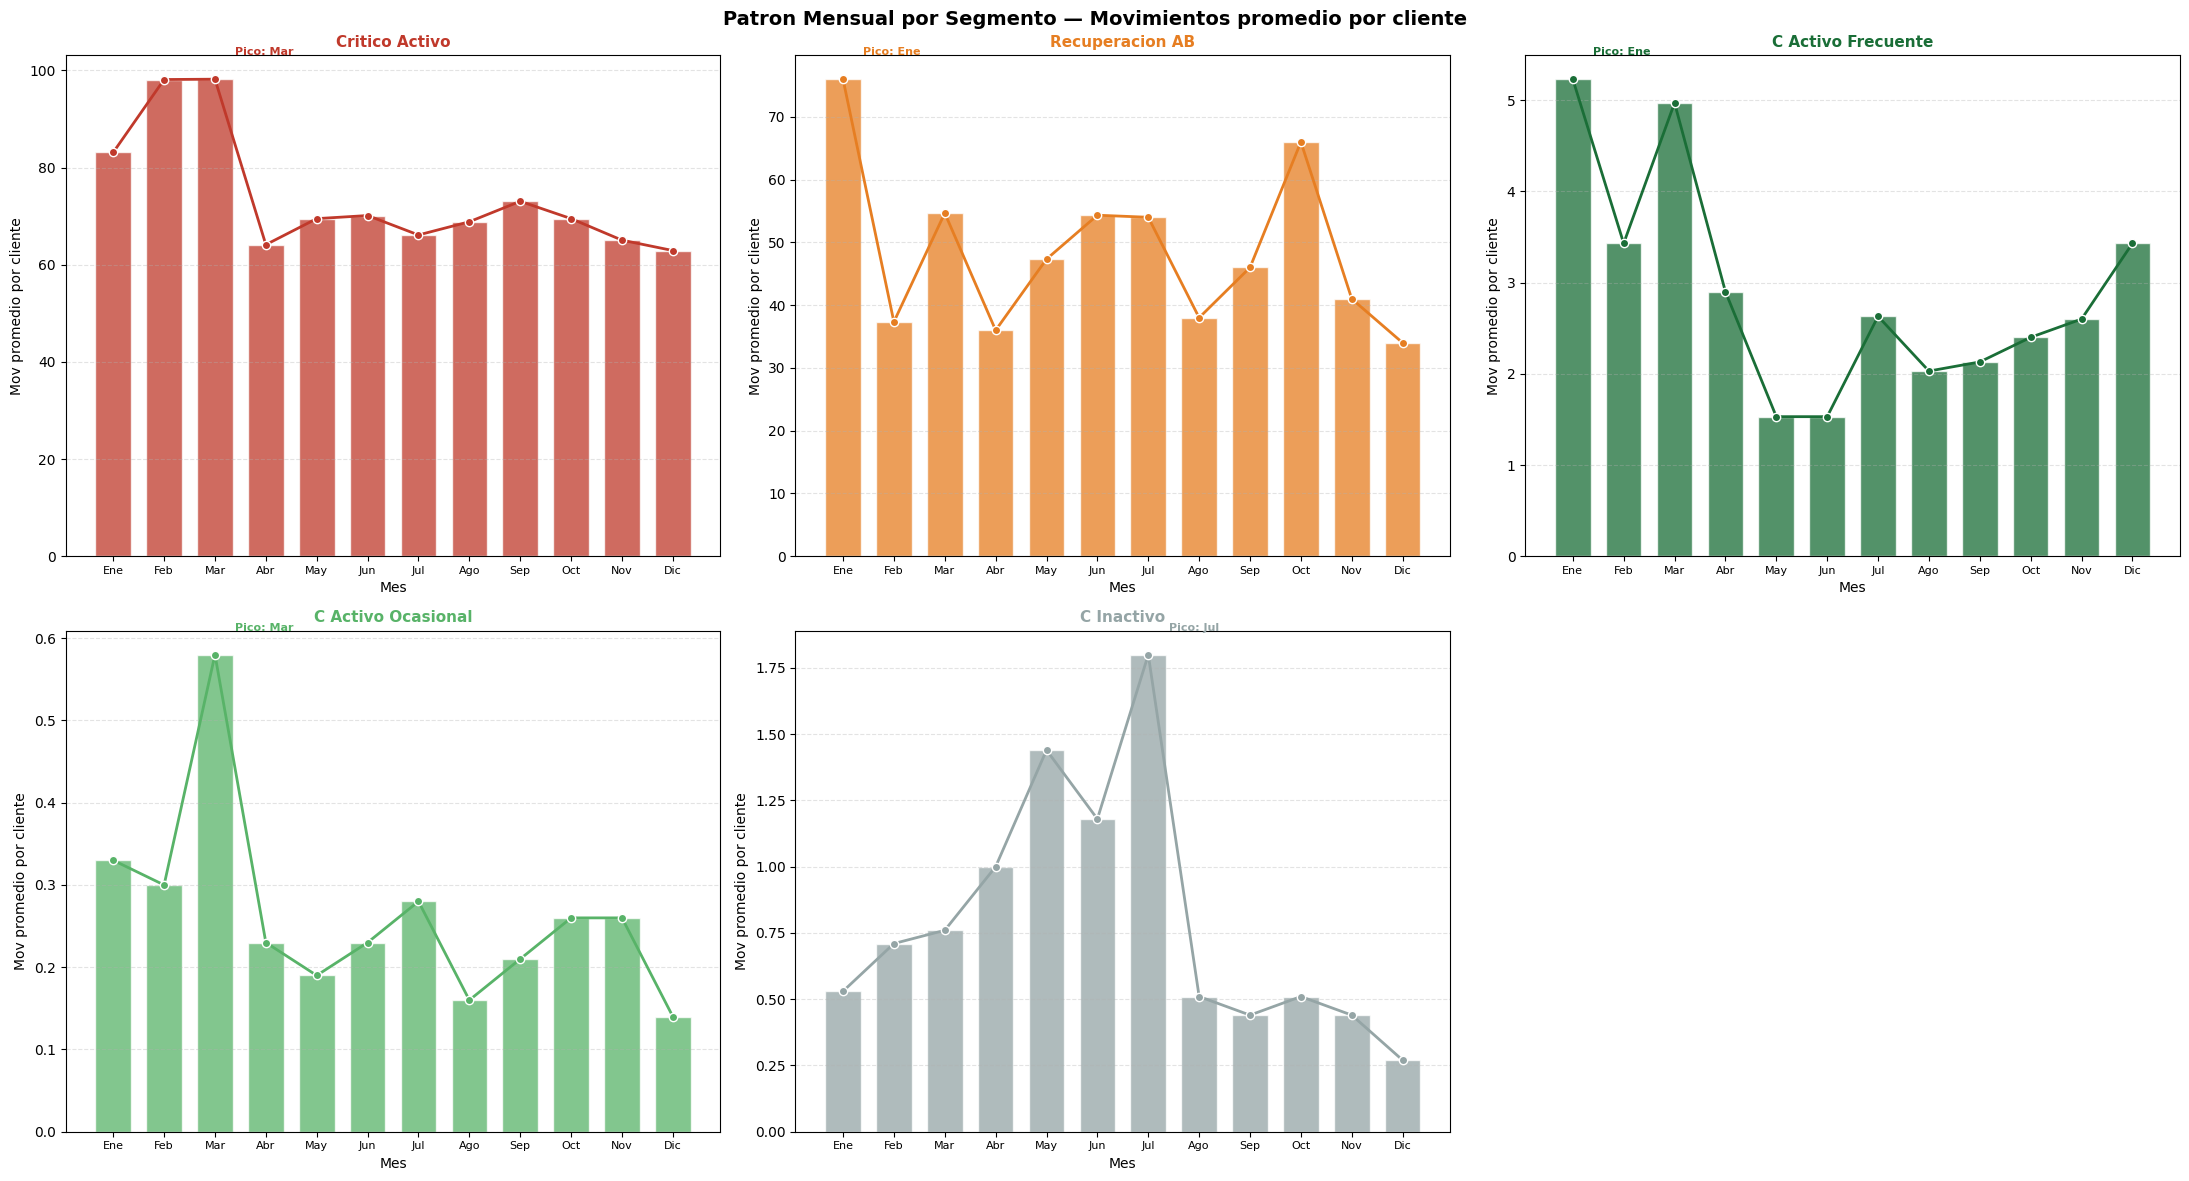

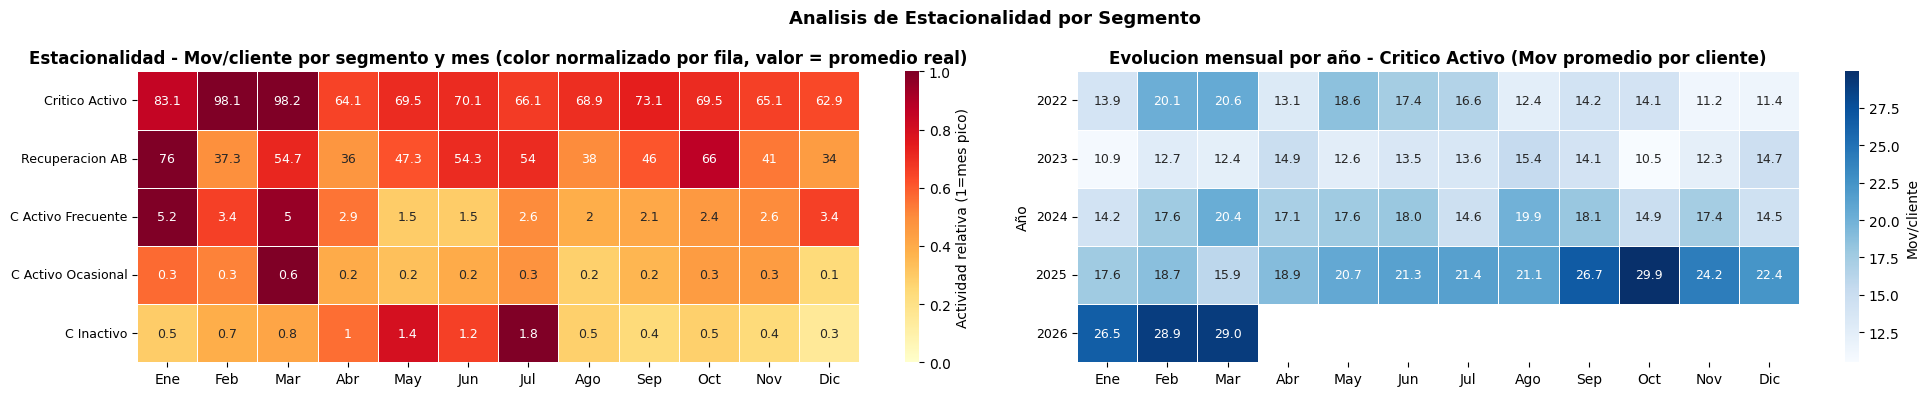

RESUMEN — Patron mensual por segmento
  Critico Activo           | pico: Mar  | bajo: Dic  | prom/mes:  74.07  | variacion:  35.28
  Recuperacion AB          | pico: Ene  | bajo: Dic  | prom/mes:  48.72  | variacion:  42.00
  C Activo Frecuente       | pico: Ene  | bajo: May  | prom/mes:   2.90  | variacion:   3.70
  C Activo Ocasional       | pico: Mar  | bajo: Dic  | prom/mes:   0.26  | variacion:   0.44
  C Inactivo               | pico: Jul  | bajo: Dic  | prom/mes:   0.80  | variacion:   1.53


In [27]:
# ============================================================
# Comportamiento mensual por segmento — Segmentacion Hibrida Final
#   Cruza transacciones (data) con Seg_Final (df_clientes)
#   para analizar estacionalidad y tendencia mensual por grupo
# ============================================================

SEG_ORDEN = ["Critico Activo", "Recuperacion AB",
             "C Activo Frecuente", "C Activo Ocasional", "C Inactivo"]

SEG_COLORS = {
    "Critico Activo":     "#c0392b",
    "Recuperacion AB":    "#e67e22",
    "C Activo Frecuente": "#1a6e37",
    "C Activo Ocasional": "#58b368",
    "C Inactivo":         "#95a5a6",
}

MESES = ["Ene","Feb","Mar","Abr","May","Jun",
         "Jul","Ago","Sep","Oct","Nov","Dic"]

# ── 1. Unir transacciones con segmento ───────────────────────
df_tx = data.copy()
df_tx["Mes"]  = df_tx["Fecha"].dt.month
df_tx["Año"]  = df_tx["Fecha"].dt.year
df_tx = df_tx.merge(df_clientes[["Cliente","Seg_Final"]], on="Cliente", how="left")
df_tx = df_tx[df_tx["Seg_Final"].notna()]

n_clientes_seg = df_clientes["Seg_Final"].value_counts()

# ── 2. Movimientos totales por segmento-mes (promedio por cliente) ──
mov_mes = (df_tx.groupby(["Seg_Final","Mes"])
               .size()
               .reset_index(name="Movimientos"))
mov_mes["N_clientes"] = mov_mes["Seg_Final"].map(n_clientes_seg)
mov_mes["Mov_per_cliente"] = (mov_mes["Movimientos"] / mov_mes["N_clientes"]).round(2)

# ── 3. Movimientos por segmento-año-mes ──────────────────────
mov_año_mes = (df_tx.groupby(["Seg_Final","Año","Mes"])
                    .size()
                    .reset_index(name="Movimientos"))
mov_año_mes["N_clientes"] = mov_año_mes["Seg_Final"].map(n_clientes_seg)
mov_año_mes["Mov_per_cliente"] = (mov_año_mes["Movimientos"] / mov_año_mes["N_clientes"]).round(2)

# ── 4. Figura principal: patron mensual agregado ──────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes_flat = axes.flatten()

for i, seg in enumerate(SEG_ORDEN):
    ax  = axes_flat[i]
    col = SEG_COLORS[seg]
    sub = mov_mes[mov_mes["Seg_Final"] == seg].set_index("Mes").reindex(range(1,13))

    ax.bar(range(1,13), sub["Mov_per_cliente"].fillna(0),
           color=col, alpha=0.75, edgecolor="white", width=0.7)
    ax.plot(range(1,13), sub["Mov_per_cliente"].fillna(0),
            "o-", color=col, linewidth=2, markersize=6, markeredgecolor="white")

    ax.set_title(f"{seg}", fontsize=11, fontweight="bold", color=col)
    ax.set_xlabel("Mes")
    ax.set_ylabel("Mov promedio por cliente")
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(MESES, fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.35, axis="y")

    # Mes pico
    if sub["Mov_per_cliente"].notna().any():
        mes_pico = int(sub["Mov_per_cliente"].idxmax())
        val_pico = sub["Mov_per_cliente"].max()
        ax.annotate(f"Pico: {MESES[mes_pico-1]}",
                    xy=(mes_pico, val_pico),
                    xytext=(mes_pico + 0.4, val_pico * 1.05),
                    fontsize=8, color=col, fontweight="bold")

axes_flat[5].axis("off")
fig.suptitle("Patron Mensual por Segmento — Movimientos promedio por cliente",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("comportamiento_mensual_segmentos.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5. Heatmap: segmento × mes (normalizado por fila) ────────
pivot_mes = mov_mes.pivot(index="Seg_Final", columns="Mes",
                          values="Mov_per_cliente").reindex(SEG_ORDEN)
pivot_mes.columns = MESES
pivot_norm = pivot_mes.div(pivot_mes.max(axis=1), axis=0).round(2)

fig2, axes2 = plt.subplots(1, 2, figsize=(20, 4))

sns.heatmap(pivot_norm, ax=axes2[0],
            annot=pivot_mes.round(1), fmt="g",
            cmap="YlOrRd", vmin=0, vmax=1,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 9},
            cbar_kws={"label": "Actividad relativa (1=mes pico)"})
axes2[0].set_title("Estacionalidad - Mov/cliente por segmento y mes (color normalizado por fila, valor = promedio real)", fontweight="bold")
axes2[0].set_ylabel("")
axes2[0].tick_params(axis="y", rotation=0, labelsize=9)

# ── 6. Heatmap: año × mes por segmento (Critico Activo como ejemplo estrategico) ──
años = sorted(df_tx["Año"].unique())
seg_foco = "Critico Activo"
sub_año = mov_año_mes[mov_año_mes["Seg_Final"] == seg_foco]
pivot_año = sub_año.pivot(index="Año", columns="Mes", values="Mov_per_cliente")
pivot_año.columns = [MESES[m-1] for m in pivot_año.columns]
pivot_año = pivot_año.reindex(años)

sns.heatmap(pivot_año, ax=axes2[1],
            annot=True, fmt=".1f",
            cmap="Blues", linewidths=0.5, linecolor="white",
            annot_kws={"size": 9},
            cbar_kws={"label": "Mov/cliente"})
axes2[1].set_title(f"Evolucion mensual por año - {seg_foco} (Mov promedio por cliente)", fontweight="bold")
axes2[1].set_ylabel("Año")
axes2[1].tick_params(axis="y", rotation=0, labelsize=9)

fig2.suptitle("Analisis de Estacionalidad por Segmento", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("estacionalidad_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 7. Resumen textual ────────────────────────────────────────
print("RESUMEN — Patron mensual por segmento")
print("=" * 65)
for seg in SEG_ORDEN:
    sub = mov_mes[mov_mes["Seg_Final"] == seg].set_index("Mes").reindex(range(1,13))
    if sub["Mov_per_cliente"].isna().all():
        continue
    mes_pico  = int(sub["Mov_per_cliente"].idxmax())
    mes_bajo  = int(sub["Mov_per_cliente"].idxmin())
    prom_anual = sub["Mov_per_cliente"].mean()
    variacion  = (sub["Mov_per_cliente"].max() - sub["Mov_per_cliente"].min())
    print(f"  {seg:<24} | pico: {MESES[mes_pico-1]:>3}  "
          f"| bajo: {MESES[mes_bajo-1]:>3}  "
          f"| prom/mes: {prom_anual:>6.2f}  "
          f"| variacion: {variacion:>6.2f}")


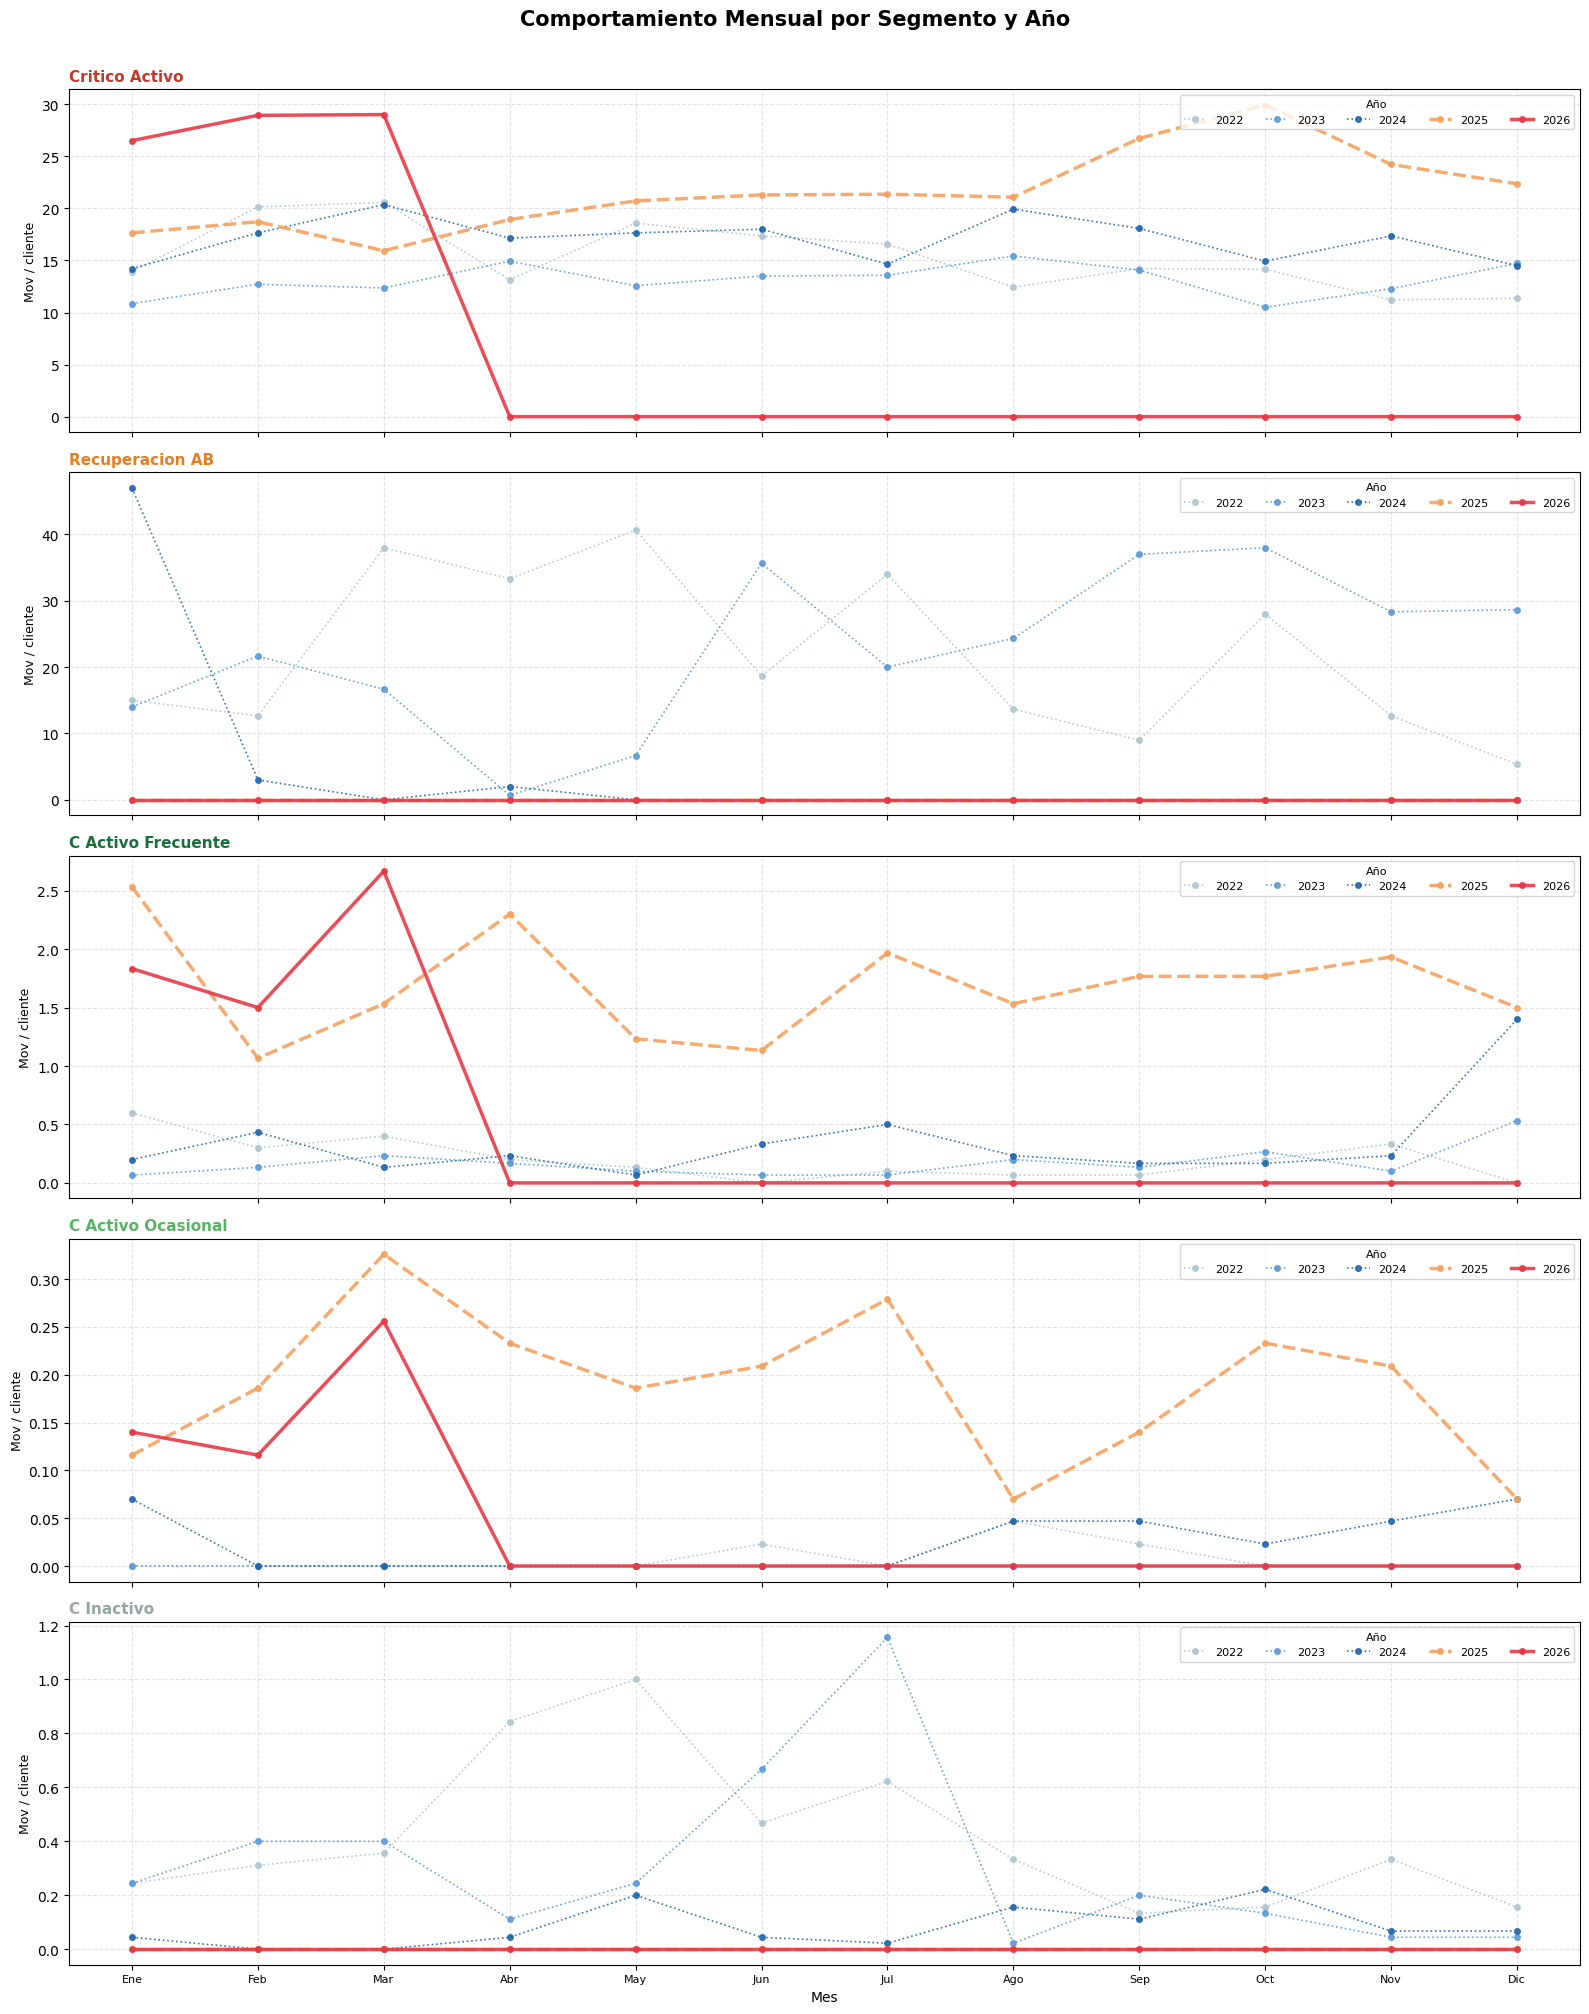

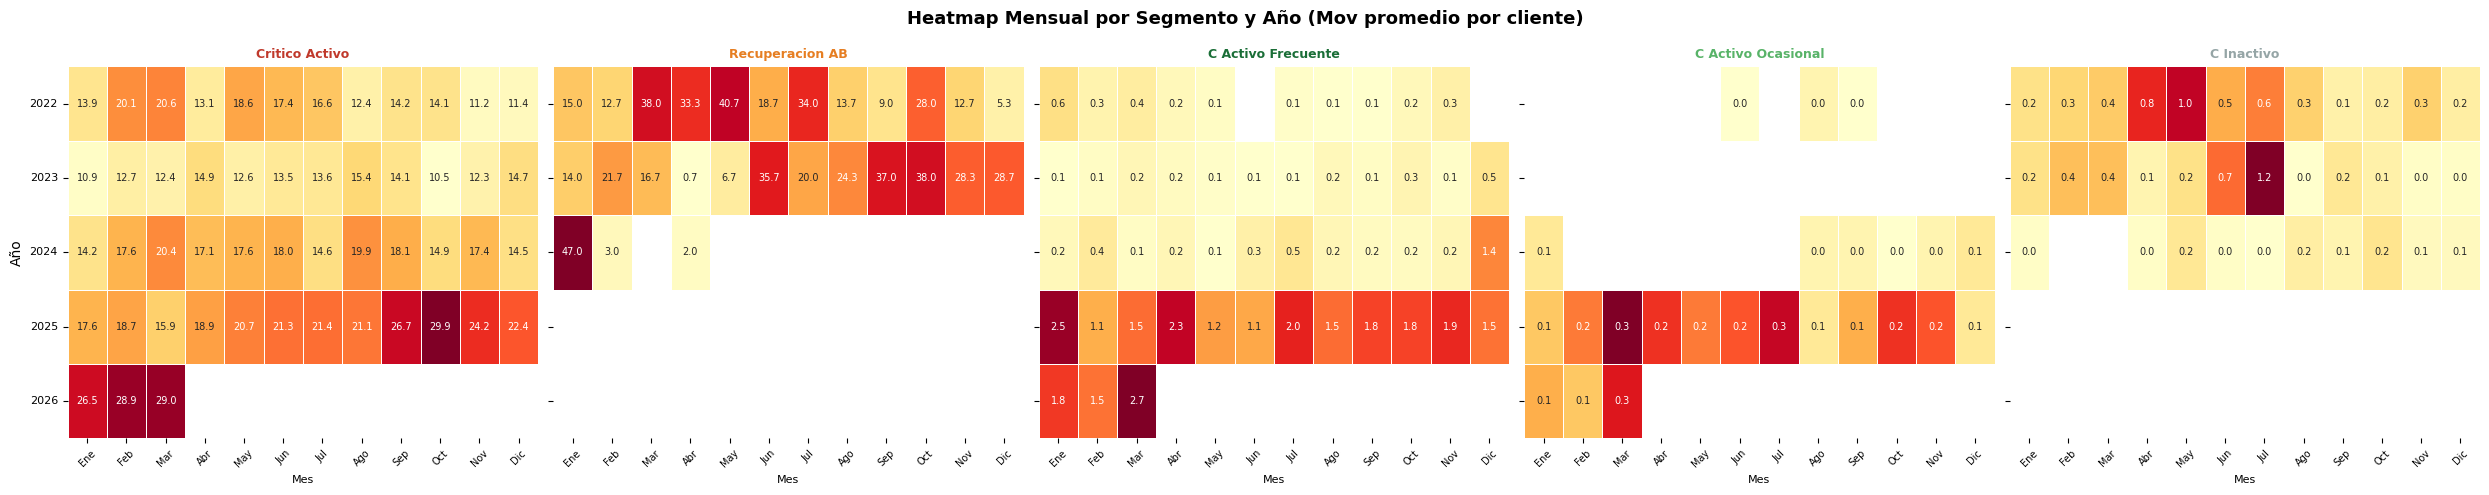

Graficos guardados.


In [28]:
# ============================================================
# Comportamiento mensual por segmento — desglosado por año
# ============================================================

SEG_ORDEN  = ["Critico Activo","Recuperacion AB",
              "C Activo Frecuente","C Activo Ocasional","C Inactivo"]
SEG_COLORS = {
    "Critico Activo":     "#c0392b",
    "Recuperacion AB":    "#e67e22",
    "C Activo Frecuente": "#1a6e37",
    "C Activo Ocasional": "#58b368",
    "C Inactivo":         "#95a5a6",
}
MESES = ["Ene","Feb","Mar","Abr","May","Jun",
         "Jul","Ago","Sep","Oct","Nov","Dic"]

# Reutilizar df_tx construido en celda anterior (o reconstruir si es necesario)
try:
    _ = df_tx
except NameError:
    df_tx = data.copy()
    df_tx["Mes"] = df_tx["Fecha"].dt.month
    df_tx["Año"] = df_tx["Fecha"].dt.year
    df_tx = df_tx.merge(df_clientes[["Cliente","Seg_Final"]], on="Cliente", how="left")
    df_tx = df_tx[df_tx["Seg_Final"].notna()]

n_clientes_seg = df_clientes["Seg_Final"].value_counts()
años = sorted(df_tx["Año"].unique())

# Paleta por año
year_palette = {
    yr: c for yr, c in zip(años,
        ["#aec6cf","#5b9bd5","#2166ac","#f4a261","#e63946"])
}

# Movimientos por segmento-año-mes / n_clientes del segmento
mov_aym = (df_tx.groupby(["Seg_Final","Año","Mes"])
                .size()
                .reset_index(name="Mov"))
mov_aym["Mov_pc"] = (mov_aym["Mov"] /
                     mov_aym["Seg_Final"].map(n_clientes_seg)).round(3)

# ── Grafico: una fila por segmento, una linea por año ─────────
fig, axes = plt.subplots(len(SEG_ORDEN), 1,
                         figsize=(16, 4 * len(SEG_ORDEN)),
                         sharex=True)

for ax, seg in zip(axes, SEG_ORDEN):
    sub_seg = mov_aym[mov_aym["Seg_Final"] == seg]
    base_col = SEG_COLORS[seg]

    for yr in años:
        sub_yr = (sub_seg[sub_seg["Año"] == yr]
                  .set_index("Mes")
                  .reindex(range(1, 13))["Mov_pc"])
        pal_yr = year_palette.get(yr, "#999999")
        lw = 2.5 if yr in (años[-1], años[-2]) else 1.2
        ls = "-" if yr == años[-1] else "--" if yr == años[-2] else ":"
        ax.plot(range(1, 13), sub_yr.fillna(0),
                marker="o", markersize=4,
                linewidth=lw, linestyle=ls,
                color=pal_yr, label=str(yr), alpha=0.9)

    ax.set_title(seg, fontsize=11, fontweight="bold",
                 color=base_col, loc="left", pad=6)
    ax.set_ylabel("Mov / cliente", fontsize=9)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MESES, fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(title="Año", fontsize=8, title_fontsize=8,
              loc="upper right", ncol=len(años))
    ax.set_xlim(0.5, 12.5)

axes[-1].set_xlabel("Mes", fontsize=10)
fig.suptitle("Comportamiento Mensual por Segmento y Año",
             fontsize=15, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig("mensual_por_año_segmento.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Heatmap: mes x año para cada segmento ─────────────────────
fig2, axes2 = plt.subplots(1, len(SEG_ORDEN),
                           figsize=(5 * len(SEG_ORDEN), 5),
                           sharey=True)

for ax, seg in zip(axes2, SEG_ORDEN):
    sub_seg = mov_aym[mov_aym["Seg_Final"] == seg]
    pivot   = (sub_seg.pivot(index="Año", columns="Mes", values="Mov_pc")
                      .reindex(años))
    pivot.columns = MESES

    sns.heatmap(pivot, ax=ax,
                annot=True, fmt=".1f",
                cmap="YlOrRd",
                linewidths=0.4, linecolor="white",
                annot_kws={"size": 7},
                cbar=False)
    ax.set_title(seg, fontsize=9, fontweight="bold",
                 color=SEG_COLORS[seg])
    ax.set_xlabel("Mes", fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)
    ax.set_ylabel("Año" if ax == axes2[0] else "")

fig2.suptitle("Heatmap Mensual por Segmento y Año (Mov promedio por cliente)",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap_mensual_año_segmento.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graficos guardados.")


Shape X_test: (135, 15)  (13 vars + Tipo_Cliente + Churn)
Silhouette Score k=4: 0.2321

Cross-tabulation: K-Medoids k=4 vs Nivel 1 (Tipo_Cliente x Churn)
Seg_N1_exp      C Activo  C Inactivo  Critico Activo  Recuperacion AB  All
Cluster_k4_exp                                                            
0                     22           9               1                0   32
1                      0           0              13                3   16
2                     33          32               0                0   65
3                     18           4               0                0   22
All                   73          45              14                3  135

Adjusted Rand Index (ARI): 0.1557
  1.0 = agrupacion identica  |  0.0 = aleatoria  |  <0 = peor que azar


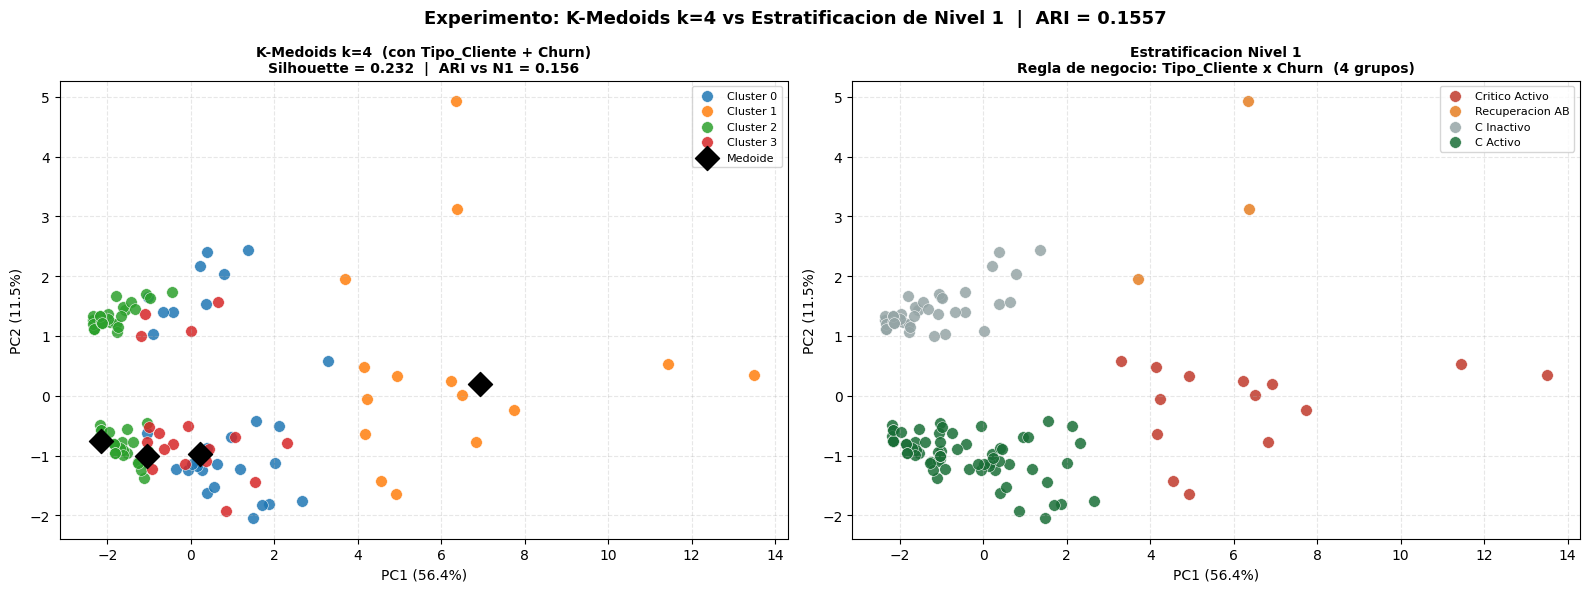


Composicion de cada cluster (Tipo_Cliente x Churn):
-----------------------------------------------------------------
  Cluster 0 (n=32): A=0 B=1 C=31 | Churn=28% | Vol_med=28
           Nivel1: {'C Activo': 22, 'C Inactivo': 9, 'Critico Activo': 1}
  Cluster 1 (n=16): A=5 B=11 C=0 | Churn=19% | Vol_med=436
           Nivel1: {'Critico Activo': 13, 'Recuperacion AB': 3}
  Cluster 2 (n=65): A=0 B=0 C=65 | Churn=49% | Vol_med=2
           Nivel1: {'C Activo': 33, 'C Inactivo': 32}
  Cluster 3 (n=22): A=0 B=0 C=22 | Churn=18% | Vol_med=7
           Nivel1: {'C Activo': 18, 'C Inactivo': 4}

CONCLUSION: ARI bajo -> K-Medoids encuentra una estructura diferente.
Las variables de comportamiento pesan mas que Tipo_Cliente/Churn.


In [29]:
# ============================================================
# Experimento: K-Medoids k=4 con Tipo_Cliente + Churn
# Hipotesis: si Tipo_Cliente y Churn dominan la estructura,
# el algoritmo deberia reencontrar la estratificacion de Nivel 1
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA

# ── Codificar Tipo_Cliente como ordinal (C=0, B=1, A=2) ──────
tipo_map  = {'C': 0, 'B': 1, 'A': 2}
tipo_enc  = df_clientes['Tipo_Cliente'].map(tipo_map).values.reshape(-1, 1)
churn_enc = df_clientes['Churn'].values.reshape(-1, 1)

tipo_scaled  = StandardScaler().fit_transform(tipo_enc)
churn_scaled = StandardScaler().fit_transform(churn_enc)

# X_test = X_cluster (13 vars comportamiento) + Tipo_Cliente + Churn
X_test = np.hstack([X_cluster.values, tipo_scaled, churn_scaled])
print(f'Shape X_test: {X_test.shape}  (13 vars + Tipo_Cliente + Churn)')

# ── K-Medoids k=4 ─────────────────────────────────────────────
labels_k4, medoids_k4 = kmedoids(X_test, k=4, random_state=42)
sil_k4 = silhouette_score(X_test, labels_k4)
print(f'Silhouette Score k=4: {sil_k4:.4f}')

# ── Estratificacion Nivel 1 (4 grupos, antes del sub-clustering) 
nivel1_map = {
    ('A', 0): 'Critico Activo',
    ('B', 0): 'Critico Activo',
    ('A', 1): 'Recuperacion AB',
    ('B', 1): 'Recuperacion AB',
    ('C', 1): 'C Inactivo',
    ('C', 0): 'C Activo',
}
df_clientes['Seg_N1_exp'] = df_clientes.apply(
    lambda r: nivel1_map[(r['Tipo_Cliente'], r['Churn'])], axis=1
)
df_clientes['Cluster_k4_exp'] = labels_k4

# ── Cross-tabulation ──────────────────────────────────────────
crosstab = pd.crosstab(
    df_clientes['Cluster_k4_exp'],
    df_clientes['Seg_N1_exp'],
    margins=True
)
print()
print('Cross-tabulation: K-Medoids k=4 vs Nivel 1 (Tipo_Cliente x Churn)')
print(crosstab.to_string())

ari = adjusted_rand_score(df_clientes['Seg_N1_exp'], df_clientes['Cluster_k4_exp'])
print()
print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print('  1.0 = agrupacion identica  |  0.0 = aleatoria  |  <0 = peor que azar')

# ── Visualizacion: scatter PCA lado a lado ────────────────────
n1_colors = {
    'Critico Activo':  '#c0392b',
    'Recuperacion AB': '#e67e22',
    'C Inactivo':      '#95a5a6',
    'C Activo':        '#1a6e37',
}
cl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

pca2   = PCA(n_components=2, random_state=42).fit(X_test)
coords = pca2.transform(X_test)
ev     = pca2.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: K-Medoids k=4
for cl in range(4):
    mask = labels_k4 == cl
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                    color=cl_colors[cl], label=f'Cluster {cl}',
                    alpha=0.85, s=70, edgecolors='white', linewidths=0.4)
for m in medoids_k4:
    axes[0].scatter(coords[m, 0], coords[m, 1],
                    color='black', marker='D', s=150, zorder=10,
                    label='Medoide' if m == medoids_k4[0] else '')
axes[0].set_title(
    f'K-Medoids k=4  (con Tipo_Cliente + Churn)' + chr(10) +
    f'Silhouette = {sil_k4:.3f}  |  ARI vs N1 = {ari:.3f}',
    fontsize=10, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.3)

# Panel derecho: Estratificacion Nivel 1
for seg, col in n1_colors.items():
    mask = df_clientes['Seg_N1_exp'] == seg
    axes[1].scatter(coords[mask, 0], coords[mask, 1],
                    color=col, label=seg, alpha=0.85, s=70,
                    edgecolors='white', linewidths=0.4)
axes[1].set_title(
    'Estratificacion Nivel 1' + chr(10) +
    'Regla de negocio: Tipo_Cliente x Churn  (4 grupos)',
    fontsize=10, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle(
    f'Experimento: K-Medoids k=4 vs Estratificacion de Nivel 1  |  ARI = {ari:.4f}',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmedoids_k4_vs_nivel1.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Composicion de cada cluster ───────────────────────────────
print()
print('Composicion de cada cluster (Tipo_Cliente x Churn):')
print('-' * 65)
for cl in range(4):
    sub   = df_clientes[df_clientes['Cluster_k4_exp'] == cl]
    tipos = sub['Tipo_Cliente'].value_counts().to_dict()
    churn_r = sub['Churn'].mean() * 100
    vol_med = sub['Vol_Total'].median()
    n1_dist = sub['Seg_N1_exp'].value_counts().to_dict()
    print(f'  Cluster {cl} (n={len(sub)}): '
          f'A={tipos.get("A",0)} B={tipos.get("B",0)} C={tipos.get("C",0)} | '
          f'Churn={churn_r:.0f}% | Vol_med={vol_med:,.0f}')
    print(f'           Nivel1: {n1_dist}')

# ── Interpretacion del ARI ────────────────────────────────────
print()
if ari > 0.75:
    print('CONCLUSION: ARI alto -> K-Medoids reencuentra la estratificacion.')
    print('Tipo_Cliente y Churn dominan la estructura del dataset.')
    print('Esto valida usarlos como reglas de negocio en Nivel 1.')
elif ari > 0.40:
    print('CONCLUSION: ARI moderado -> coincidencia parcial.')
    print('Las variables de comportamiento tambien influyen en la separacion.')
else:
    print('CONCLUSION: ARI bajo -> K-Medoids encuentra una estructura diferente.')
    print('Las variables de comportamiento pesan mas que Tipo_Cliente/Churn.')


Asignacion automatica Nivel 1:
  Cluster 0 -> Recuperacion AB       n= 32  AB%=3%  Churn=28%
  Cluster 1 -> Critico Activo        n= 16  AB%=100%  Churn=19%
  Cluster 2 -> C Inactivo            n= 65  AB%=0%  Churn=49%
  Cluster 3 -> C Activo              n= 22  AB%=0%  Churn=18%
Silhouette N2 (C Activo k=2): 0.2337

Distribucion final — Modelo ML puro (5 segmentos):
Seg_ML_Final
Critico Activo        16
Recuperacion AB       32
C Activo Frecuente     9
C Activo Ocasional    13
C Inactivo            65

Cross-tabulation: ML puro vs Modelo Hibrido original
Hibrido             C Activo Frecuente  C Activo Ocasional  C Inactivo  Critico Activo  Recuperacion AB
ML puro                                                                                                
C Activo Frecuente                   7                   0           2               0                0
C Activo Ocasional                   2                   9           2               0                0
C Inactivo            

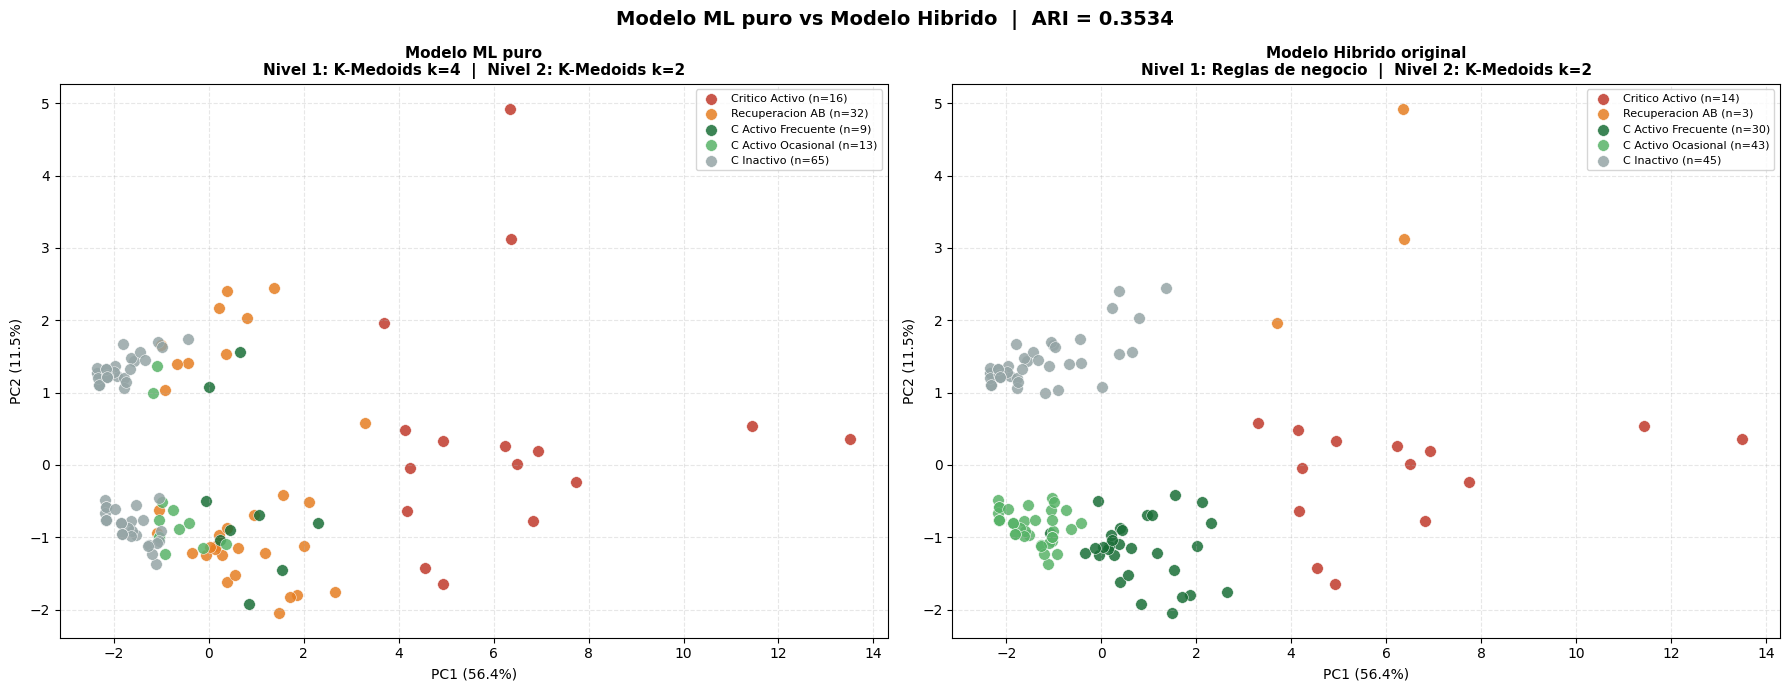


Perfil Modelo ML puro
--------------------------------------------------------------------
  [Critico Activo]  n=16  vol=89.2%
    Vol_Total med/mean :     436 /     881
    Churn              : 18.8%
    Tipo A/B/C         : A=5  B=11  C=0
    Prom 2025/2026     : 19.6 / 26.1

  [Recuperacion AB]  n=32  vol=7.9%
    Vol_Total med/mean :      28 /      39
    Churn              : 28.1%
    Tipo A/B/C         : A=0  B=1  C=31
    Prom 2025/2026     : 3.6 / 2.4

  [C Activo Frecuente]  n=9  vol=1.3%
    Vol_Total med/mean :      12 /      23
    Churn              : 22.2%
    Tipo A/B/C         : A=0  B=0  C=9
    Prom 2025/2026     : 1.5 / 1.3

  [C Activo Ocasional]  n=13  vol=0.5%
    Vol_Total med/mean :       3 /       6
    Churn              : 15.4%
    Tipo A/B/C         : A=0  B=0  C=13
    Prom 2025/2026     : 1.0 / 0.4

  [C Inactivo]  n=65  vol=1.2%
    Vol_Total med/mean :       2 /       3
    Churn              : 49.2%
    Tipo A/B/C         : A=0  B=0  C=65
    Prom 2025

In [30]:
# ============================================================
# Modelo ML puro: Nivel 1 K-Medoids k=4 + Nivel 2 K-Medoids k=2
# Nivel 1 usa variables de comportamiento + Tipo_Cliente + Churn
# Nivel 2 sub-segmenta el cluster 'C Activo' sin Churn
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

# ── Reconstruir X_test si no existe en memoria ────────────────
try:
    _ = X_test
except NameError:
    tipo_map_  = {'C': 0, 'B': 1, 'A': 2}
    tipo_enc_  = df_clientes['Tipo_Cliente'].map(tipo_map_).values.reshape(-1, 1)
    churn_enc_ = df_clientes['Churn'].values.reshape(-1, 1)
    tipo_scaled_  = StandardScaler().fit_transform(tipo_enc_)
    churn_scaled_ = StandardScaler().fit_transform(churn_enc_)
    X_test = np.hstack([X_cluster.values, tipo_scaled_, churn_scaled_])

# ── NIVEL 1: K-Medoids k=4 ────────────────────────────────────
labels_n1, medoids_n1 = kmedoids(X_test, k=4, random_state=42)
df_clientes['ML_N1'] = labels_n1

# Identificar automaticamente que cluster es que
# Regla: AB% alto + churn bajo -> Critico | AB% alto + churn alto -> Recuperacion
#        C% alto + churn alto -> Inactivo  | C% alto + churn bajo  -> C Activo
cprof = {}
for cl in range(4):
    sub = df_clientes[labels_n1 == cl]
    cprof[cl] = {
        'ab_pct':  sub['Tipo_Cliente'].isin(['A','B']).mean(),
        'churn_r': sub['Churn'].mean(),
        'n':       len(sub),
    }

label_map = {}
remaining = list(range(4))

# 1. Critico Activo: mayor AB%, menor churn
critico = max(remaining, key=lambda c: cprof[c]['ab_pct'] - cprof[c]['churn_r'])
label_map[critico] = 'Critico Activo'; remaining.remove(critico)

# 2. Recuperacion AB: mayor AB% entre los restantes
recup = max(remaining, key=lambda c: cprof[c]['ab_pct'])
label_map[recup] = 'Recuperacion AB'; remaining.remove(recup)

# 3. C Inactivo: mayor churn entre los dos restantes
inact = max(remaining, key=lambda c: cprof[c]['churn_r'])
label_map[inact] = 'C Inactivo'; remaining.remove(inact)

# 4. C Activo: el restante
cactivo_cl = remaining[0]
label_map[cactivo_cl] = 'C Activo'

print('Asignacion automatica Nivel 1:')
for cl, lbl in sorted(label_map.items()):
    p = cprof[cl]
    print(f'  Cluster {cl} -> {lbl:20}  n={p["n"]:3d}  AB%={p["ab_pct"]:.0%}  Churn={p["churn_r"]:.0%}')

# ── NIVEL 2: K-Medoids k=2 sobre cluster 'C Activo' ──────────
idx_ca_ml = df_clientes.index[labels_n1 == cactivo_cl].tolist()
X_ca_ml   = X_cluster.loc[idx_ca_ml].values

labels_n2, _ = kmedoids(X_ca_ml, k=2, random_state=42)
sil_n2 = silhouette_score(X_ca_ml, labels_n2)
print(f'Silhouette N2 (C Activo k=2): {sil_n2:.4f}')

# Sub-etiqueta por volumen mediano
vol_sub = {s: df_clientes.loc[[idx_ca_ml[i] for i,l in enumerate(labels_n2) if l==s],
                               'Vol_Total'].median() for s in [0, 1]}
alta_sub = max(vol_sub, key=vol_sub.get)
sub_lbl  = {alta_sub: 'C Activo Frecuente', 1-alta_sub: 'C Activo Ocasional'}

# ── Etiqueta final ────────────────────────────────────────────
df_clientes['Seg_ML_Final'] = df_clientes['ML_N1'].map(label_map)
for i, idx in enumerate(idx_ca_ml):
    df_clientes.at[idx, 'Seg_ML_Final'] = sub_lbl[labels_n2[i]]

SEG_ORD = ['Critico Activo','Recuperacion AB',
           'C Activo Frecuente','C Activo Ocasional','C Inactivo']
SEG_COL = {
    'Critico Activo':     '#c0392b',
    'Recuperacion AB':    '#e67e22',
    'C Activo Frecuente': '#1a6e37',
    'C Activo Ocasional': '#58b368',
    'C Inactivo':         '#95a5a6',
}

print()
print('Distribucion final — Modelo ML puro (5 segmentos):')
print(df_clientes['Seg_ML_Final'].value_counts().reindex(SEG_ORD).to_string())

# ── Comparacion vs modelo hibrido original ────────────────────
ari = adjusted_rand_score(df_clientes['Seg_Final'], df_clientes['Seg_ML_Final'])
print()
print('Cross-tabulation: ML puro vs Modelo Hibrido original')
ctab = pd.crosstab(df_clientes['Seg_ML_Final'], df_clientes['Seg_Final'],
                   rownames=['ML puro'], colnames=['Hibrido'])
print(ctab.to_string())
print(f'ARI entre modelos: {ari:.4f}')

# ── Visualizacion ─────────────────────────────────────────────
pca2   = PCA(n_components=2, random_state=42).fit(X_test)
coords = pca2.transform(X_test)
ev     = pca2.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for seg in SEG_ORD:
    mask = df_clientes['Seg_ML_Final'] == seg
    if not mask.any(): continue
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                    color=SEG_COL[seg], label=f'{seg} (n={mask.sum()})',
                    alpha=0.85, s=70, edgecolors='white', linewidths=0.4)
axes[0].set_title(
    'Modelo ML puro' + chr(10) +
    'Nivel 1: K-Medoids k=4  |  Nivel 2: K-Medoids k=2',
    fontsize=11, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
axes[0].legend(fontsize=8); axes[0].grid(True, linestyle='--', alpha=0.3)

for seg in SEG_ORD:
    mask = df_clientes['Seg_Final'] == seg
    if not mask.any(): continue
    axes[1].scatter(coords[mask, 0], coords[mask, 1],
                    color=SEG_COL[seg], label=f'{seg} (n={mask.sum()})',
                    alpha=0.85, s=70, edgecolors='white', linewidths=0.4)
axes[1].set_title(
    'Modelo Hibrido original' + chr(10) +
    'Nivel 1: Reglas de negocio  |  Nivel 2: K-Medoids k=2',
    fontsize=11, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
axes[1].legend(fontsize=8); axes[1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle(f'Modelo ML puro vs Modelo Hibrido  |  ARI = {ari:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ml_puro_vs_hibrido.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Perfil por segmento ───────────────────────────────────────
print()
print('Perfil Modelo ML puro')
print('-' * 68)
for seg in SEG_ORD:
    sub = df_clientes[df_clientes['Seg_ML_Final'] == seg]
    if len(sub) == 0: continue
    vol_pct = sub['Vol_Total'].sum() / df_clientes['Vol_Total'].sum() * 100
    tipos   = sub['Tipo_Cliente'].value_counts().to_dict()
    print(f'  [{seg}]  n={len(sub)}  vol={vol_pct:.1f}%')
    print(f'    Vol_Total med/mean : {sub["Vol_Total"].median():>7,.0f} / {sub["Vol_Total"].mean():>7,.0f}')
    print(f'    Churn              : {sub["Churn"].mean()*100:.1f}%')
    print(f'    Tipo A/B/C         : A={tipos.get("A",0)}  B={tipos.get("B",0)}  C={tipos.get("C",0)}')
    print(f'    Prom 2025/2026     : {sub["Prom_2025"].mean():.1f} / {sub["Prom_2026"].mean():.1f}')
    print()